In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""

Creates a folder on Drive for saving figures produced later in the notebook.

"""

outdir = "/content/drive/MyDrive/Colab Notebooks/figures_ECCM"
!mkdir -p "$outdir"

In [ ]:
"""

Installs netCDF4 (for reading NetCDF data), PySINDy, and Cartopy, used later in the notebook.

"""

!pip install netCDF4 pysindy cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.9 MB/s eta 0:00:00


In [ ]:
"""
Imports

Imports the general-purpose packages used throughout the notebook: NumPy, PyTorch, Matplotlib for plotting, netCDF4 for reading data files, plus a handful of smaller utilities (pickle, itertools, tqdm progress bars, Savitzky-Golay filtering, and the chi-squared distribution used later for filter diagnostics).
"""

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pylab import *
import datetime
import time
import glob, os
import math
import netCDF4 as netcdf
import matplotlib.colors as colors
import pickle
import itertools


from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import savgol_filter
from tqdm.auto import tqdm
from scipy.stats import chi2


In [ ]:
"""
Locate the E-CCM data folder

Points to the folder containing the E-CCM model's input data and checks that the path exists.
"""

directory = "/content/drive/MyDrive/Colab Notebooks/E-CCM-E-CCM_v2.0/RenevanWesten-E-CCM-3f4c7ab/Data/E-CCM/"
print("base exists:", os.path.isdir(directory))

base exists: True


# E-CCM Model

In [ ]:
"""
Define the E-CCM box model

Defines MOCModel, the five-box ocean circulation model used to generate the 'truth' data for this notebook (adapted from van Westen's E-CCM code). It represents the Atlantic Ocean as five interconnected boxes (thermocline, thermocline-subpolar, northern, southern and deep), tracks their salinity, temperature and volume over time, and can include temperature and sea-ice effects. The class loads its own steady-state initial conditions and steps the governing equations forward in time.
"""

#This script contains the framework of the E-CCM

import pandas as pd
from tqdm import trange

class MOCModel():

    """
    SYSTEM STATE CONVENTION: S_t, S_ts, S_n, S_s, S_d, D, T_t, T_ts, T_n, T_s, T_d
    """

    def __init__(self, E_A=0, seed=None, delta_t=86400, datafolder='./', **opt_params):
        """
        E_A is the forcing amplitude.
        opt_params: "temp_params" to give lambda_a
                    "ice_params" to give [f_ice, r_factor_min]
        """

        self.E_A = E_A
        self.delta_t = delta_t
        self.rng = np.random.Generator(np.random.PCG64(seed))

        self.convention = ['S_t', 'S_ts', 'S_n', 'S_s', 'S_d', 'D', 'T_t', 'T_ts', 'T_n', 'T_s', 'T_d']

        # Read optional temp and ice parameters
        self.temp, self.ice = False, False
        for key, params in opt_params.items():
            if key == "temp_params":
                self.lambda_a = params
                self.temp = True
            elif key == "ice_params":
                self.f_ice, self.r_factor_min = params
                self.ice = True

        # Load additional parameters and prepare the steady states files
        base_name = datafolder + "MOC_box_model"
        if not self.temp:
            list_name_init = [base_name, "equilibrium_states"]
        else:
            list_name_params = [base_name, "temp", "lambda_a", self.str_param(self.lambda_a)]
            if self.ice:
                list_name_init = [base_name, "ice", "equilibrium_states", "lambda_a", self.str_param(self.lambda_a), "r_min", self.str_param(self.r_factor_min)]
            else:
                list_name_init = [base_name, "temp", "equilibrium_states", "lambda_a", self.str_param(self.lambda_a)]

        if self.temp or self.ice:
            filename_parameter = directory + "/Initalisation/MOC_box_model_lambda_a_"+self.str_param(self.lambda_a)+ ".txt"
            self.T_ts_a, self.T_n_a, self.S_t, self.S_n, self.S_ts, self.S_s, self.T_t, self.T_n, self.T_ts, self.T_s, self.T_d, self.D = np.loadtxt(filename_parameter)
            self.T_t_a, self.T_s_a = np.copy(self.T_ts_a), np.copy(self.T_n_a)
            self.T_t_a, self.T_ts_a, self.T_n_a, self.T_s_a = self.T_t_a+273.15, self.T_ts_a+273.15, self.T_n_a+273.15, self.T_s_a+273.15

        self.filename_init = "_".join(list_name_init) + ".nc"

        # Basic initializations
        self.init_constant_params()
        self.load_init_state()

    def reset_seed(self, seed):
        self.rng.bit_generator.state = np.random.PCG64(seed).state

    def set_E_A(self, E_A):
        """
        Sets the forcing amplitude and reinitialises the model.
        """

        self.E_A = E_A
        self.load_init_state()

    def set_noise(self, noise):
        """
        Sets the noise level.
        """

        self.noise = noise

    def str_param(self, p):
        """
        Returns a string representation of a parameter.
        """

        return f'{p:.{int(str(p)[-1])+1}f}'.replace(".", "_")

    def load_init_state(self):
        """
        Loads St, Sts, Sn, Ss, D.
        """

        #Get the steady state and use these as input parameters, but these are freely allowed to evolve
        fh = netcdf.Dataset(self.filename_init, 'r')
        E_A_values 	= fh.variables['E_A'][:]
        q_N     	= fh.variables['q_n'][:]

        #Select all the indices for the AMOC on state
        end_branch_on  = np.where(q_N == 0)[0][0]
        self.E_A_index_on	 = (np.abs(E_A_values[:end_branch_on] - self.E_A)).argmin()

        #Select all the indices for the AMOC off state
        branch_off_index  = np.where(q_N[np.argmax(E_A_values):] >= 5)[0][0] + np.argmax(E_A_values)
        self.E_A_index_off	  = (np.abs(E_A_values[np.argmax(E_A_values):branch_off_index] - self.E_A)).argmin() + np.argmax(E_A_values)

        self.E_A *= 1e6

        self.on = np.array([fh.variables['S_t'][self.E_A_index_on],
                            fh.variables['S_ts'][self.E_A_index_on],
                            fh.variables['S_n'][self.E_A_index_on],
                            fh.variables['S_s'][self.E_A_index_on],
                            fh.variables['S_d'][self.E_A_index_on],
                            fh.variables['D'][self.E_A_index_on]])

        self.off = np.array([fh.variables['S_t'][self.E_A_index_off],
                            fh.variables['S_ts'][self.E_A_index_off],
                            fh.variables['S_n'][self.E_A_index_off],
                            fh.variables['S_s'][self.E_A_index_off],
                            fh.variables['S_d'][self.E_A_index_off],
                            fh.variables['D'][self.E_A_index_off]])

        if self.temp or self.ice:
            self.on = np.concatenate((self.on,
                                      np.array([fh.variables['T_t'][self.E_A_index_on],
                                                fh.variables['T_ts'][self.E_A_index_on],
                                                fh.variables['T_n'][self.E_A_index_on],
                                                fh.variables['T_s'][self.E_A_index_on],
                                                fh.variables['T_d'][self.E_A_index_on]])))
            self.off = np.concatenate((self.off,
                                       np.array([fh.variables['T_t'][self.E_A_index_off],
                                                 fh.variables['T_ts'][self.E_A_index_off],
                                                 fh.variables['T_n'][self.E_A_index_off],
                                                 fh.variables['T_s'][self.E_A_index_off],
                                                 fh.variables['T_d'][self.E_A_index_off]])))

        fh.close()

        self.q_N_on, self.q_N_off = q_N[self.E_A_index_on]*1e6, q_N[self.E_A_index_off]*1e6
        self.q_N_off_full = self.get_q_N(self.off)

    def init_constant_params(self):
        self.V_0	= 3.0 * 10**17.0 	#Total volume of basin
        self.V_n	= 3.0 * 10**15.0	#Volume of northern box
        self.V_s	= 9.0 * 10**15.0	#Volume of southern box
        self.A	    = 1.0 * 10**14.0	#Area of Atlantic pycnocline
        self.L_xA	= 1.0 * 10**7.0		#Zonal extent of Atlantic Ocean at southern end
        self.L_y	= 1.0 * 10**6.0		#Meridional extent of frontal region
        self.L_xS	= 3.0 * 10**7.0		#Zonal extent of Southern Ocean
        self.tau	= 0.1			    #Wind stress
        self.A_GM	= 1700.0		    #Eddy diffusivity
        self.f_s	= -10**(-4.0)		#Coriolis parameter
        self.rho_0	= 1027.5		    #Reference density
        self.kappa	= 10**(-5.0)		#Vertical diffusivity
        self.S_0	= 35.0			    #Reference salinity
        self.T_0	= 5.0			    #Reference temperature

        if not self.temp and not self.ice:
            self.T_n	= 5.0			    #Temperature of northern box
            self.T_ts	= 10.0			    #Temperature of TS-box

        self.eta	= 3.0 * 10**4.0		#Hydraulic constant
        self.alpha	= 2.0 * 10**(-4.0)	#Thermal expansion coefficient
        self.beta	= 8.0 * 10**(-4.0)	#Haline contraction coefficient
        self.r_S	= 1.0 * 10**7.0		#Transport by the southern subtropical gyre
        self.r_N	= 5.0 * 10**6.0		#Transport by the northern subtropical gyre
        self.E_S	= 0.17 * 10**6.0	#Symmetric freshwater flux

        self.q_Ek	= (self.tau * self.L_xS) / (self.rho_0 * np.fabs(self.f_s))    #Ekman transport

        if self.temp:
            self.A_t  = np.copy(self.A)
            self.A_ts = self.L_y * self.L_xA
            self.A_s  = self.L_y * self.L_xS
            self.A_n  = np.copy(self.A_ts)

    def init_var_params(self, init_state):

        if not self.temp and not self.ice:
            S_t, S_ts, S_n, S_s, S_d, self.D = init_state.T
        else:
            S_t, S_ts, S_n, S_s, S_d, self.D, T_t, T_ts, T_n, T_s, T_d = init_state.T

        self.update_fluxes(init_state)
        self.update_volumes()

        self.VS_0	= self.V_0 * self.S_0
        self.VS_t	= self.V_t * S_t
        self.VS_ts	= self.V_ts * S_ts
        self.VS_n	= self.V_n * S_n
        self.VS_s	= self.V_s * S_s
        self.VS_d	= self.VS_0 - self.VS_n - self.VS_t - self.VS_ts - self.VS_s   # or self.VS_d = self.V_d * S_d

        if self.temp:
            #Ocean Heat content (assume constant density)
            self.OHC_t	= self.V_t * (T_t+273.15)
            self.OHC_ts	= self.V_ts * (T_ts+273.15)
            self.OHC_n	= self.V_n * (T_n+273.15)
            self.OHC_s	= self.V_s * (T_s+273.15)
            self.OHC_d	= self.V_d * (T_d+273.15)

    def sea_ice(self, temp):
        """
        Returns the AMOC reduction factor for a given response function
        """

        #Determine the sea-ice fraction over box n
        ice_n = (5 - temp) * self.f_ice
        ice_n = np.clip(ice_n, 0, 100)

        #Determine the AMOC reduction factor
        q_factor = ((1 - self.r_factor_min)/2.0) * np.tanh((50 - ice_n) * 0.1) + (1 + self.r_factor_min)/2.0

        return q_factor

    def Heaviside(self, x):
        """
        Returns 1 for positive values, 0 otherwise
        """
        return x > 0

    def system(self, state, dw):
        """
        Computes the differential equations at each timestep.
        """

        if not self.temp:
            S_t, S_ts, S_n, S_s, S_d, self.D = state.T
        else:
            S_t, S_ts, S_n, S_s, S_d, self.D, T_t, T_ts, T_n, T_s, T_d = state.T

        deltas = np.zeros((state.shape[1]-1,state.shape[0]))

        hqs, hqn = self.Heaviside(self.q_S), self.Heaviside(self.q_N)

        # T-box
        deltas[0] = self.q_S * (hqs * S_ts + (1-hqs) * S_t) + self.q_U * S_d - hqn * self.q_N * S_t + self.r_S * (S_ts - S_t) + self.r_N * (S_n - S_t) + 2.0 * self.E_S * self.S_0
        # TS-box
        deltas[1] = self.q_Ek * S_s - self.q_e * S_ts - self.q_S * (hqs * S_ts + (1-hqs) * S_t) + self.r_S * (S_t - S_ts)
        # N-box
        deltas[2] = hqn * self.q_N * (S_t - S_n) + self.r_N * (S_t - S_n) - (self.E_S + self.E_A) * self.S_0
        # S-box
        deltas[3] = self.q_S * (hqs * S_d + (1-hqs) * S_s) + self.q_e * S_ts - self.q_Ek * S_s - (self.E_S - self.E_A) * self.S_0
        # Depth pycnocline
        deltas[4] = self.q_U + self.q_Ek - self.q_e - hqn * self.q_N
        deltas[4] /= (self.A + 0.5 * self.L_xA * self.L_y)

        self.VS_t, self.VS_ts, self.VS_n, self.VS_s, self.D = np.array([self.VS_t, self.VS_ts, self.VS_n, self.VS_s, self.D]) + deltas[:5] * self.delta_t
        self.VS_n -= dw
        self.VS_s += dw

        # D-box, conservation of salt
        self.VS_d = self.VS_0 - self.VS_n - self.VS_t - self.VS_ts - self.VS_s

        if self.temp:
            T_t, T_ts, T_n, T_s, T_d = T_t+273.15, T_ts+273.15, T_n+273.15, T_s+273.15, T_d+273.15
            deltas[5] = self.q_S * (hqs * T_ts + (1-hqs) * T_t) + self.q_U * T_d - hqn * self.q_N * T_t + self.r_S * (T_ts - T_t) + self.r_N * (T_n - T_t) - self.A_t * self.lambda_a * (T_t - self.T_t_a)
            deltas[6] = self.q_Ek * T_s - self.q_e * T_ts - self.q_S * (hqs * T_ts + (1-hqs) * T_t) + self.r_S * (T_t - T_ts) - self.A_ts * self.lambda_a * (T_ts - self.T_ts_a)
            deltas[7] = hqn * self.q_N * (T_t - T_n) + self.r_N * (T_t - T_n) - self.A_n * self.lambda_a * (T_n - self.T_n_a)
            deltas[8] = self.q_S * (hqs * T_d + (1-hqs) * T_s) + self.q_e * T_ts - self.q_Ek * T_s - self.A_s * self.lambda_a * (T_s - self.T_s_a)
            deltas[9] = hqn * self.q_N * T_n - self.q_S * (hqs * T_d + (1-hqs) * T_s) - self.q_U * T_d

            self.OHC_t, self.OHC_ts, self.OHC_n, self.OHC_s, self.OHC_d = np.array([self.OHC_t, self.OHC_ts, self.OHC_n, self.OHC_s, self.OHC_d]) + deltas[5:] * self.delta_t

    def update_volumes(self):
        """
        Update the volume of each box.
        """

        self.V_t  = self.A * self.D
        self.V_ts = self.L_xA * self.L_y * self.D / 2.0
        self.V_d  = self.V_0 - self.V_n - self.V_s - self.V_t - self.V_ts

    def update_vars(self):
        """
        Update the variables and return the state vector.
        """

        self.update_volumes()

        S_t	 = self.VS_t / self.V_t
        S_ts = self.VS_ts / self.V_ts
        S_n	 = self.VS_n / self.V_n
        S_s	 = self.VS_s / self.V_s
        S_d	 = self.VS_d / self.V_d

        if self.temp:
            T_t  = self.OHC_t / self.V_t - 273.15
            T_ts = self.OHC_ts / self.V_ts - 273.15
            T_n  = self.OHC_n / self.V_n - 273.15
            T_s  = self.OHC_s / self.V_s - 273.15
            T_d  = self.OHC_d / self.V_d - 273.15
            return np.array([S_t, S_ts, S_n, S_s, S_d, self.D, T_t, T_ts, T_n, T_s, T_d]).T

        return np.array([S_t, S_ts, S_n, S_s, S_d, self.D]).T

    def get_q_N(self, traj, density_diff=False):
        """
        Re-compute q_N from a set of states
        If density_diff is True, returns the density difference as well
        """

        S_ts, S_n, D = traj[...,1], traj[...,2], traj[...,5]
        if self.temp:
            T_ts, T_n = traj[...,7], traj[...,8]
        else:
            T_ts, T_n = self.T_ts, self.T_n
        q_N_factor = self.sea_ice(T_n) if self.ice else 1.0

        rho_n  = self.rho_0 * (1.0 - self.alpha * (T_n - self.T_0) + self.beta * (S_n - self.S_0))
        rho_ts = self.rho_0 * (1.0 - self.alpha * (T_ts - self.T_0) + self.beta * (S_ts - self.S_0))
        q_N = q_N_factor * self.eta * (rho_n - rho_ts) * D**2.0 / self.rho_0

        if density_diff:
            return q_N, rho_n - rho_ts
        return q_N

    def get_F_ovS(self, traj):
        """
        Re-compute F_ovS from a set of states
        """

        S_ts, S_d, D = traj[...,1], traj[...,4], traj[...,5]

        #Get the variables
        self.q_U = self.kappa * self.A / D
        self.q_e = self.A_GM * self.L_xA * D / self.L_y
        self.q_S = self.q_Ek - self.q_e

        F_ovS	= -self.q_S / self.S_0 * (S_ts - S_d)

        return F_ovS

    def update_fluxes(self, state):
        """
        Update fluxes after each timestep.
        """

        self.q_N = self.get_q_N(state)

        D = state[...,5]
        self.q_U = self.kappa * self.A / D
        self.q_e = self.A_GM * self.L_xA * D / self.L_y
        self.q_S = self.q_Ek - self.q_e

    def run(self, N, T, init_state, stop_transi=True, stop_on=False, stop_off=False):
        """
        N is the number of independent trajectories to compute.
        T is the length of the trajectories in years.
        init is the initialization state. Defaults to the ON-state.
        """

        #Time parameters
        self.time = np.arange(T * 365 * 86400 / self.delta_t) / (365 * 86400 / self.delta_t)

        #Initialize the N trajectories
        if init_state.ndim == 1:
            if stop_transi:
                if np.all(np.isclose(init_state,self.on)):
                    stop_on, stop_off = False, True
                elif np.all(np.isclose(init_state,self.off)):
                    stop_on, stop_off = True, False
            init_state = np.repeat(init_state[np.newaxis],N,axis=0)

        #Basic initializations
        self.init_var_params(init_state)

        #The noise is varying over time, in the same way as E_A
        #dW = np.zeros((len(self.time), 1))
        #dW[:int(2200*365*86400/self.delta_t), 0]	= np.linspace(0, 0.66, int(2200*365*86400/self.delta_t), endpoint = True)
        #dW[int(2200*365*86400/self.delta_t):int(4400*365*86400/self.delta_t),0]= np.linspace(0.66, 0, int(2200*365*86400/self.delta_t), endpoint = True)
        #dW *= 10**6.0 * self.S_0 * self.delta_t

        # The noise is varying over time, rescaled to the run length (T)
        n_steps = len(self.time)

        # Make dW compatible with both branches below:
        # - stop_transi=True uses dW[i-1, idx_traj]  -> needs shape (n_steps, N)
        # - stop_transi=False uses dW[i-1]          -> should broadcast to (N,)
        dW = np.zeros((n_steps, N))

        half = n_steps // 2
        if half > 0:
          dW[:half, :] = np.linspace(0, 0.66, half, endpoint=True)[:, None]
          dW[half:, :] = np.linspace(0.66, 0, n_steps - half, endpoint=True)[:, None]

        dW *= 1e6 * self.S_0 * self.delta_t
        self.dW = dW[:, 0].copy()

        traj = np.ma.masked_all((N, len(self.time), init_state.shape[-1]))
        traj[:,0] = init_state

        if stop_transi:
            idx_traj = np.arange(N)
            self.VS_mem = np.zeros((N,4))
            self.VS_mem[:,0], self.VS_mem[:,1], self.VS_mem[:,2], self.VS_mem[:,3] = self.VS_t, self.VS_ts, self.VS_n, self.VS_s
            if self.temp:
                self.OHC_mem = np.zeros((N,5))
                self.OHC_mem[:,0], self.OHC_mem[:,1], self.OHC_mem[:,2], self.OHC_mem[:,3], self.OHC_mem[:,4] = self.OHC_t, self.OHC_ts, self.OHC_n, self.OHC_s, self.OHC_d

            i = 1
            while len(idx_traj) > 0 and i < len(self.time):
                self.system(traj[idx_traj,i-1], dW[i-1,idx_traj])
                self.VS_mem[idx_traj,0], self.VS_mem[idx_traj,1], self.VS_mem[idx_traj,2], self.VS_mem[idx_traj,3] = self.VS_t, self.VS_ts, self.VS_n, self.VS_s
                if self.temp:
                    self.OHC_mem[idx_traj,0], self.OHC_mem[idx_traj,1], self.OHC_mem[idx_traj,2], self.OHC_mem[idx_traj,3], self.OHC_mem[idx_traj,4] = self.OHC_t, self.OHC_ts, self.OHC_n, self.OHC_s, self.OHC_d

                traj[idx_traj,i] = self.update_vars()

                if stop_on:
                    idx_traj = np.flatnonzero(1 - self.is_on(traj[:,i]))
                else:
                    idx_traj = np.flatnonzero(1 - self.check_F_collapse(traj[:,i]))

                self.VS_t, self.VS_ts, self.VS_n, self.VS_s = self.VS_mem[idx_traj].T
                if self.temp:
                    self.OHC_t, self.OHC_ts, self.OHC_n, self.OHC_s, self.OHC_d = self.OHC_mem[idx_traj].T

                self.update_fluxes(traj[idx_traj,i])
                i += 1

        else:
            for i in trange(1, len(self.time)):
                self.system(traj[:,i-1], dW[i-1])
                traj[:,i] = self.update_vars()
                self.update_fluxes(traj[:,i])

        return traj

    def get_var(self, var, traj):
        """
        Get the variable var from the trajectories traj.
        """
        idx = self.convention.index(var)
        return traj[...,idx]

    def is_on(self, traj):
        """
        Checks every on-state in any set of trajectories.
        traj must contain all variables of the model
        """
        q_N = self.get_q_N(traj)
        return q_N >= self.q_N_on

    def check_F_collapse(self, traj):
        """
        Checks F-collapses in any set of trajectories.
        If there is ice, we check only if the AMOC is weaker than the weak state threshold
        """
        q_N, rho_diff = self.get_q_N(traj, density_diff=True)
        if not self.ice:
            return rho_diff <= 0
        return q_N <= 1e6

    def check_S_collapse(self, traj):
        """
        Checks S-collapses in any set of trajectories.
        """
        q_N = self.get_q_N(traj)
        return q_N <= self.q_N_off_full

    def score(self, traj, z=0, on=True):
        """
        Compute the score of a set of trajectories, only based on q_N
        """
        q_N = self.get_q_N(traj)
        if on:
            return (self.q_N_on - q_N) / (self.q_N_on - z)
        return (self.q_N_off_full - q_N) / (self.q_N_off_full - self.q_N_on)


# User Settings

In [ ]:
"""

User settings

All the main tunable settings for the rest of the notebook, 
gathered in one place: how much data to generate and how long to train for, 
the size of the latent space, learning rate and epoch counts, and the particle-filter settings (number of particles, observation and process noise levels, and the resampling threshold).

"""

Ttrain     = 60    # seconds
burnIn     = 5     # seconds (discard transient)
latentDim  = 3     # try 2; if you want more robust, try 3
hidden     = 32
lambdaRec  = 100
lr         = 1e-3
numEpochs  = 3000
printEvery = 250

# Filtering + SIS impact test
Tfilter    = 10     # seconds (truth window)
Npart      = 400    # number of particles
obsSigma   = 1.0    # observation noise std (in physical space units)
procSigma  = 0.05   # latent process noise std per step (each latent component)
resampESS  = 0.5    # resample threshold: ESS < resampESS*Npart

# Running the model

In [ ]:
"""
Build the box-model instance

Creates the MOCModel instance with a chosen forcing amplitude and temperature/sea-ice parameters, and runs it once to check it works. Also copies the model's physical constants (density, thermal expansion, etc.) onto the GPU as tensors, since they are needed repeatedly later when computing AMOC strength directly on the GPU.
"""

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model  = MOCModel(
    delta_t   = 86400 * 5.,
    datafolder = directory + 'Steady_states/',
    temp_params = 0.0000035,  # lambda_a
    ice_params = [20, 0.020]
)

model.set_E_A(0.0)

traj = model.run(N = 1, T = 2000, init_state = model.on, stop_transi = False)


# Put model constants on GPU once
rho0  = torch.tensor(model.rho_0, device = device)
alpha = torch.tensor(model.alpha, device = device)
beta  = torch.tensor(model.beta,  device = device)
T0    = torch.tensor(model.T_0,   device = device)
S0    = torch.tensor(model.S_0,   device = device)
eta   = torch.tensor(model.eta,   device = device)

kappa = torch.tensor(model.kappa, device = device)
A     = torch.tensor(model.A,     device = device)
A_GM  = torch.tensor(model.A_GM,  device = device)
L_xA  = torch.tensor(model.L_xA,  device = device)
L_y   = torch.tensor(model.L_y,   device = device)
q_Ek  = torch.tensor(model.q_Ek,  device = device)

f_ice = torch.tensor(model.f_ice, device = device)
r_factor_min = torch.tensor(model.r_factor_min, device = device)

cuda


100%|██████████| 145999/145999 [08:28<00:00, 287.24it/s]


# Defining functions for strength of the AMOC and for AMOC affected by ice

In [ ]:
"""
Observation functions

Defines how observable quantities are computed from the model's raw state: the ice-affected AMOC strength and sea-ice fraction (AMOC_ice_core), and a wider set of observation candidates including the freshwater transport FovS. These are used later to generate synthetic 'measurements' from the true model state and to compare filtered estimates against them. Also prepares and normalizes the freshwater-forcing series used as an input to the dynamics network.
"""

def AMOC_ice_core(Xp_t):  # Xp_t: [11, Npart]
    S_ts, S_n, D = Xp_t[1], Xp_t[2], Xp_t[5]
    T_ts, T_n = Xp_t[7], Xp_t[8]

    rho_n  = rho0 * (1.0 - alpha*(T_n  - T0) + beta*(S_n  - S0))
    rho_ts = rho0 * (1.0 - alpha*(T_ts - T0) + beta*(S_ts - S0))
    qN = eta * (rho_n - rho_ts) * (D**2) / rho0 # m^3/s

    ice_pct = torch.clamp((5.0 - T_n) * f_ice, min = 0.0, max = 100.0)
    f_n = ice_pct / 100.0
    rq = ((1.0 - rmin)/2.0) * torch.tanh(10*(0.5 - f_n)) + (1.0 + rmin)/2.0
    qN_ice = rq * qN

    return qN_ice, f_n

def obs_amoc_ice_torch(Xp_t):  # Xp_t: [11, Npart]
    qN_ice, f_n = AMOC_ice_core(Xp_t)
    return torch.stack([qN_ice/1e6, f_n], dim = 0)  # [2, Npart]

U = model.dW.reshape(-1, 1)  # [Nt, 1]

# strongly recommended: normalize forcing (its scale is huge due to 1e6 * S0 * dt)
Umu = U.mean(axis=0, keepdims=True)
Usd = U.std(axis=0, keepdims=True) + 1e-8
UN  = (U - Umu) / Usd

U_t = torch.tensor(UN, dtype=torch.float32, device = device)  # [Nt,1] on GPU

rmin = r_factor_min

def obs_candidates_torch(Xp_t):
    qN_ice, f_n = AMOC_ice_core(Xp_t)
    S_ts, S_d, D = Xp_t[1], Xp_t[4], Xp_t[5]
    qu = kappa * A / D
    qe = A_GM * L_xA * D / L_y
    q_S = q_Ek - qe
    FovS = -q_S / S0 * (S_ts - S_d)
    return torch.stack([ qN_ice/1e6,  # 0 AMOC_ice (Sv)
                         f_n,         # 1 SeaIce fraction
                         FovS/1e6,    # 2 FovS (Sv)
                         Xp_t[8]          # 3 T_n (°C)  (very relevant to ice)
                         ], dim = 0)  # [p, N]


ObsNames = ["AMOC_ice", "SeaIce", "FovS", "T_n"]
p = len(ObsNames)

# --- helper: convert masked arrays -> ndarray safely
def as_nd(a):
    # If it's a masked array, fill masked values (shouldn't exist if stop_transi=False)
    if np.ma.isMaskedArray(a):
        return np.asarray(a.filled(np.nan))
    return np.asarray(a)

X_state = as_nd((traj)[0].astype(np.float64)) # All states in one array
state_names = model.convention # State variables

Xn = X_state[:-1, :]
Xnp1 = X_state[1:,  :]
Xtruth_state = X_state
Nt = Xtruth_state.shape[0]
nX = Xtruth_state.shape[1]

# Extract signals (make them plain ndarrays)
qN   = as_nd(model.get_q_N(traj)[0]) / 1e6      # Sv
FovS = as_nd(model.get_F_ovS(traj)[0]) / 1e6    # Sv
Tn   = as_nd(model.get_var('T_n',  traj)[0])    # °C
Tts  = as_nd(model.get_var('T_ts', traj)[0])

# Build state matrix [Nt x 4]
X = X_state.astype(np.float64)

# (Optional but useful sanity check)
if np.any(~np.isfinite(X)):
    print("Warning: X contains NaN/Inf. Check if your trajectory contains masked values.")

# One-step pairs for training
Xn   = X[:-1, :]   # [Nt-1 x 11]
Xnp1 = X[1:,  :]   # [Nt-1 x 11]

# "Truth" and synthetic observations
Xtruth_state = X
Nt = X.shape[0]
nX = X.shape[1]

# ----------------- SYNTHETIC OBS (CANDIDATE MENU, p-D) -----------------
with torch.no_grad():
    Xt_t = torch.tensor(Xtruth_state.T, dtype=torch.float32, device=device)  # [11,Nt]
    Ytruth_all_t = obs_candidates_torch(Xt_t)                                # [p,Nt]

Ytruth_all = Ytruth_all_t.detach().cpu().numpy()  # [p,Nt]

p = len(ObsNames)     # should be 4 in your case
m = p # optional

"""

────────────────────────────────────────────────────────────────────
STEP 1: CLIMATOLOGICAL OBSERVATION-NOISE CALIBRATION
────────────────────────────────────────────────────────────────────
Replaces the previous hardcoded sigmas (0.5, 0.05, 0.02, 0.2) with a
principled per-variable computation: sigma_j = alpha * std(y_j),
where std(y_j) is the climatological spread of observable j across
the truth trajectory. alpha is a single tuning knob controlling the
observational SNR; alpha = 0.05 means "observations are accurate to
within 5% of each variable's natural variability".

This avoids the previous mismatch where sigmas were set without
regard to the scale of each observable (e.g. FovS being given the
same noise magnitude as a noise-dominant variable).

Mirrors the Boussinesq pipeline. A Mehra (1970) / Dee (1995)
innovation-based recalibration is applied later, once the surrogate
is trained, to absorb the irreducible one-step prediction error.

References:
  - van Leeuwen et al. (2019), QJ Roy. Met. Soc., 145(723), 2335-2365
    (guidance on noise specification in particle filters)
  - Bar-Shalom, Li & Kirubarajan (2001), Ch. 5
    (NIS consistency checks for validating noise assumptions)
    

"""

# Step 1a: climatological std of each candidate observable
obs_clim_std = np.std(Ytruth_all, axis=1)   # [p]

print("Climatological std of each observable:")
for j, name in enumerate(ObsNames):
    print(f"  {name:10s}  std = {obs_clim_std[j]:.6f}")

# Step 1b: noise as a fraction of climatological variability
alpha = 0.05   # single tuning knob; typical range 0.01 (precise) - 0.10 (noisy)

obsSigmas_all = alpha * obs_clim_std
obsSigmas_all = np.maximum(obsSigmas_all, 1e-6)   # safety floor
assert obsSigmas_all.shape[0] == p

print(f"\nFraction-of-variability noise (alpha = {alpha}):")
for j, name in enumerate(ObsNames):
    print(f"  {name:10s}  sigma = {obsSigmas_all[j]:.6f}"
          f"  (SNR = {obs_clim_std[j]/obsSigmas_all[j]:.1f})")

# Step 1c: compare with the old hardcoded values
old_sigmas = np.array([0.5, 0.05, 0.02, 0.2])
print(f"\nComparison with the old hardcoded values:")
print(f"  {'Observable':10s}  {'Old sigma':>10s}  {'New sigma':>10s}"
      f"  {'Old SNR':>8s}  {'New SNR':>8s}")
for j, name in enumerate(ObsNames):
    old_snr = obs_clim_std[j] / old_sigmas[j]
    new_snr = obs_clim_std[j] / obsSigmas_all[j]
    print(f"  {name:10s}  {old_sigmas[j]:10.6f}  {obsSigmas_all[j]:10.6f}"
          f"  {old_snr:8.1f}  {new_snr:8.1f}")

# Step 1d: dedicated obs-noise RNG, independent of the truth RNG and the
# global torch RNG, so that obs-noise replicates can be drawn downstream
# without disturbing anything else.
OBS_NOISE_SEED = 2
rng_obs = np.random.default_rng(OBS_NOISE_SEED)
Yobs_all = Ytruth_all + obsSigmas_all[:, None] * rng_obs.standard_normal((p, Nt))

# Hard-clamp SeaIce fraction into its physical range [0,1]
_seaice_idx = ObsNames.index("SeaIce")
Yobs_all[_seaice_idx] = np.clip(Yobs_all[_seaice_idx], 0.0, 1.0)

Yobs_all_t = torch.tensor(Yobs_all, dtype=torch.float32, device=device)      # [p,Nt]
sig_all_t  = torch.tensor(obsSigmas_all, dtype=torch.float32, device=device) # [p]

Climatological std of each observable:
  AMOC_ice    std = 9.394451
  SeaIce      std = 0.405714
  FovS        std = 0.070318
  T_n         std = 2.092903

Fraction-of-variability noise (alpha = 0.05):
  AMOC_ice    sigma = 0.469723  (SNR = 20.0)
  SeaIce      sigma = 0.020286  (SNR = 20.0)
  FovS        sigma = 0.003516  (SNR = 20.0)
  T_n         sigma = 0.104645  (SNR = 20.0)

Comparison with the old hardcoded values:
  Observable   Old sigma   New sigma   Old SNR   New SNR
  AMOC_ice      0.500000    0.469723      18.8      20.0
  SeaIce        0.050000    0.020286       8.1      20.0
  FovS          0.020000    0.003516       3.5      20.0
  T_n           0.200000    0.104645      10.5      20.0


In [ ]:
"""
Quick shape check

Prints the shapes of the true/observed data arrays and the observation names, as a quick check that everything lines up before continuing.
"""

print("Ytruth_all shape:", Ytruth_all.shape) # should be (4, Nt)
print("sig_all_t shape:", sig_all_t.shape) # should be (4,)
print("ObsNames:", ObsNames)

Ytruth_all shape: (4, 146000)
sig_all_t shape: torch.Size([4])
ObsNames: ['AMOC_ice', 'SeaIce', 'FovS', 'T_n']


In [ ]:
"""
Another shape check

Prints the shapes of the state, latent and observation arrays, and checks that the number of state variables matches the model's own list of variable names.
"""

print("Xtruth_state:", Xtruth_state.shape)  # (Nt, 11)
print("Xt_t:", Xt_t.shape) # (11, Nt)
print("Ytruth_all:", Ytruth_all.shape) # (2, Nt)
print("Yobs_all:", Yobs_all.shape) # (2, Nt)

print("X_state:", X_state.shape)
print("len(convention):", len(model.convention))
print("convention:", model.convention)
assert X_state.shape[1] == len(model.convention)

Xtruth_state: (146000, 11)
Xt_t: torch.Size([11, 146000])
Ytruth_all: (4, 146000)
Yobs_all: (4, 146000)
X_state: (146000, 11)
len(convention): 11
convention: ['S_t', 'S_ts', 'S_n', 'S_s', 'S_d', 'D', 'T_t', 'T_ts', 'T_n', 'T_s', 'T_d']


In [ ]:
"""
Reproducibility

Fixes the random seeds for NumPy and PyTorch so the rest of the notebook produces the same results each time it's run.
"""

np.random.seed(1)
torch.manual_seed(1)

In [ ]:
"""
Convert the model timestep to years

Computes the model's timestep in years, since the raw timestep is stored in seconds.
"""

dt_years = model.delta_t / (365 * 86400)

In [ ]:
"""
Numerical helper functions

A few standalone utility functions used later on: a Lorenz-63 system (kept from an earlier version of the notebook but not actually used here), a systematic resampling routine for the particle filter, and a single Runge-Kutta 4 integration step used to advance the latent dynamics.
"""

def lorenz_rhs(x, sigma = 10.0, rho = 28.0, beta = 8.0/3.0): # Kept but not used
    # LORENZ_RHS Lorenz-63 RHS
    dx = np.zeros(3, dtype = np.float64)
    dx[0] = sigma * (x[1] - x[0])
    dx[1] = x[0] * (rho - x[2]) - x[1]
    dx[2] = x[0] * x[1] - beta * x[2]
    return dx


def systematic_resample(w):
    # SYSTEMATIC_RESAMPLE O(N) systematic resampling.
    w = np.asarray(w, dtype = np.float64)
    N = w.size
    cdf = np.cumsum(w) # cumulative weight CDF
    cdf[-1] = 1.0
    u0 = np.random.rand() / N # drawing a ranodm number
    u = u0 + np.arange(N) / N
    idx = np.zeros(N, dtype=np.int64)

    i = 0
    for j in range(N):
        while u[j] > cdf[i]:
            i += 1
        idx[j] = i
    # Return indices similar to MATLAB's 1..N but Python uses 0..N-1 already.
    return idx

def runge_kutta(z, dt_years, f):
    """
    One Runge–Kutta 4 step for dz/dt = f(z).
    z: tensor [B, latentDim] (or [latentDim])
    dt: float or 0-d tensor
    f: function mapping z -> dz/dt
    """

    k1 = f(z)
    k2 = f(z + 0.5 * dt_years * k1)
    k3 = f(z + 0.5 * dt_years * k2)
    k4 = f(z + dt_years * k3)
    return z + (dt_years / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def runge_kutta_substeps(z, dt, rhs, M = 4):
    h = dt / M
    for _ in range(M):
        z = runge_kutta(z, h, rhs)
    return z

# Train-Val split by time

The split between the training and validation data is based on time since I'm dealing with a dynamical system

In [ ]:
"""
Train/validation split and normalization

Splits the state trajectory into a training segment (the first 80%) and a validation segment (the remaining, later part), then computes normalization statistics (mean and standard deviation) from the training data only, so no information from the validation period leaks into training. The forcing series is split the same way.
"""

train_frac = 0.8
Nt_full = X.shape[0]
split_idx = int(train_frac * Nt_full) # time split

X_train = X[:split_idx, :].copy()
X_val   = X[split_idx:, :].copy()

print(f"Train/val split: {split_idx} / {Nt_full}  (train_frac={train_frac})")
print("X_train:", X_train.shape, "X_val:", X_val.shape)

# --- Normalization stats from TRAIN ONLY (no leakage) ---
mu = X_train.mean(axis = 0, keepdims = True) # [1 x 11]
sd = X_train.std(axis = 0, keepdims = True) + 1e-8 # [1 x 11]

# Full series normalized with train stats (useful for PF + diagnostics)
XN_full  = (X - mu) / sd # [Nt_full x 11]
XN_train = (X_train - mu) / sd # [Nt_train x 11]
XN_val   = (X_val - mu) / sd # [Nt_val x 11]

# --- Torch tensors on GPU ---
XN_full_t = torch.tensor(XN_full, dtype = torch.float32, device = device)
XN_train_t = torch.tensor(XN_train, dtype = torch.float32, device = device)
XN_val_t = torch.tensor(XN_val, dtype = torch.float32, device = device)

if U_t.shape[0] == Nt_full - 1:
    # forcing is defined per transition (x_n -> x_{n+1})
    U_train_t = U_t[:split_idx - 1]
    U_val_t = U_t[split_idx - 1:]
elif U_t.shape[0] == Nt_full:
    U_train_t = U_t[:split_idx]
    U_val_t = U_t[split_idx:]
else:
    raise RuntimeError(f"Unexpected U_t length {U_t.shape[0]} vs Nt_full {Nt_full}")

# Backwards compatibility: many later cells expect XN_t to exist
XN_t = XN_full_t

# Diagnostics

var_names = list(model.convention)

def print_split_diagnostics(XN_train_t, XN_val_t, X_train, X_val, sd, var_names):
    zmax_tr = XN_train_t.abs().max(dim = 0).values.cpu().numpy()
    zmax_val = XN_val_t.abs().max(dim = 0).values.cpu().numpy()
    shift = (X_val.mean(axis=0) - X_train.mean(axis=0)) / sd.reshape(-1)

    print(f"Train: {X_train.shape}  Val: {X_val.shape}")
    print(f"max |XN|  — train: {XN_train_t.abs().max():.3f}  val: {XN_val_t.abs().max():.3f}\n")
    print(f"{'var':>6s}  {'train max':>10s}  {'val max':>10s}  {'shift (SD)':>10s}")
    print("-" * 42)

    for nm, a, b, s in zip(var_names, zmax_tr, zmax_val, shift):
        print(f"{nm:>6s}  {a:10.3f}  {b:10.3f}  {s:+10.3f}")

print_split_diagnostics(XN_train_t, XN_val_t, X_train, X_val, sd, var_names)


Train/val split: 116800 / 146000  (train_frac=0.8)
X_train: (116800, 11) X_val: (29200, 11)
Train: (116800, 11)  Val: (29200, 11)
max |XN|  — train: 3.869  val: 19.883

   var   train max     val max  shift (SD)
------------------------------------------
   S_t       2.234       1.331      -0.768
  S_ts       1.533       3.124      -0.234
   S_n       1.391       1.293      +0.411
   S_s       1.528       1.121      -0.539
   S_d       1.971       0.894      -0.463
     D       1.300       1.194      +1.131
   T_t       1.549       7.008      +0.095
  T_ts       3.869      19.883      +2.002
   T_n       1.414       3.477      -0.553
   T_s       1.450       6.869      +1.674
   T_d       1.880       3.041      -1.752


In [ ]:
"""
Set the rollout horizon for evaluation

Chooses how many steps ahead (K_eval) the model will be tested on when evaluating multi-step predictions later, and works out which starting points in the trajectory are valid for a rollout of that length.
"""

K_eval = 20  # try 10, 25, 50 (bigger = better rollout, harder optimization)

Nt = XN_t.shape[0]
starts = torch.arange(0, Nt - (K_eval + 1))    # valid start times

# Interpretability

In [ ]:
"""
SINDy layer

Defines a small trainable layer holding the sparse coefficient matrix used by SINDy (Sparse Identification of Nonlinear Dynamics) to represent the latent dynamics as a short combination of polynomial terms.
"""

class SINDyLayer(nn.Module):
  """
  Learnable sparse coefficient matrix for SINDy.

  Xi's shape: [n_library_terms, latentDim].
  Each column j of Xi holds the coefficients for dz_j/dt.

  Example: if latentDim = 3 and poly_order = 2 with 1 control input,
  the library has ~15 terms (1, z1, z2, z3, u, z1*z1, z1*z2, ...),
  so Xi is [15, 3]. These represent a mixture of several quantities inside latent space.
  Their product shows how the system eveolves non-linearly.


  """
  def __init__(self, n_library, latentDim, init_Xi = None):
    super().__init__()

    if init_Xi is not None:
      self.Xi = nn.Parameter(torch.tensor(init_Xi, dtype = torch.float32))
    else:
      # Small so dynamics don't explode
      self.Xi = nn.Parameter(0.01 * torch.randn(n_library, latentDim))

  def forward(self, Theta):
    """
    Theta: [N, n_library]  (polynomial library evaluated at data points)
    Xi: [n_library, n_latent]
    Returns: [N, n_latent]  (predicted dz/dt)
    """
    return Theta @ self.Xi

In [ ]:
"""
Combined training loss function

Defines the loss function used to train the encoder, decoder and dynamics networks together: it combines a multi-step rollout error, a reconstruction error, a latent-consistency term, and, when enabled, a SINDy regression term that encourages the latent dynamics to be described by a sparse set of polynomial terms.
"""

def loss_and_grads_rollout_sindy(encNet, decNet, dynNet, XN_t, U_t, idx, K, dt_years,
                           lambdaRec, gamma=0.98, lambdaZ = 0.1,
                           prob_of_teach_forc = 0.0,
                           # SINDy arguments
                           sindyLayer = None,
                           lib_idx = None,
                           lambdaSINDy = 0.01,
                           lambdaL1 = 1e-4):
    """
      Compute weighted multi-step rollout loss with reconstruction.

      Args:
          encNet: Encoder network
          decNet: Decoder network
          dynNet: Latent dynamics network
          XN_t: Normalized state trajectories [Nt, d]
          U_t: External forcing [Nt, 1]
          idx: Batch start indices [B]
          K: Rollout horizon
          dt_years: Time step size (years)
          lambdaRec: Reconstruction loss weight
          gamma: Temporal decay factor for rollout loss
          lambdaZ: Latent consistency loss weight
          sindyLayer: SINDy layer module (None = skips SINDy loss)
          lib_idx: Library index tuples from _make_poly_library_indices
          lambdaSINDy: Weight for SINDy regression loss
          lambdaL1: Weight for L1 regularization

      The SINDy additions to the loss are:
       - SINDy regression loss: || dz/dt_finite_diff  -  Theta @ Xi ||^2
       - L1 sparsity loss: || Xi ||_1
      The SINDy loss acts on all K + 1 encoded snapshots (not the rolled - out z),
      because we want to penalize the encoder for producing sparse dynamics.
      The rolled-out z only trains dynNet; the SINDy loss trains encNet + Xi.

      Returns:
          total_loss: Combined scalar loss
      """

    device = XN_t.device

    # ---- Building batch sequences ----
    tgrid = torch.arange(K + 1, device = device)
    idx2d = idx[:, None] + tgrid[None, :]           # [B, K+1]

    # seq: [B, K+1, d]
    seq = XN_t[idx2d]

    # u_seq: [B, K+1] or [B, K+1, 1]
    u_seq = U_t[idx2d]
    if u_seq.dim() == 2:
        u_seq = u_seq.unsqueeze(-1)

    # ---- Reconstruction loss ----
    x0 = seq[:, 0, :]
    z  = encNet(x0)
    xrec0   = decNet(z)
    recLoss = torch.mean(torch.sum((x0 - xrec0) ** 2, dim=1))


    # ---- Multi-step rollout loss via dynNet (unchanged) ----
    predLoss = torch.zeros((), device = device)
    latentLoss = torch.zeros((), device = device)

    w = 1.0
    sum_w = 0.0

    for k in range(1, K + 1):
        u_k = u_seq[:, k - 1, :]  # [B,1] (or [B,u_dim])

        def rhs(zz, u_k = u_k):
          #u_k = u_k.to(zz.device)
          return dynNet(torch.cat([zz, u_k.to(zz.device)], dim=1))

        z = runge_kutta(z, dt_years, rhs)

        xhat  = decNet(z)
        xtrue = seq[:, k, :]
        predLoss = predLoss + w * torch.mean(torch.sum((xtrue - xhat) ** 2, dim=1))

        with torch.no_grad():
            z_true = encNet(xtrue)
        latentLoss = latentLoss + w * torch.mean(torch.sum((z - z_true) ** 2, dim=1))

        if prob_of_teach_forc > 0.0:
          mask = (torch.rand(z.shape[0], device = device) < prob_of_teach_forc).unsqueeze(1)
          z = torch.where(mask, z_true, z)

        sum_w += w
        w *= gamma

    predLoss = predLoss / (sum_w + 1e-12)
    latentLoss = latentLoss / (sum_w + 1e-12)

    # ============================================================
    # SINDy consistency loss
    # ============================================================

    sindy_total = torch.zeros((), device = device)

    if sindyLayer is not None and lib_idx is not None:

      """
      Step 1: Encode ALL K+1 snapshots through the encoder.
      I re-encode (not reuse rolled-out z) because I want
      gradients to flow back into encNet, pushing it to produce
      coordinates where Theta @ Xi explains the dynamics.
      """
      B = seq.shape[0]
      z_seq = torch.stack([encNet(seq[:, k, :]) for k in range(K + 1)], dim = 1) # [B, K+1, latentDim]
      sindy_loss_accum = torch.zeros((), device = device)

      for k in range(K):
        z_k = z_seq[:, k, :] # [B, latentDim]
        z_k_plus1 = z_seq[:, k + 1, :] # [B, latentDim]
        u_k = u_seq[:, k, :] # [B, 1]

        def sindy_rhs(zz, u_k = u_k):
          v = torch.cat([zz, u_k.to(zz.device)], dim = 1)
          Theta = _eval_poly_library(v, lib_idx)
          return sindyLayer(Theta)

        z_k_plus1_pred = runge_kutta(z_k, dt_years, sindy_rhs)
        sindy_loss_accum += torch.mean(torch.sum((z_k_plus1 - z_k_plus1_pred) ** 2, dim = 1))

      sindy_reg = sindy_loss_accum / K
      l1_penalty = torch.mean(torch.abs(sindyLayer.Xi))
      sindy_total = lambdaSINDy * sindy_reg + lambdaL1 * l1_penalty

    total = predLoss + lambdaRec * recLoss + lambdaZ * latentLoss + sindy_total

    return total

In [ ]:
"""
Sparsify the SINDy coefficients

Defines two helpers used during SINDy training: one that periodically zeroes out any coefficient below a small threshold (mimicking the standard STLSQ sparsification approach), and one that prints the discovered equations in a readable form.
"""

@torch.no_grad()
def mask_small_coeffs(sindyLayer, threshold = 0.05):
    """
    Hard-threshold: set any |Xi_ij| < threshold to exactly 0.
    This mimics the iterative thresholding in STLSQ but during training.
    """
    mask = (torch.abs(sindyLayer.Xi) >= threshold).float()
    sindyLayer.Xi.data *= mask
    n_active = int(mask.sum().item())
    n_total  = sindyLayer.Xi.numel()
    return n_active, n_total


def print_sindy_equations(sindyLayer, lib_idx, latentDim, threshold = 0.01):
    """Pretty-print the discovered SINDy equations."""
    Xi = sindyLayer.Xi.detach().cpu().numpy()

    # Build human-readable names for each library term
    var_names = [f"z{i+1}" for i in range(latentDim)] + ["u"]
    term_names = []
    for comb in lib_idx:
        if len(comb) == 0:
            term_names.append("1")
        else:
            parts = [var_names[j] for j in comb]
            term_names.append("*".join(parts))

    for j in range(latentDim):
        terms = []
        for i, name in enumerate(term_names):
            coeff = Xi[i, j]
            if abs(coeff) > threshold:
                terms.append(f"{coeff:+.4f}*{name}")
        eq = " ".join(terms) if terms else "0"
        print(f"  dz{j+1}/dt = {eq}")

# Defining encoder, decoder and the network responsible to learn the dynamics

In [ ]:
"""
Define the encoder, decoder and dynamics networks

Builds the three core neural networks: an encoder and decoder that compress the 11 physical state variables down to (and back from) a small latent space, and a dynamics network that predicts the latent rate of change given the current latent state and the forcing.
"""

print('B) Defining encoder/decoder and latent tendency networks...')

physical_dimension  = X_state.shape[1]

encNet = nn.Sequential(
    nn.Linear(physical_dimension, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, latentDim)
)

decNet = nn.Sequential(
    nn.Linear(latentDim, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, physical_dimension)
)

dynNet = nn.Sequential(
    nn.Linear(latentDim + 1, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, latentDim)  # dz/dt
)

encNet = encNet.to(device)
decNet = decNet.to(device)
dynNet = dynNet.to(device)

B) Defining encoder/decoder and latent tendency networks...


# Training schedule for NNs

B) Pretraining autoencoder (Enc+Dec)...
  AE ep  200/2000  loss=4.030e-01
  AE ep  400/2000  loss=2.680e-02
  AE ep  600/2000  loss=1.512e-02
  AE ep  800/2000  loss=1.433e-02
  AE ep 1000/2000  loss=5.951e-03
  AE ep 1200/2000  loss=5.352e-03
  AE ep 1400/2000  loss=4.140e-03
  AE ep 1600/2000  loss=2.540e-03
  AE ep 1800/2000  loss=2.589e-03
  AE ep 2000/2000  loss=1.664e-03
Latent space statistics : meantensor([ 0.1827, -0.0522, -0.0744], device='cuda:0'), std = tensor([1.5441, 1.4817, 1.8051], device='cuda:0')
B2) Pretraining dynamics (Dyn only, teacher forcing in latent space)...
  Dyn epoch  200/2000  loss=2.612e-08
  Dyn epoch  400/2000  loss=3.584e-08
  Dyn epoch  600/2000  loss=1.502e-09
  Dyn epoch  800/2000  loss=3.351e-09
  Dyn epoch 1000/2000  loss=4.221e-09
  Dyn epoch 1200/2000  loss=2.614e-09
  Dyn epoch 1400/2000  loss=3.864e-09
  Dyn epoch 1600/2000  loss=3.928e-09
  Dyn epoch 1800/2000  loss=2.124e-09
  Dyn epoch 2000/2000  loss=7.678e-09
C) Training (encoder/decoder

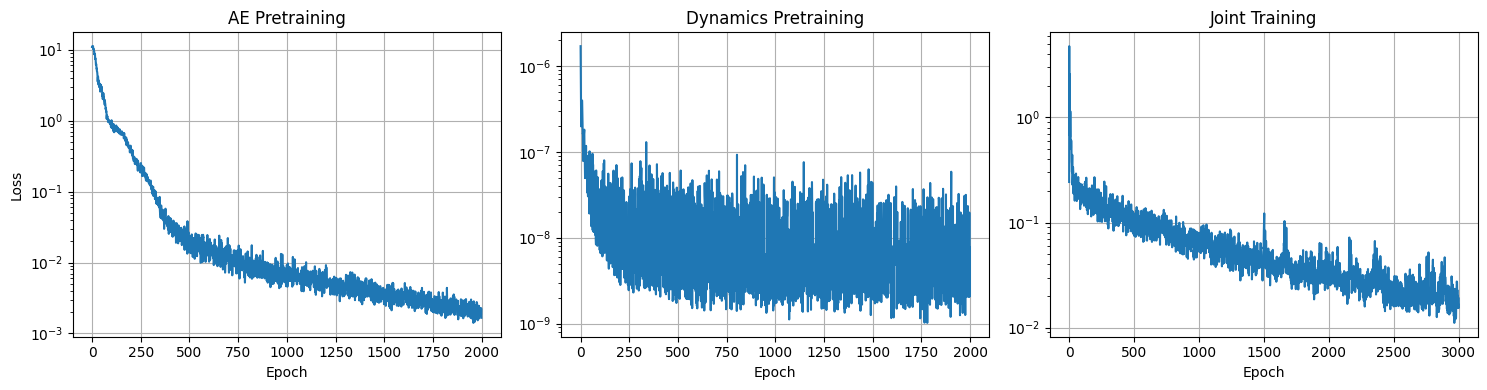

In [ ]:
"""
Pretrain the autoencoder

Trains just the encoder and decoder (leaving the dynamics network untouched) to minimize reconstruction error, as a first stage before the full model is trained jointly.
"""

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# -------------------- PRETRAINING AUTOENCODER (Enc+Dec only) --------------------
from torch.optim import Adam
import itertools
import torch.nn.functional as F

ae_epochs = 2000
ae_lr = 1e-3
ae_bs = 264

encNet.train()
decNet.train()
dynNet.eval()  # not used here

opt_ae = Adam(itertools.chain(encNet.parameters(), decNet.parameters()), lr = ae_lr)

lossHist_ae = np.zeros(ae_epochs, dtype = np.float64)


print("B) Pretraining autoencoder (Enc+Dec)...")
for ep in range(1, ae_epochs + 1):
    idx = torch.randint(0, XN_train_t.shape[0], (ae_bs,), device = XN_train_t.device)
    x = XN_train_t[idx] # normalized training states [B, 11]
    z = encNet(x)
    xrec = decNet(z)

    loss_ae = torch.mean(torch.sum((x - xrec)**2, dim = 1))

    opt_ae.zero_grad(set_to_none = True)
    loss_ae.backward()
    opt_ae.step()

    lossHist_ae[ep - 1] = loss_ae.item()

    if ep % 200 == 0:
        print(f"  AE ep {ep:4d}/{ae_epochs}  loss={loss_ae.item():.3e}")

with torch.no_grad():
  z_train = encNet(XN_train_t)
  print(f"Latent space statistics : mean{z_train.mean(0)}, std = {z_train.std(0)}")

# -------------------- PRETRAINING Dynamics (teacher forcing on Dyn) --------------------
dyn_epochs = 2000
dyn_lr = 1e-3
dyn_bs = 264
clip_norm = 1.0


encNet.eval()
decNet.eval()
dynNet.train()  # used here

opt_dyn = Adam(dynNet.parameters(), lr = dyn_lr)


lossHist_dyn = np.zeros(dyn_epochs, dtype = np.float64)


print("B2) Pretraining dynamics (Dyn only, teacher forcing in latent space)...")

Ntr = XN_train_t.shape[0]
Utr = U_train_t[:Ntr]

for ep in range(1, dyn_epochs + 1):
    idx =  torch.randint(0, Ntr - 1, (dyn_bs,), device = XN_train_t.device)

    x_n   = XN_train_t[idx]
    x_np1 = XN_train_t[idx + 1]

    u_n = Utr[idx]
    if u_n.dim() == 1:
        u_n = u_n.unsqueeze(-1)  # [B,1]
    elif u_n.dim() == 2:
      pass
    else:
      raise RuntimeError(f"Unexpected u_n shape: {u_n.shape}")

    with torch.no_grad():
        z_n = encNet(x_n)
        z_np1 = encNet(x_np1)

    def rhs(zz, u = u_n):
        return dynNet(torch.cat([zz, u_n], dim=1))

    z_pred = runge_kutta(z_n, dt_years, rhs)

    loss_dyn = F.mse_loss(z_pred, z_np1)

    opt_dyn.zero_grad(set_to_none = True)
    loss_dyn.backward()
    torch.nn.utils.clip_grad_norm_(dynNet.parameters(), clip_norm)
    opt_dyn.step()

    lossHist_dyn[ep - 1] = loss_dyn.item()

    if ep % 200 == 0:
        print(f"  Dyn epoch {ep:4d}/{dyn_epochs}  loss={loss_dyn.item():.3e}")

# -------------------- TRAIN (CUSTOM LOOP) --------------------
encNet.train()
decNet.train()
dynNet.train()

optimizer = Adam(itertools.chain(encNet.parameters(), decNet.parameters(), dynNet.parameters()), lr = lr)

batch_size = 264
K_train_max = 55
gamma = 0.9999 # for long-lasting accuracy

print('C) Training (encoder/decoder + latent tendency)...')

lossHist = np.zeros(numEpochs, dtype = np.float64)

prob_of_teach_forc0 = 1.0
teach_forc_decay_epochs = int(numEpochs * 0.7) # model sees dynamics for 70% of training

for epoch in range(1, numEpochs + 1):
    K_train = min(K_train_max, 5 + (epoch//200)*5) # K_max for training, the starting point of K_train_max and every 2000 epochs it increases by 5
    prob_of_teach_forc = prob_of_teach_forc0 * max(0.0, 1.0 - epoch / max(1, teach_forc_decay_epochs))
    # Forward + loss
    #idx = torch.randint(low=0, high=(XN_t.shape[0] - (K + 1)), size=(batch_size,))

    idx = torch.randint(0, XN_train_t.shape[0] - (K_train + 1),
                        (batch_size,), device = XN_train_t.device)

    loss = loss_and_grads_rollout_sindy(encNet, decNet, dynNet, XN_train_t, U_train_t,
                                  idx, K_train, dt_years,
                                  lambdaRec, gamma = gamma, lambdaZ = 0.1,
                                  prob_of_teach_forc = prob_of_teach_forc)


    optimizer.zero_grad(set_to_none = True)
    loss.backward()

    optimizer.step()
    lossHist[epoch - 1] = float(loss.detach().cpu().numpy())

    if (epoch % printEvery) == 0:
        if XN_val_t.shape[0] > (K_train + 2):
          with torch.no_grad():
            idxtr = torch.randint(0, XN_train_t.shape[0] - (K_train + 1),
                          (batch_size,), device = XN_train_t.device)

            train_free = loss_and_grads_rollout_sindy(encNet, decNet, dynNet,
                                        XN_train_t, U_train_t,
                                        idxtr, K_train, dt_years, lambdaRec,
                                        gamma = gamma, lambdaZ = 0.1,
                                        prob_of_teach_forc = 0.0)

            idxv = torch.randint(0, XN_val_t.shape[0] - (K_train + 1),
                         (batch_size,), device = XN_val_t.device)

            val_loss = loss_and_grads_rollout_sindy(encNet, decNet, dynNet,
                                      XN_val_t, U_val_t,
                                      idxv, K_train, dt_years, lambdaRec,
                                      gamma = gamma, lambdaZ = 0.1,
                                      prob_of_teach_forc = 0.0)

            encNet.train(); decNet.train(); dynNet.train()

          print(f"epoch {epoch:5d}/{numEpochs} "
              f"K={K_train:2d} p_tf={prob_of_teach_forc:.3f} "
              f"train_assisted={lossHist[epoch-1]:.3e} "
              f"train_free={train_free.item():.3e} "
              f"val={val_loss.item():.3e}")
        else:
          print(f"epoch {epoch:5d}/{numEpochs} train_assisted={lossHist[epoch-1]:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(lossHist_ae)
axes[0].set_title("AE Pretraining")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale('log')
axes[0].grid(True)

axes[1].plot(lossHist_dyn)
axes[1].set_title("Dynamics Pretraining")
axes[1].set_xlabel("Epoch")
axes[1].set_yscale('log')
axes[1].grid(True)

axes[2].plot(lossHist)
axes[2].set_title("Joint Training")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale('log')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
"""
Fine-tune encoder, decoder and SINDy layer together

Defines the fine-tuning routine that jointly trains the encoder, decoder and SINDy layer (with the dynamics network kept frozen), combining reconstruction accuracy with the SINDy sparse-regression objective, and periodically hard-thresholding small coefficients to keep the discovered equations sparse.
"""

def run_sindy_finetuning(
    encNet, decNet, dynNet, sindyLayer, lib_idx,
    XN_train_t, U_train_t, XN_val_t, U_val_t,
    dt_years, latentDim, device,
    # --- Tunable hyperparameters ---
    n_epochs=2000,
    lr=3e-4,
    batch_size=264,
    K_train=20,
    gamma_decay=0.9999,
    lambdaRec=100.0,
    lambdaZ=0.1,
    lambdaSINDy=0.1,        # start moderate, increase later
    lambdaL1=1e-4,
    mask_every=200,          # hard-threshold Xi every N epochs
    mask_threshold=0.05,     # coefficients below this -> 0
    print_every=250,
):
    """
    encNet, decNet and sindyLayer are jointly fine-tuned.
    """
    # dynNet is freezed; kept as is for the rollout but not updated
    # SINDy loss only trains encNet (for better coordinate production) and sindyLayer.Xi (for sparse equation discovery).

    dynNet.eval()
    for p in dynNet.parameters():
        p.requires_grad = False

    encNet.train()
    decNet.train()
    sindyLayer.train()

    optimizer = Adam(itertools.chain(encNet.parameters(), decNet.parameters(), sindyLayer.parameters()), lr = lr)

    loss_hist = []

    print("=" * 60)
    print("JOINT SINDy FINE-TUNING")
    print(f"  epochs={n_epochs}, lr={lr}, K={K_train}")
    print(f"  lambdaSINDy={lambdaSINDy}, lambdaL1={lambdaL1}")
    print(f"  mask_every={mask_every}, mask_threshold={mask_threshold}")
    print("=" * 60)

    for epoch in range(1, n_epochs + 1):
        idx = torch.randint(
              0, XN_train_t.shape[0] - (K_train + 1),
              (batch_size,), device = device)

        loss = loss_and_grads_rollout_sindy(
               encNet, decNet, dynNet, XN_train_t, U_train_t,
               idx, K_train, dt_years,
               lambdaRec = lambdaRec,
               gamma = gamma_decay,
               lambdaZ = lambdaZ,
               prob_of_teach_forc  =0.0,   # no teacher forcing in fine-tuning
               sindyLayer = sindyLayer,
               lib_idx = lib_idx,
               lambdaSINDy = lambdaSINDy,
               lambdaL1 = lambdaL1,
               )

        optimizer.zero_grad(set_to_none = True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            itertools.chain(encNet.parameters(), decNet.parameters(), sindyLayer.parameters()),
            1.0
        )
        optimizer.step()

        loss_val = loss.item()
        loss_hist.append(loss_val)

        if epoch % mask_every == 0:
            n_active, n_total = mask_small_coeffs(sindyLayer, mask_threshold)

        if epoch % print_every == 0:
           with torch.no_grad():
              if XN_val_t.shape[0] > (K_train + 2):
                  idxv = torch.randint(0, XN_val_t.shape[0] - (K_train + 1),
                        (batch_size,), device = device)
                  val_loss = loss_and_grads_rollout_sindy(
                        encNet, decNet, dynNet, XN_val_t, U_val_t,
                        idxv, K_train, dt_years,
                        lambdaRec=lambdaRec, gamma=gamma_decay,
                        lambdaZ=lambdaZ,
                        sindyLayer=sindyLayer, lib_idx=lib_idx,
                        lambdaSINDy=lambdaSINDy, lambdaL1=lambdaL1,
                    ).item()
              else:
                  val_loss = float('nan')
           n_nonzero = int((torch.abs(sindyLayer.Xi) > mask_threshold).sum().item())

           print(f"  epoch {epoch:5d}/{n_epochs}  "
                f"train={loss_val:.3e}  val={val_loss:.3e}  "
                f"Xi nonzero={n_nonzero}/{sindyLayer.Xi.numel()}")

    print("\n" + "=" * 60)
    print("Final SINDy equations:")
    print("=" * 60)
    print_sindy_equations(sindyLayer, lib_idx, latentDim, threshold=mask_threshold)

    for p in dynNet.parameters():
        p.requires_grad = True

    return loss_hist

# SINDy

In [ ]:
"""
Polynomial library builder

Defines helper functions that build the library of candidate polynomial terms (used by SINDy) from the latent variables and the forcing input, and evaluate that library on a given dataset.
"""

import itertools

def _make_poly_library_indices(n_vars, poly_order, include_constant = True, max_u_power = 1):
    lib = []
    u_idx = n_vars - 1
    if include_constant:
        lib.append(())
    for d in range(1, poly_order + 1):
        for comb in itertools.combinations_with_replacement(range(n_vars), d):
            if comb.count(u_idx) <= max_u_power:
                lib.append(comb)
    return lib


def _eval_poly_library(v, lib_idx):
    """Works for both torch tensors and numpy arrays."""
    N = v.shape[0]
    is_torch = isinstance(v, torch.Tensor)

    feats = []
    for comb in lib_idx:
        if len(comb) == 0:
            if is_torch:
                feats.append(torch.ones((N, 1), device=v.device, dtype=v.dtype))
            else:
                feats.append(np.ones((N, 1)))
        else:
            if is_torch:
                term = v[:, comb[0]].clone()
            else:
                term = v[:, comb[0]].copy()
            for j in comb[1:]:
                term = term * v[:, j]
            feats.append(term.reshape(N, 1))

    if is_torch:
        return torch.cat(feats, dim=1)
    return np.concatenate(feats, axis=1)


def make_sindy_rhs(Xi, lib_idx):
    """Return callable sindy_rhs(z, u) -> dz/dt."""
    def sindy_rhs(z, u):
        u_ = u.unsqueeze(1) if u.ndim == 1 else u
        v = torch.cat([z, u_], dim=1)
        Theta = _eval_poly_library(v, lib_idx)
        return Theta @ Xi
    return sindy_rhs


def stlsq(Theta, Y, lam=1e-3, n_iter=8):
    Xi = np.linalg.lstsq(Theta, Y, rcond=None)[0]
    for _ in range(n_iter):
        small = np.abs(Xi) < lam
        Xi[small] = 0.0
        for j in range(Y.shape[1]):
            big = ~small[:, j]
            if big.sum() == 0:
                continue
            Xi[big, j] = np.linalg.lstsq(Theta[:, big], Y[:, j], rcond=None)[0]
    return Xi

Polynomial library: 14 terms for 3 latent dims + 1 control
JOINT SINDy FINE-TUNING
  epochs=1000, lr=0.0001, K=20
  lambdaSINDy=0.5, lambdaL1=1e-06
  mask_every=99999, mask_threshold=0.05
  epoch   250/1000  train=7.444e-02  val=4.306e+03  Xi nonzero=22/42
  epoch   500/1000  train=7.585e-02  val=6.562e+03  Xi nonzero=22/42
  epoch   750/1000  train=5.534e-02  val=7.917e+03  Xi nonzero=22/42
  epoch  1000/1000  train=4.751e-02  val=9.198e+03  Xi nonzero=22/42

Final SINDy equations:
  dz1/dt = -0.1577*1
  dz2/dt = -0.4594*1 +0.0935*z1 -0.0696*z2 -0.0605*u +0.0624*z1*z1 -0.0609*z1*z2 +0.0536*z1*z3 -0.0563*z1*u +0.0539*z3*z3
  dz3/dt = -0.8358*1 +0.6816*z1 -0.2396*z2 -0.6247*u -0.4029*z1*z2 +0.2937*z1*z3 -0.0852*z1*u +0.1041*z2*z2 -0.0911*z2*z3 +0.2629*z2*u +0.1733*z3*z3 -0.2108*z3*u


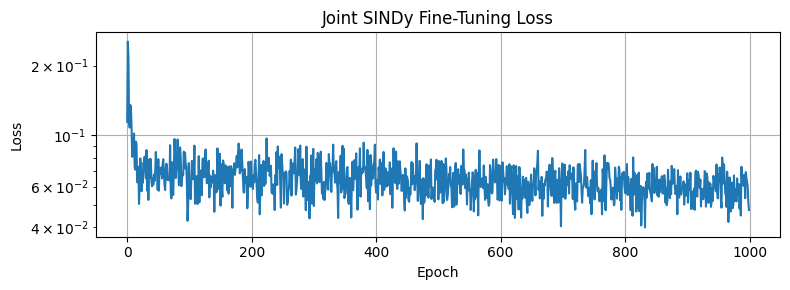

POST-HOC SINDy (fitted after training, no encoder feedback):

Post-hoc STLSQ:
  dz1/dt = -0.1893*1 +0.0132*z1 -0.0274*z2 +0.0139*z3 +0.0340*z1*z1 -0.0305*z1*u +0.0148*z2*z3 -0.0479*z2*u +0.0144*z3*z3 +0.0333*z3*u
  dz2/dt = -0.4543*1 +0.1075*z1 -0.0777*z2 +0.0290*z3 -0.0763*u +0.0639*z1*z1 -0.0668*z1*z2 +0.0593*z1*z3 -0.0625*z1*u +0.0225*z2*z2 -0.0264*z2*u +0.0525*z3*z3
  dz3/dt = -0.8975*1 +0.7001*z1 -0.2443*z2 -0.0102*z3 -0.6294*u +0.0537*z1*z1 -0.4148*z1*z2 +0.2968*z1*z3 -0.0960*z1*u +0.1052*z2*z2 -0.0943*z2*z3 +0.2586*z2*u +0.1864*z3*z3 -0.2162*z3*u

  Nonzero coeffs: 36 / 42

JOINT-TRAINED SINDy (encoder learned sparse-friendly coordinates):
  dz1/dt = -0.1577*1 -0.0212*z2 +0.0117*z3 +0.0229*z1*z1 -0.0167*z1*u -0.0302*z2*u +0.0135*z3*z3 +0.0225*z3*u
  dz2/dt = -0.4594*1 +0.0935*z1 -0.0696*z2 +0.0274*z3 -0.0605*u +0.0624*z1*z1 -0.0609*z1*z2 +0.0536*z1*z3 -0.0563*z1*u +0.0251*z2*z2 -0.0262*z2*u +0.0539*z3*z3
  dz3/dt = -0.8358*1 +0.6816*z1 -0.2396*z2 -0.6247*u +0.0388*z1*z1 -0.4029*

In [ ]:
"""
Fit the SINDy coefficients

Builds the polynomial term library for the current latent dimension and forcing, then fits an initial guess for the SINDy coefficients using a standard sequential least-squares approach; this fit is used to warm-start the coefficients before the full joint training.
"""

poly_order = 2
include_constant = True
max_u_power = 1
n_vars = latentDim + 1  # z1, z2, z3, u

lib_idx = _make_poly_library_indices(
    n_vars, poly_order,
    include_constant=include_constant,
    max_u_power=max_u_power
)

n_library = len(lib_idx)
print(f"Polynomial library: {n_library} terms for {latentDim} latent dims + 1 control")

# --- Post-hoc STLSQ fit (used to warm-start Xi) ---
with torch.no_grad():
    Xtruth_t = torch.tensor(Xtruth_state, dtype=torch.float32, device=device)
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    sd_t = torch.tensor(sd, dtype=torch.float32, device=device)
    XtruthN_t = (Xtruth_t - mu_t) / (sd_t + 1e-12)
    Z_all = encNet(XtruthN_t).detach().cpu().numpy()
    U_all = U_t.detach().cpu().numpy()

Zt = Z_all[:-1]
Ut = U_all[:-1]
dZdt = (Z_all[1:] - Z_all[:-1]) / float(dt_years)
V = np.concatenate([Zt, Ut], axis=1)
Theta = _eval_poly_library(V, lib_idx)
Xi_numpy = stlsq(Theta, dZdt, lam=1e-2, n_iter=10)

# --- Step 2: (Optional) Initialize Xi from your post-hoc STLSQ fit ---
# If you've already run cell 33 and have Xi_numpy, use it as warm start:
#
#   sindyLayer = SINDyLayer(n_library, latentDim, init_Xi=Xi_numpy).to(device)
#
# Otherwise start from scratch:
sindyLayer = SINDyLayer(n_library, latentDim, init_Xi = Xi_numpy).to(device)

# --- Step 3: Run fine-tuning ---
sindy_loss_hist = run_sindy_finetuning(
    encNet, decNet, dynNet, sindyLayer, lib_idx,
    XN_train_t, U_train_t, XN_val_t, U_val_t,
    dt_years, latentDim, device,
    # --- Key hyperparameters to experiment with ---
    n_epochs = 1000,          # start with 2000, increase if loss still dropping
    lr = 1e-4,                # lower than initial training (fine-tuning)
    batch_size = 264,
    K_train = 20,             # match your existing K
    lambdaRec = 500.0,        # keep same as your original training
    lambdaSINDy = 0.5,        # THE key new hyperparameter — start here
    lambdaL1 = 1e-6,          # sparsity pressure — increase for sparser Xi
    mask_every = 99999,         # hard threshold frequency
    mask_threshold = 0.05,    # coefficients below this get zeroed
)

# --- Step 4: Plot fine-tuning loss ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(sindy_loss_hist)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Joint SINDy Fine-Tuning Loss")
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Step 5: Build the SINDy RHS for the particle filter ---
Xi_joint = sindyLayer.Xi.detach()
sindy_rhs_joint = make_sindy_rhs(Xi_joint, lib_idx)

# Now you can use sindy_rhs_joint in run_pf_once by replacing sindy_rhs:
#   sindy_rhs = sindy_rhs_joint
#
# Then run your particle filter as usual.


# %%  ==================== CELL F: COMPARE POST-HOC vs JOINT ====================
# Print both sets of equations side by side for your thesis.

print("=" * 60)
print("POST-HOC SINDy (fitted after training, no encoder feedback):")
print("=" * 60)
# Refit post-hoc for fair comparison (encoder may have changed)

with torch.no_grad():
    Xtruth_t = torch.tensor(Xtruth_state, dtype=torch.float32, device=device)
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    sd_t = torch.tensor(sd, dtype=torch.float32, device=device)
    XtruthN_t = (Xtruth_t - mu_t) / (sd_t + 1e-12)
    Z_post = encNet(XtruthN_t).detach().cpu().numpy()
    U_post = U_t.detach().cpu().numpy()

import numpy as np
Zt_ = Z_post[:-1]
Ut_ = U_post[:-1]
dZdt_ = (Z_post[1:] - Z_post[:-1]) / float(dt_years)
V_ = np.concatenate([Zt_, Ut_], axis=1)
Theta_ = _eval_poly_library(V_, lib_idx)
Xi_posthoc = stlsq(Theta_, dZdt_, lam=1e-2, n_iter=10)

# Build term names
var_names = [f"z{i+1}" for i in range(latentDim)] + ["u"]
term_names = []
for comb in lib_idx:
    if len(comb) == 0:
        term_names.append("1")
    else:
        term_names.append("*".join(var_names[j] for j in comb))

print("\nPost-hoc STLSQ:")
for j in range(latentDim):
    terms = [f"{Xi_posthoc[i,j]:+.4f}*{term_names[i]}"
             for i in range(len(term_names)) if abs(Xi_posthoc[i,j]) > 0.01]
    print(f"  dz{j+1}/dt = {' '.join(terms) if terms else '0'}")

print(f"\n  Nonzero coeffs: {np.count_nonzero(np.abs(Xi_posthoc) > 0.01)} / {Xi_posthoc.size}")

print("\n" + "=" * 60)
print("JOINT-TRAINED SINDy (encoder learned sparse-friendly coordinates):")
print("=" * 60)
print_sindy_equations(sindyLayer, lib_idx, latentDim, threshold=0.01)
Xi_joint_np = sindyLayer.Xi.detach().cpu().numpy()
print(f"\n  Nonzero coeffs: {np.count_nonzero(np.abs(Xi_joint_np) > 0.01)} / {Xi_joint_np.size}")

# Validation pipeline

,split,metric,value
0,train,recon_rmse,0.270867
1,val,recon_rmse,20.261808
2,train,1step_rmse,0.270771
3,val,1step_rmse,20.222986
4,train,H1_rmse,0.271031
5,train,H1_skill,-65.763779
6,val,H1_rmse,20.178083
7,val,H1_skill,-1694.990112
8,train,H5_rmse,0.270121
9,train,H5_skill,-12.307208


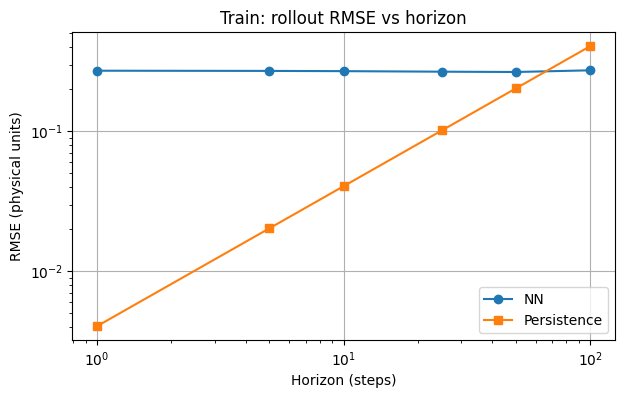

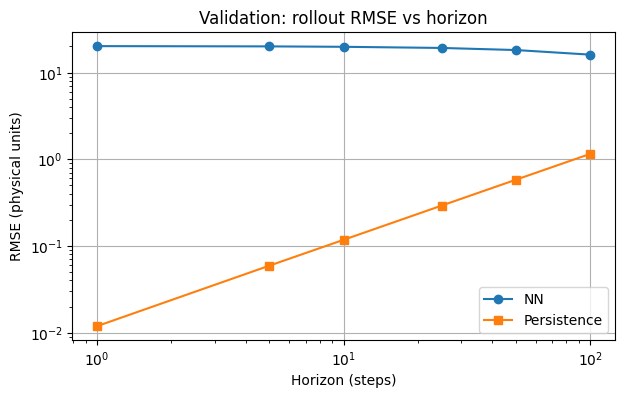


Per-variable reconstruction RMSE on validation:
  S_t   : 0.033151
  S_ts  : 0.226908
  S_n   : 0.859535
  S_s   : 0.209112
  S_d   : 0.048977
  D     : 67.173042
  T_t   : 0.110488
  T_ts  : 1.399841
  T_n   : 0.882077
  T_s   : 0.321821
  T_d   : 0.204494


In [ ]:
"""
Evaluate reconstruction on the validation period

Defines helper functions (RMSE, R-squared, an RK4 step, and conversion back to physical units) and uses them to check how well the trained encoder/decoder reconstructs each of the 11 state variables on the held-out validation segment -- a check of the model's ability to generalize to time periods it wasn't trained on.
"""

# This section evaluates generalization on the held-out (future) validation segment.

var_names = list(model.convention) # 11 state variables

mu_t = torch.tensor(mu, dtype = torch.float32, device = device)
sd_t = torch.tensor(sd, dtype = torch.float32, device = device)

def rmse(a, b, axis=  None):
    a = np.asarray(a); b = np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2, axis=axis))

def r2_1d(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-8)

def rk4_step(z, u):
    rhs = lambda zz: dynNet(torch.cat([zz, u], dim=1))
    return runge_kutta(z, dt_years, rhs)

def to_physical(XN_t):
    return (XN_t * sd_t + mu_t).cpu().numpy()

@torch.no_grad()
def reconstruction_metrics(XN_set_t, split_name="val"):
    Z = encNet(XN_set_t)
    XN_rec = decNet(Z)

    X_true = to_physical(XN_set_t)
    X_rec  = to_physical(XN_rec)

    per_rmse = {vn: rmse(X_true[:, i], X_rec[:, i]) for i, vn in enumerate(var_names)}
    per_r2   = {vn: r2_1d(X_true[:, i], X_rec[:, i]) for i, vn in enumerate(var_names)}

    out = {
        "split": split_name,
        "rmse_all": rmse(X_true, X_rec),
        "nrmse_mean": float(np.mean([rmse(X_true[:,i], X_rec[:,i]) / (np.std(X_true[:,i]) + 1e-8) for i in range(len(var_names))])),
        "r2_median": float(np.median(list(per_r2.values()))),
        "per_var_rmse": per_rmse,
        "per_var_r2": per_r2,
    }
    return out, X_true, X_rec

@torch.no_grad()
def one_step_metrics(XN_set_t, U_set_t, split_name = "val", max_points = 5000):
    N = XN_set_t.shape[0] - 1
    if N <= 0:
        return None

    step = max(1, int(np.ceil(N / max_points)))
    idx = torch.arange(0, N, step, device = device)

    x0 = XN_set_t[idx]
    x1_true = XN_set_t[idx + 1]
    u0 = U_set_t[idx]
    if u0.dim() == 1:
        u0 = u0.unsqueeze(-1)

    z0 = encNet(x0)
    z1 = rk4_step(z0, u0)
    x1_pred = decNet(z1)

    X_true = to_physical(x1_true)
    X_pred = to_physical(x1_pred)
    X_pers = to_physical(x0) # persistence baseline

    out = {
        "split": split_name,
        "rmse_all": rmse(X_true, X_pred),
        "rmse_persistence": rmse(X_true, X_pers),
        "skill_vs_persistence": float(1.0 - rmse(X_true, X_pred) / (rmse(X_true, X_pers) + 1e-8)),
        "n_points": int(X_true.shape[0]),
        "per_var_rmse": {vn: rmse(X_true[:, i], X_pred[:, i]) for i, vn in enumerate(var_names)},
    }

    # Inside one_step_metrics, after computing X_true and X_pred:
    Y_true = obs_candidates_torch(torch.tensor(X_true.T, device = device, dtype = torch.float32)).cpu().numpy()
    Y_pred = obs_candidates_torch(torch.tensor(X_pred.T, device = device, dtype = torch.float32)).cpu().numpy()
    out["per_obs_rmse"] = {name: rmse(Y_true[i], Y_pred[i]) for i, name in enumerate(ObsNames)}

    return out

@torch.no_grad()
def multistep_metrics(XN_set_t, U_set_t, horizons = (1,5,10,25,50,100), stride = 10, max_starts = 2000, split_name = "val"):
    N = XN_set_t.shape[0]
    results = {}

    for H in horizons:
        max_start = N - H
        if max_start <= 1:
            continue

        starts = torch.arange(0, max_start, stride, device = device)
        if starts.numel() > max_starts:
            sel = torch.linspace(0, starts.numel() - 1, max_starts, device = device).long()
            starts = starts[sel]

        x0 = XN_set_t[starts]
        z = encNet(x0)

        for h in range(H):
            u = U_set_t[starts + h]
            if u.dim() == 1:
                u = u.unsqueeze(-1)
            z = rk4_step(z, u)

        xH_pred = decNet(z)
        xH_true = XN_set_t[starts + H]

        X_true = to_physical(xH_true)
        X_pred = to_physical(xH_pred)
        X_pers = to_physical(x0)   # persistence baseline

        results[int(H)] = {
            "split": split_name,
            "rmse_all": rmse(X_true, X_pred),
            "rmse_persistence": rmse(X_true, X_pers),
            "skill_vs_persistence": float(1.0 - rmse(X_true, X_pred) / (rmse(X_true, X_pers) + 1e-8)),
            "n_starts": int(X_true.shape[0]),
        }

        # Inside one_step_metrics, after computing X_true and X_pred:
        Y_true = obs_candidates_torch(torch.tensor(X_true.T, device = device, dtype = torch.float32)).cpu().numpy()
        Y_pred = obs_candidates_torch(torch.tensor(X_pred.T, device = device, dtype = torch.float32)).cpu().numpy()
        results[int(H)]["per_obs_rmse"] = {name: rmse(Y_true[i], Y_pred[i]) for i, name in enumerate(ObsNames)}

    return results

# Run validation
encNet.eval(); decNet.eval(); dynNet.eval()

recon_tr, _, _ = reconstruction_metrics(XN_train_t, "train")
recon_va, Xva_true, Xva_rec = reconstruction_metrics(XN_val_t,   "val")

one_tr = one_step_metrics(XN_train_t, U_train_t, "train")
one_va = one_step_metrics(XN_val_t,   U_val_t,   "val")

roll_tr = multistep_metrics(XN_train_t, U_train_t, split_name="train")
roll_va = multistep_metrics(XN_val_t,   U_val_t,   split_name="val")

# Summary table
def summary_row(split, metric, value):
    return {"split": split, "metric": metric, "value": value}

rows = [
    summary_row("train", "recon_rmse", recon_tr["rmse_all"]),
    summary_row("val",   "recon_rmse", recon_va["rmse_all"]),
    summary_row("train", "1step_rmse", one_tr["rmse_all"]),
    summary_row("val",   "1step_rmse", one_va["rmse_all"]),
]
for H in sorted(roll_va.keys()):
    for split, rd in [("train", roll_tr), ("val", roll_va)]:
        if H in rd:
            rows.append(summary_row(split, f"H{H}_rmse", rd[H]["rmse_all"]))
            rows.append(summary_row(split, f"H{H}_skill", rd[H]["skill_vs_persistence"]))

summary_df = pd.DataFrame(rows)
display(summary_df)

# Plot rollout error curves (NN vs persistence)
def plot_rollout(roll_dict, title):
    Hs = np.array(sorted(roll_dict.keys()), dtype = int)
    nn_rmse = np.array([roll_dict[h]["rmse_all"] for h in Hs])
    pers_rmse = np.array([roll_dict[h]["rmse_persistence"] for h in Hs])

    plt.figure(figsize=(7,4))
    plt.plot(Hs, nn_rmse, marker='o', label='NN')
    plt.plot(Hs, pers_rmse, marker='s', label='Persistence')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True)
    plt.xlabel("Horizon (steps)")
    plt.ylabel("RMSE (physical units)")
    plt.title(title)
    plt.legend()
    plt.show()

plot_rollout(roll_tr, "Train: rollout RMSE vs horizon")
plot_rollout(roll_va, "Validation: rollout RMSE vs horizon")

# Quick per-variable reconstruction RMSE print (validation)
print("\nPer-variable reconstruction RMSE on validation:")
for vn, e in recon_va["per_var_rmse"].items():
    print(f"  {vn:6s}: {e:.6f}")


In [ ]:
"""
Rollout diagnostics

Checks the one-step prediction accuracy of the trained dynamics network by comparing its predicted latent-space change against the actual encoded change, using one Runge-Kutta step, and reporting the resulting error relative to the natural scale of the latent changes.
"""

encNet.to(device).eval()
decNet.to(device).eval()
dynNet.to(device).eval()

with torch.no_grad():
  # Same normalized series used for training
  X_seq = XN_t.to(device)
  U_seq = U_t.to(device)

  z0 = encNet(X_seq[:-1])
  z1_t = encNet(X_seq[1:])
  dz_true = z1_t - z0

  u0 = U_seq[:-1]

  # 1-step prediction using RK4

  rhs = lambda zz: dynNet(torch.cat([zz, u0], dim=1))
  z1_p = runge_kutta(z0, dt_years, rhs)

  dz_pred = z1_p - z0

  scale_true = dz_true.std().item()
  scale_pred = dz_pred.std().item()
  rmse_1step = torch.sqrt(torch.mean((z1_p - z1_t)**2)).item()

print(f"[latent] std(dz_true)={scale_true:.4e}  std(dz_pred)={scale_pred:.4e}  1-step RMSE(z)={rmse_1step:.4e}")
print(f"[latent] ratio std(dz_true)/std(dz_pred) = {scale_true/(scale_pred+1e-12):.3f}")

[latent] std(dz_true)=6.4468e-04  std(dz_pred)=5.1598e-04  1-step RMSE(z)=8.5197e-04
[latent] ratio std(dz_true)/std(dz_pred) = 1.249


In [ ]:
"""
Multi-step error growth

Checks how prediction error grows as rollouts get longer (1, 5, 10, 25, 50 and 100 steps), by starting from the true latent state at each point in time and rolling the dynamics network forward purely on its own predictions. This shows whether errors stay small over realistic forecast horizons or blow up quickly.
"""

encNet = encNet.to(device).eval()
dynNet = dynNet.to(device).eval()

with torch.no_grad():
    X_seq = XN_t.to(device) # [Nt,11] normalized (same used in training)
    U_seq = U_t.to(device)  # [Nt,1]

    z_true = encNet(X_seq) # [Nt,L]

    Horizon_list = [1, 5, 10, 25, 50, 100]
    errs = {}

    for H in Horizon_list:
        z = z_true[:-H].clone() # start from true latent at time n
        for h in range(H):
            # use forcing u_n for step n->n+1
            u = U_seq[h:-(H-h)].contiguous() # aligns shapes to [Nt-H,1]
            rhs = lambda zz: dynNet(torch.cat([zz, u], dim=1))
            z = runge_kutta(z, dt_years, rhs)

        err = torch.sqrt(torch.mean((z - z_true[H:])**2)).item()
        errs[H] = err

print("latent RMSE vs horizon:", errs)


latent RMSE vs horizon: {1: 0.0008519724942743778, 5: 0.004252344835549593, 10: 0.008463742211461067, 25: 0.020665619522333145, 50: 0.03956823796033859, 100: 0.07451741397380829}


In [ ]:
"""
Particle-distribution plotting helper

Defines a function that plots the weighted distribution of a set of particle samples (as a histogram and a kernel density estimate), together with the true value, for visualizing how spread out the particle filter's estimates are at a given point in time.
"""

from scipy.stats import gaussian_kde

def plot_pdf_1d(samples, weights=None, bins=40, kde=True, ax=None, true=None, title=None):
    import matplotlib.pyplot as plt
    s = np.asarray(samples).ravel().astype(float)

    if weights is None:
        w = np.ones_like(s, dtype=float) / max(len(s), 1)
    else:
        w = np.asarray(weights).ravel().astype(float)

    # Drop non-finite samples (and their weights) up front: a single NaN/inf
    # particle makes gaussian_kde's covariance non-finite and crashes.
    finite = np.isfinite(s) & np.isfinite(w)
    s, w = s[finite], w[finite]
    wsum = w.sum()
    w = w / wsum if wsum > 1e-30 else np.ones_like(s) / max(s.size, 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))

    if s.size == 0:
        if title: ax.set_title(title + "  [no finite samples]")
        ax.grid(True, alpha=0.3)
        return ax

    ax.hist(s, bins = bins, weights = w, density = True, alpha = 0.35, edgecolor = "none", label = "weighted hist")

    # Effective sample size: weight degeneracy (neff ~ 1) gives gaussian_kde
    # zero degrees of freedom -> divide-by-zero -> non-finite covariance.
    sw2 = float(np.sum(w**2))
    neff = 1.0 / sw2 if sw2 > 0 else 0.0

    if kde:
        # skip KDE for (near) delta functions or collapsed weights
        if np.std(s) < 1e-10 or np.unique(s).size < 3 or neff < 3.0:
            kde = False

    if kde:
        try:
            kde_est = gaussian_kde(s, weights=w)
            xx = np.linspace(np.percentile(s, 0.5), np.percentile(s, 99.5), 400)
            ax.plot(xx, kde_est(xx), label="KDE")
        except (np.linalg.LinAlgError, ValueError):
            # fallback: jitter *just for KDE*, keep histogram as-is
            try:
                sj = s + 1e-6 * np.random.randn(*s.shape)
                kde_est = gaussian_kde(sj, weights=w)
                xx = np.linspace(np.percentile(sj, 0.5), np.percentile(sj, 99.5), 400)
                ax.plot(xx, kde_est(xx), label="KDE (jittered)")
            except (np.linalg.LinAlgError, ValueError):
                pass  # histogram already drawn; skip KDE entirely

    if true is not None:
        ax.axvline(true, color = "k", linestyle="--", label="truth")

    ax.set_ylabel("density")
    ax.grid(True, alpha=0.3)
    ax.legend()
    if title: ax.set_title(title)
    return ax

# Helpers for Partilce Filter

In [ ]:
"""
Set up synthetic observations for the particle filter

Generates noisy synthetic observations from the true model trajectory (adding random noise to each observable quantity) and defines a GPU-based systematic resampling function used by the particle filter.
"""

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"

encNet = encNet.to(device).eval()
decNet = decNet.to(device).eval()
dynNet = dynNet.to(device).eval()

nCand = len(ObsNames)
Nt = Xtruth_state.shape[0]
nX = Xtruth_state.shape[1]
name_to_idx = {nm: i for i, nm in enumerate(ObsNames)}
eps = 1e-30

# Noisy observations
Xtruth_t = torch.tensor(Xtruth_state, dtype = torch.float32, device = device)
with torch.no_grad():
    Ytruth_all_t = obs_candidates_torch(Xtruth_t.T)
noise_t = sig_all_t[:, None] * torch.randn(nCand, Nt, device=device)
Yobs_all_t = Ytruth_all_t + noise_t
Yobs_all_t[name_to_idx["SeaIce"]] = torch.clamp(
    Yobs_all_t[name_to_idx["SeaIce"]], 0.0, 1.0
)


def systematic_resample_torch(w):
    N = w.numel()
    w = w / (w.sum() + 1e-30)
    cdf = torch.cumsum(w, dim=0)
    cdf[-1] = 1.0
    u0 = torch.rand((), device=w.device, dtype=w.dtype) / N
    u = u0 + torch.arange(N, device=w.device, dtype=w.dtype) / N
    idx = torch.searchsorted(cdf, u, right=False)
    return torch.clamp(idx, 0, N - 1).long()


def decode_and_observe(Zp):
    """Decode latent -> physical -> candidate observations."""
    with torch.no_grad():
        XpN_t = decNet(Zp.T.float())
        Xp_t = (XpN_t * sd_t + mu_t).T
        Yp_all_t = obs_candidates_torch(Xp_t)
    return Xp_t, Yp_all_t


def check_finite(tensor, name, k):
    if not torch.isfinite(tensor).all():
        print(f"[NaN] {name} non-finite at k={k}")
        return False
    return True


def maybe_rejuvenate(Zp, z_std_min=1e-2, rejuv_z=5e-2):
    if Zp.std(dim=1).mean() < z_std_min:
        Zp = Zp + rejuv_z * torch.randn_like(Zp)
    return Zp


def enkf_proposal(Zp, yhat_t, yk_t, w, sig_t,
                  nudge_gamma = 0.1, nudge_alpha = 1.0, jitter = 1e-5):
    """EnKF-style nudge of latent particles toward observations."""
    w_norm = w / (w.sum() + eps)

    z_bar = (Zp * w_norm[None, :]).sum(dim=1, keepdim=True)
    y_bar = (yhat_t * w_norm[None, :]).sum(dim=1, keepdim=True)

    Zc = Zp - z_bar
    Yc = yhat_t - y_bar

    Pzy = (Zc * w_norm[None, :]) @ Yc.T
    Pyy = (Yc * w_norm[None, :]) @ Yc.T

    B = Pyy.shape[0]
    sig_vec = sig_t.reshape(-1)
    R = torch.diag((sig_vec**2) / nudge_gamma + 1e-12)
    Pyy = 0.5 * (Pyy + Pyy.T) + R
    ridge = jitter + 1e-6 * (torch.trace(Pyy).abs() / (B + 1e-12))
    A = Pyy + ridge * torch.eye(B, device=device, dtype=Pyy.dtype)

    try:
        K = torch.linalg.solve(A, Pzy.T).T
    except Exception:
        K = (torch.linalg.pinv(A) @ Pzy.T).T

    y_pert = yk_t + (sig_t / torch.sqrt(
        torch.tensor(nudge_gamma, device=device))) * torch.randn_like(yhat_t)
    innov = y_pert - yhat_t

    Zp = Zp + nudge_alpha * (K @ innov)
    Zp = torch.tanh(Zp / 12.0) * 12.0
    return maybe_rejuvenate(Zp)


def reseed_collapsed_particles(Zp, w, Xp_t, Yp_all_t,
                                spread_threshold=0.05):
    """Re-seed particles if obs spread collapses relative to noise."""
    obs_spread = Yp_all_t.std(dim=1)
    min_spread_ratio = obs_spread / (sig_all_t + 1e-12)
    if min_spread_ratio.min().item() >= spread_threshold:
        return Zp, False

    n_reseed = max(Npart // 5, 10)
    reseed_idx = torch.randperm(Npart, device=device)[:n_reseed]

    xmean = (Xp_t @ w).unsqueeze(1)
    xstd_prior = torch.tensor(
        Xtruth_state.std(axis=0), dtype=torch.float32, device=device
    ).unsqueeze(1)
    x_new = xmean + 0.5 * xstd_prior * torch.randn(nX, n_reseed, device=device)
    x_new_norm = (x_new.T - mu_t) / (sd_t + 1e-12)

    with torch.no_grad():
        z_new = encNet(x_new_norm.float()).T
    Zp[:, reseed_idx] = z_new
    return Zp, True


def log_pf_step(k, J, Yp_all_prior_t, w_prior, Yp_all_t, w,
                Ytruth_all_t, Yobs_all_t, Zp, Xp_t):
    """Snapshot diagnostics + prior/posterior PDF plots."""
    with torch.no_grad():
        z_std = Zp.std(dim=1).mean().item()
        x_std = Xp_t.std(dim=1).mean().item()
        y_std = Yp_all_t.std(dim=1).mean().item()
    print(f"[DEBUG] k={k}: mean std(Z)={z_std:.3e}, "
          f"mean std(X)={x_std:.3e}, mean std(Y)={y_std:.3e}")

    per_obs_std = Yp_all_t.std(dim=1).detach().cpu().numpy()
    print("[DEBUG] per-obs std: " +
          ", ".join(f"{ObsNames[i]}={per_obs_std[i]:.3e}" for i in range(nCand)))

    print(f"\n--- k={k}  selected J={[ObsNames[int(x)] for x in J]} ---")
    for j_obs, name in enumerate(ObsNames):
        y_true = Ytruth_all_t[j_obs, k].item()
        y_obs = Yobs_all_t[j_obs, k].item()

        # Prior PDF
        y_prior = Yp_all_prior_t[j_obs, :].detach().cpu().numpy()
        w_prior_np = w_prior.detach().cpu().numpy()
        plot_pdf_1d(y_prior, w_prior_np, true=y_true,
                    title=f"Prior PDF obs[{name}] at k={k}")
        plt.axvline(y_obs, color="tab:cyan", ls="--", label="noisy obs")
        plt.legend(); plt.show()

        # Posterior PDF
        y_post = Yp_all_t[j_obs, :].detach().cpu().numpy()
        w_post_np = w.detach().cpu().numpy()
        plot_pdf_1d(y_post, w_post_np, true=y_true,
                    title=f"Posterior PDF obs[{name}] at k={k}")
        plt.axvline(y_obs, color="tab:cyan", ls="--", label="noisy obs")
        plt.legend(); plt.show()

# Bayesian SINDy

This part is motivated by the Gao and Kutz (2024) paper dealing with the application of Bayesian SINDy autoencoders. This application aims to influence the explainability of the system in latent space. The paper makes use of the **SSGL** (Spike-and-slab Gaussian Laplace) prior due to its reliability in handling low-data high-noise regimes. This attribute could prove helpful due to the latter characteristic. This adaptation is subject to a few omissions to fit the current state of the analysis.

In [ ]:
"""
Bayesian SINDy with Spike-and-Slab Gaussian-Laplace (SSGL) prior.

Implements the EMVS (Expectation-Maximisation Variable Selection) approach
from Gao & Kutz (2024), Proc. R. Soc. A 480: 20230506.

Designed as a drop-in replacement for stlsq() in the user's existing
SINDy pipeline.  Input:  Theta [N, p]  and  dZdt [N, d].
                  Output: Xi [p, d], inclusion probs rho [p, d],
                          posterior samples [n_samples, p, d].

Equation references are to the paper sections.
"""

import math
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal, Laplace
from dataclasses import dataclass, field
from typing import Optional, Tuple, List


# ──────────────────────────────────────────────────────────────────────
# 1.  Hyperparameter container
# ──────────────────────────────────────────────────────────────────────
@dataclass
class SSGLParams:
    """
    Hyperparameters for the SSGL prior (eq. 3.4) and EMVS procedure.

    v0      : float – spike (Laplace) scale.  Larger => stronger sparsity.
              Paper: sigma * v0 in eq 3.4.  Repo: 'epsilon'.
    v1      : float – slab (Gaussian) variance.  Larger => weaker shrinkage
              on active terms.  Paper: sigma^2 * v1.  Repo: c_std**2.
    delta   : float – prior inclusion probability (Bernoulli parameter).
              Paper: delta in eq 3.4.  Repo: 'pi'.
    sigma   : float – noise scale (shared across likelihood).
              Paper: sigma in eq 3.4.  Repo: 'sigma'.
    omega0  : float – initial stochastic-approximation step size for
              rho/kappa updates (eq 3.11-3.12).  Repo: 'decay'.
    omega_decay : float – geometric decay applied to omega each epoch.
              omega^(k) = omega0 * omega_decay^k.
    lr      : float – learning rate for gradient steps on Xi.
    lr_decay: float – multiplicative decay applied to lr each epoch.
    n_epochs: int   – number of optimisation epochs.
    n_refine: int   – refinement epochs (prior turned off, Langevin noise
              injected for posterior sampling; §3b).
    n_samples : int – number of posterior samples to collect during
              refinement (last n_samples epochs are stored).
    threshold : float – inclusion-probability threshold for hard
              sparsification after training.  Terms with rho < threshold
              are zeroed.
    print_every : int – print diagnostics every N epochs.
    """
    v0: float = 0.01
    v1: float = 5.0
    delta: float = 0.9
    sigma: float = 0.1
    omega0: float = 0.01
    omega_decay: float = 0.9995
    lr: float = 1e-3
    lr_decay: float = 1.0
    n_epochs: int = 3000
    n_refine: int = 1500
    n_samples: int = 100
    threshold: float = 0.15
    print_every: int = 500


# ──────────────────────────────────────────────────────────────────────
# 2.  Core SSGL prior loss  (eq 3.9 in paper)
# ──────────────────────────────────────────────────────────────────────
def ssgl_prior_loss(Xi: torch.Tensor,
                    kappa0: torch.Tensor,
                    kappa1: torch.Tensor,
                    rho: torch.Tensor,
                    sigma: float,
                    delta: float) -> torch.Tensor:
    """
    Compute the negative log-prior under the SSGL spike-and-slab.

    Eq 3.9 defines Q (to be maximised) with prior terms:
        - sum_i [ |Xi_i| * kappa_i0 / sigma + Xi_i^2 * kappa_i1 / (2*sigma^2) ]
        + sum_i [ log(delta/(1-delta)) * rho_i ]

    Since we minimise a loss, we negate these terms, giving:
        + sum_i [ |Xi_i| * kappa_i0 / sigma + Xi_i^2 * kappa_i1 / (2*sigma^2) ]
        - sum_i [ log(delta/(1-delta)) * rho_i ]

    The repo uses reduce_mean; we follow the same convention so that the
    loss magnitude is independent of the number of library terms.
    """
    l1_term = torch.mean(torch.abs(Xi) * kappa0) / sigma
    l2_term = torch.mean(Xi ** 2 * kappa1) / (2.0 * sigma ** 2)
    inclusion_term = torch.mean(math.log(delta / (1.0 - delta) + 1e-30) * rho)
    return l1_term + l2_term - inclusion_term


# ──────────────────────────────────────────────────────────────────────
# 3.  EMVS update step  (eqs 3.11 – 3.15)
# ──────────────────────────────────────────────────────────────────────
@torch.no_grad()
def emvs_update(Xi: torch.Tensor,
                rho: torch.Tensor,
                kappa0: torch.Tensor,
                kappa1: torch.Tensor,
                v0: float,
                v1: float,
                delta: float,
                omega: float) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    One EMVS stochastic-approximation step.

    Eq 3.13 (EM for inclusion probability):
        rho_tilde_i = a_i / (a_i + b_i)
        where a_i = N(Xi_i; 0, v1) * delta
              b_i = Laplace(Xi_i; 0, v0) * (1 - delta)

    Eq 3.11 (stochastic approximation for rho):
        rho^{k+1} = (1 - omega) * rho^k  +  omega * rho_tilde

    Eq 3.14-3.15 (kappa updates):
        kappa0^{k+1} = (1-omega)*kappa0^k + omega*(1-rho)/v0
        kappa1^{k+1} = (1-omega)*kappa1^k + omega*rho/v1
    """
    # Distributions for slab (Gaussian) and spike (Laplace)
    slab = Normal(0.0, v1 ** 0.5)
    spike = Laplace(0.0, v0)

    # Log-probabilities
    log_a = slab.log_prob(Xi)    # log N(Xi; 0, v1)
    log_b = spike.log_prob(Xi)   # log Laplace(Xi; 0, v0)

    # Ratio b/a  (done in log-space for stability, matching repo)
    b_over_a = torch.exp(log_b - log_a) * (1.0 - delta) / delta

    # Eq 3.13:  rho_tilde = a / (a + b) = 1 / (1 + b/a)
    rho_tilde = 1.0 / (1.0 + b_over_a)
    rho_tilde = torch.clamp(rho_tilde, 0.0, 1.0)

    # Eq 3.11:  stochastic approximation
    rho_new = (1.0 - omega) * rho + omega * rho_tilde

    # Eq 3.14 – 3.15
    kappa0_new = (1.0 - omega) * kappa0 + omega * (1.0 - rho_new) / v0
    kappa1_new = (1.0 - omega) * kappa1 + omega * rho_new / v1

    return rho_new, kappa0_new, kappa1_new


# ──────────────────────────────────────────────────────────────────────
# 4.  Main fitting routine
# ──────────────────────────────────────────────────────────────────────
def bayesian_sindy_ssgl(
    Theta: np.ndarray,
    dZdt: np.ndarray,
    params: Optional[SSGLParams] = None,
    device: Optional[torch.device] = None,
    coefficient_mask: Optional[np.ndarray] = None,
    init_Xi: Optional[np.ndarray] = None,
) -> dict:
    """
    Fit SINDy coefficients with the Bayesian SSGL prior + EMVS.

    This is a drop-in replacement for stlsq().  It takes the same
    Theta [N, p] library matrix and dZdt [N, d] target derivatives
    that the user already computes, and returns a results dict.

    Parameters
    ----------
    Theta : ndarray [N, p]
        Evaluated candidate library (polynomials, forcing terms, etc.).
    dZdt : ndarray [N, d]
        Time derivatives of the latent state (finite differences).
    params : SSGLParams, optional
        Hyperparameters.  Defaults to SSGLParams().
    device : torch.device, optional
        GPU/CPU device.  Defaults to CUDA if available.
    coefficient_mask : ndarray [p, d], optional
        Binary mask to freeze certain coefficients at zero.
        Defaults to all-ones (no masking).
    init_Xi : ndarray [p, d], optional
        Initial coefficient values.  Defaults to OLS solution.

    Returns
    -------
    results : dict with keys:
        'Xi'          : ndarray [p, d]  – MAP coefficient estimate
        'Xi_sparse'   : ndarray [p, d]  – Xi after thresholding by rho
        'rho'         : ndarray [p, d]  – inclusion probabilities
        'kappa0'      : ndarray [p, d]  – adaptive L1 weights
        'kappa1'      : ndarray [p, d]  – adaptive L2 weights
        'samples'     : ndarray [n_samples, p, d] – posterior samples
        'loss_history' : list of floats
    """
    if params is None:
        params = SSGLParams()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    N, p = Theta.shape
    _, d = dZdt.shape

    # ---- Initialise Xi via OLS (or user-provided) ----
    if init_Xi is not None:
        Xi_np = init_Xi.copy()
    else:
        Xi_np = np.linalg.lstsq(Theta, dZdt, rcond=None)[0]

    # ---- Coefficient mask ----
    if coefficient_mask is None:
        mask_np = np.ones((p, d), dtype=np.float32)
    else:
        mask_np = coefficient_mask.astype(np.float32)

    # ---- Move to torch ----
    Theta_t = torch.tensor(Theta, dtype=torch.float32, device=device)
    Y_t = torch.tensor(dZdt, dtype=torch.float32, device=device)
    mask_t = torch.tensor(mask_np, dtype=torch.float32, device=device)

    # Learnable parameter
    Xi_t = torch.tensor(Xi_np, dtype=torch.float32, device=device,
                        requires_grad=True)

    # EMVS state variables  (initialised as in the repo: p=0.5, kappa=5e-4)
    rho = torch.full((p, d), 0.5, device=device)
    kappa0 = torch.full((p, d), 5e-4, device=device)
    kappa1 = torch.full((p, d), 5e-4, device=device)

    optimizer = torch.optim.Adam([Xi_t], lr=params.lr)

    omega = params.omega0
    loss_history = []

    # ================================================================
    #  PHASE 1:  Training with SSGL prior  (paper §3c)
    # ================================================================
    print(f"{'='*60}")
    print(f"  Bayesian SINDy SSGL — Phase 1: Training ({params.n_epochs} epochs)")
    print(f"  Library: {p} terms → {d} latent dims,  N={N} samples")
    print(f"  v0={params.v0}, v1={params.v1}, delta={params.delta}")
    print(f"{'='*60}")

    for epoch in range(params.n_epochs):
        optimizer.zero_grad()

        Xi_masked = Xi_t * mask_t

        # Data fidelity:  || dZdt - Theta @ Xi ||^2
        residual = Y_t - Theta_t @ Xi_masked
        data_loss = torch.mean(residual ** 2)

        # SSGL prior loss (eq 3.9)
        prior_loss = ssgl_prior_loss(
            Xi_masked, kappa0, kappa1, rho,
            params.sigma, params.delta
        )

        total_loss = data_loss + prior_loss

        total_loss.backward()
        optimizer.step()

        # ---- EMVS update (every 2 epochs, matching repo) ----
        if epoch % 2 == 0:
            with torch.no_grad():
                rho, kappa0, kappa1 = emvs_update(
                    Xi_t.data * mask_t, rho, kappa0, kappa1,
                    params.v0, params.v1, params.delta, omega
                )
                # Apply mask to rho (repo does this)
                rho = rho * mask_t

            # Decay stochastic approximation rate (eq below 3.12)
            omega *= params.omega_decay

        loss_history.append(float(total_loss.item()))

        if epoch % params.print_every == 0:
            n_active = int((rho > params.threshold).sum().item())
            print(f"  epoch {epoch:5d}  loss={total_loss.item():.4e}  "
                  f"data={data_loss.item():.4e}  prior={prior_loss.item():.4e}  "
                  f"active(ρ>{params.threshold})={n_active}/{p*d}")

    # ================================================================
    #  PHASE 2:  Refinement + posterior sampling  (paper §3b, §3d)
    #
    #  Prior is turned off.  Langevin noise is injected to collect
    #  approximate posterior samples (SGLD, eq 3.6).
    # ================================================================
    print(f"\n{'='*60}")
    print(f"  Phase 2: Refinement + posterior sampling ({params.n_refine} epochs)")
    print(f"{'='*60}")

    # Hard-threshold by inclusion probability before refinement
    with torch.no_grad():
        sparse_mask = (rho > params.threshold).float() * mask_t
        Xi_t.data *= sparse_mask

    # Switch to a refinement optimiser (no prior, just data fidelity)
    optimizer_refine = torch.optim.Adam([Xi_t], lr=params.lr * 0.1)

    n_collect = min(params.n_samples, params.n_refine)
    samples = np.zeros((n_collect, p, d), dtype=np.float32)
    collect_start = params.n_refine - n_collect

    for epoch in range(params.n_refine):
        optimizer_refine.zero_grad()

        Xi_masked = Xi_t * sparse_mask
        residual = Y_t - Theta_t @ Xi_masked
        data_loss = torch.mean(residual ** 2)

        data_loss.backward()
        optimizer_refine.step()

        # Inject Langevin noise (SGLD, eq 3.6)
        with torch.no_grad():
            alpha_sgld = 0.001
            noise_std = (2.0 * alpha_sgld * params.lr * 0.1) ** 0.5
            noise = torch.randn_like(Xi_t) * noise_std
            Xi_t.data += noise * sparse_mask

        # Collect posterior samples
        if epoch >= collect_start:
            samples[epoch - collect_start] = (
                (Xi_t.data * sparse_mask).cpu().numpy()
            )

        if epoch % params.print_every == 0:
            print(f"  refine {epoch:5d}  data_loss={data_loss.item():.4e}")

    # ================================================================
    #  Collect results
    # ================================================================
    Xi_final = (Xi_t.data * sparse_mask).cpu().numpy()
    rho_final = rho.cpu().numpy()

    # Xi_sparse: zero out terms with low inclusion probability
    Xi_sparse = Xi_final.copy()
    Xi_sparse[rho_final < params.threshold] = 0.0

    results = {
        'Xi': Xi_final,
        'Xi_sparse': Xi_sparse,
        'rho': rho_final,
        'kappa0': kappa0.cpu().numpy(),
        'kappa1': kappa1.cpu().numpy(),
        'samples': samples,
        'loss_history': loss_history,
        'sparse_mask': sparse_mask.cpu().numpy(),
        'params': params,
    }

    # Print discovered equation summary
    _print_equation_summary(Xi_sparse, rho_final, samples, d)

    return results


# ──────────────────────────────────────────────────────────────────────
# 5.  Convenience: pretty-print discovered equations
# ──────────────────────────────────────────────────────────────────────
def _print_equation_summary(Xi, rho, samples, d):
    """Print the discovered equations with uncertainty from posterior."""
    print(f"\n{'='*60}")
    print("  Discovered equations (SSGL)")
    print(f"{'='*60}")

    sample_std = np.std(samples, axis=0)  # [p, d]

    for j in range(d):
        active = np.where(np.abs(Xi[:, j]) > 1e-10)[0]
        if len(active) == 0:
            print(f"  dz{j}/dt = 0")
            continue
        terms = []
        for i in active:
            coeff = Xi[i, j]
            std_i = sample_std[i, j]
            rho_i = rho[i, j]
            terms.append(
                f"{coeff:+.4f}±{std_i:.4f} [ρ={rho_i:.3f}] · θ_{i}"
            )
        print(f"  dz{j}/dt = " + "\n             ".join(terms))
    print()


# ──────────────────────────────────────────────────────────────────────
# 6.  Helper: label library terms for readable output
# ──────────────────────────────────────────────────────────────────────
def label_library_terms(lib_idx, var_names):
    """
    Generate human-readable labels for each library term.

    Parameters
    ----------
    lib_idx : list of tuples (from _make_poly_library_indices)
    var_names : list of str, e.g. ['z0', 'z1', 'z2', 'u']

    Returns
    -------
    labels : list of str
    """
    labels = []
    for comb in lib_idx:
        if len(comb) == 0:
            labels.append("1")
        else:
            parts = [var_names[c] for c in comb]
            labels.append("·".join(parts))
    return labels


def print_equations_labeled(Xi, rho, samples, lib_idx, latent_names, var_names):
    """
    Pretty-print discovered equations with human-readable term names.

    Parameters
    ----------
    Xi : ndarray [p, d]
    rho : ndarray [p, d]
    samples : ndarray [n_samples, p, d]
    lib_idx : list of tuples
    latent_names : list of str, e.g. ['z0', 'z1', 'z2']
    var_names : list of str for library, e.g. ['z0', 'z1', 'z2', 'u']
    """
    labels = label_library_terms(lib_idx, var_names)
    sample_std = np.std(samples, axis=0)

    print(f"\n{'='*60}")
    print("  Discovered equations (Bayesian SSGL SINDy)")
    print(f"{'='*60}")
    for j in range(Xi.shape[1]):
        active = np.where(np.abs(Xi[:, j]) > 1e-10)[0]
        if len(active) == 0:
            print(f"  d({latent_names[j]})/dt = 0")
            continue
        terms = []
        for i in active:
            c = Xi[i, j]
            s = sample_std[i, j]
            r = rho[i, j]
            terms.append(f"{c:+.4f}±{s:.4f} [ρ={r:.3f}] · {labels[i]}")
        eq_str = "\n                    ".join(terms)
        print(f"  d({latent_names[j]})/dt = {eq_str}")
    print()

def sav_gol_deriv(Z, window_length=31, sg_polyorder=3, delta=None):
    if delta is None:
        delta = dt_years  # or delta_t, whichever you have
    dZdt = savgol_filter(Z, window_length=window_length, polyorder=sg_polyorder,
                         deriv=1, delta=delta, axis=0)
    return dZdt


In [ ]:
"""
Fit SINDy on the jointly-trained encoder

Re-fits the SINDy coefficients, this time using latent coordinates from the fully jointly-trained encoder (rather than the earlier pretrained-only version) and a Savitzky-Golay smoothed derivative, then compares against a plain least-squares baseline fit.
"""

poly_order = 2
include_constant = True
max_u_power = 1

with torch.no_grad():
    Xtruth_t = torch.tensor(Xtruth_state, dtype=torch.float32, device=device)
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    sd_t = torch.tensor(sd, dtype=torch.float32, device=device)
    XtruthN_t = (Xtruth_t - mu_t) / (sd_t + 1e-12)
    Z_joint = encNet(XtruthN_t).detach().cpu().numpy()   # jointly-trained encoder
    U_np = U_t.detach().cpu().numpy()

Zt = Z_joint[:-1]
Ut = U_np[:-1]
dZdt = sav_gol_deriv(Z_joint, window_length = 31, sg_polyorder = 3, delta = dt_years)
dZdt = dZdt[:-1]  # match Zt = Z_joint[:-1]

V = np.concatenate([Zt, Ut], axis = 1)
lib_idx = _make_poly_library_indices(V.shape[1], poly_order,
                                      include_constant = include_constant,
                                      max_u_power = max_u_power)

print("dZdt stats:")
print(f"  mean abs: {np.mean(np.abs(dZdt)):.4e}")
print(f"  std:      {np.std(dZdt):.4e}")
print(f"  max abs:  {np.max(np.abs(dZdt)):.4e}")

# OLS baseline to see what coefficients look like
Theta = _eval_poly_library(V, lib_idx)

Xi_ols = np.linalg.lstsq(Theta, dZdt, rcond = None)[0]
Xi_numpy = stlsq(Theta, dZdt, lam = 1e-2, n_iter = 10)

print(f"\nOLS coefficient stats:")
print(f"  mean abs: {np.mean(np.abs(Xi_ols)):.4e}")
print(f"  max abs:  {np.max(np.abs(Xi_ols)):.4e}")
print(f"  nonzero (>1e-3): {np.sum(np.abs(Xi_ols) > 1e-3)} / {Xi_ols.size}")

# Bayesian SSGL fit
ssgl_params = SSGLParams(
    v0=0.01,
    v1=10.0, # wider slab, less shrinkage on active terms
    delta=0.5,
    sigma= 1.0, # makes prior 20-400x weaker (before 0.05)
    omega0=0.001, # slower EMVS updates (less aggressive pruning)
    omega_decay=0.999,
    n_epochs=3000,
    n_refine=1500,
    threshold=0.15,
    )

results = bayesian_sindy_ssgl(Theta, dZdt, params = ssgl_params,
                              device = device, init_Xi = Xi_numpy)

Xi_torch = torch.tensor(results['Xi_sparse'], device=device, dtype=torch.float32)
sindy_rhs = make_sindy_rhs(Xi_torch, lib_idx)

dZdt stats:
  mean abs: 5.1437e-03
  std:      4.6814e-02
  max abs:  5.7299e+00

OLS coefficient stats:
  mean abs: 1.4608e-01
  max abs:  9.4194e-01
  nonzero (>1e-3): 42 / 42
  Bayesian SINDy SSGL — Phase 1: Training (3000 epochs)
  Library: 14 terms → 3 latent dims,  N=145999 samples
  v0=0.01, v1=10.0, delta=0.5
  epoch     0  loss=1.6874e-03  data=1.6028e-03  prior=8.4667e-05  active(ρ>0.15)=42/42
  epoch   500  loss=7.4873e-02  data=4.9370e-03  prior=6.9936e-02  active(ρ>0.15)=42/42
  epoch  1000  loss=5.6707e-03  data=2.2044e-03  prior=3.4663e-03  active(ρ>0.15)=42/42
  epoch  1500  loss=5.7226e-03  data=2.1872e-03  prior=3.5355e-03  active(ρ>0.15)=42/42
  epoch  2000  loss=5.7940e-03  data=2.1929e-03  prior=3.6011e-03  active(ρ>0.15)=42/42
  epoch  2500  loss=7.1820e-03  data=2.1932e-03  prior=4.9888e-03  active(ρ>0.15)=42/42

  Phase 2: Refinement + posterior sampling (1500 epochs)
  refine     0  data_loss=2.1940e-03
  refine   500  data_loss=2.2288e-03
  refine  1000  data_

/tmp/ipykernel_792/453257531.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


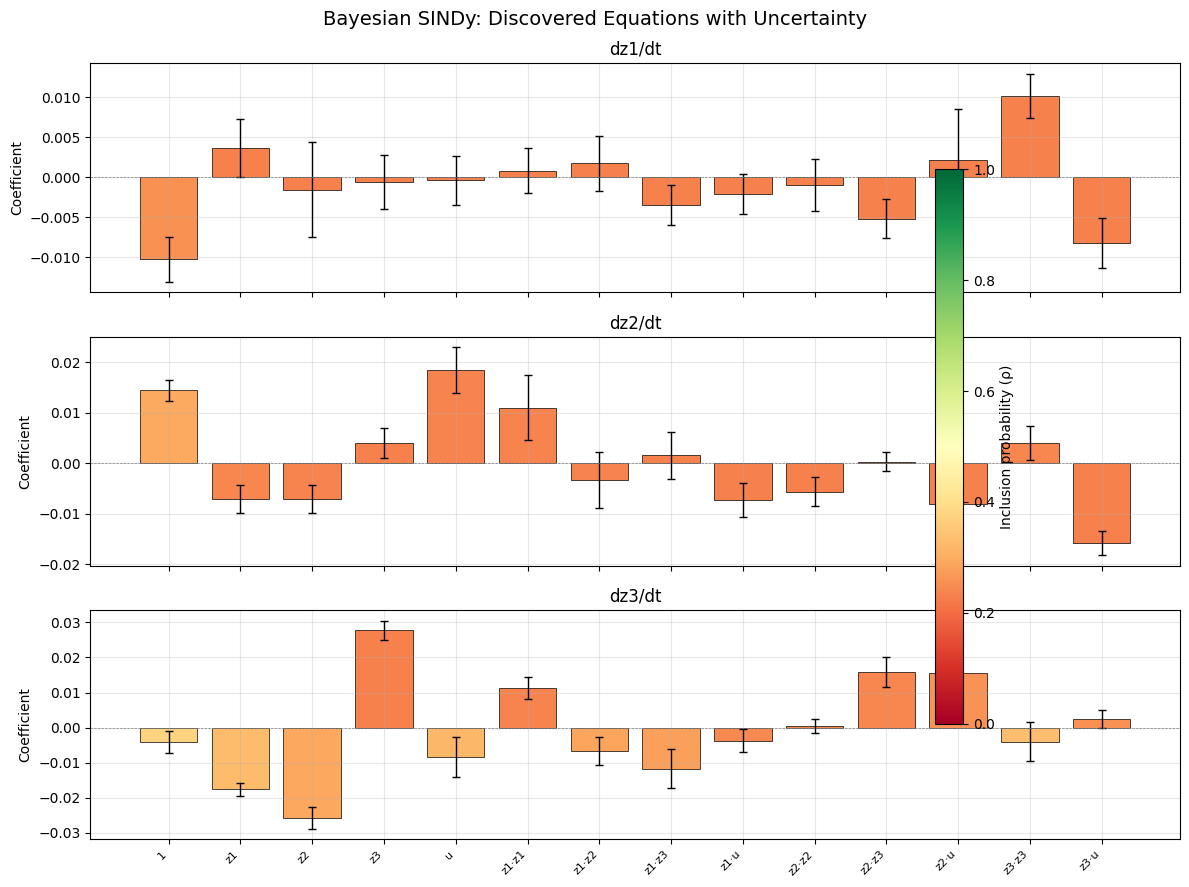

In [ ]:
"""
Plot the discovered SINDy coefficients

Plots the fitted SINDy coefficients for each latent dimension as bar charts, colored by how confident the fit is in including each term (its inclusion probability) and with error bars showing the posterior uncertainty in each coefficient.
"""

Xi = results['Xi_sparse']
rho = results['rho']
samples = results['samples']
sample_std = np.std(samples, axis=0)

# Build term labels
var_names = [f"z{i+1}" for i in range(latentDim)] + ["u"]
term_labels = label_library_terms(lib_idx, var_names)

fig, axes = plt.subplots(latentDim, 1, figsize=(12, 3 * latentDim), sharex=True)

for j in range(latentDim):
    ax = axes[j]
    coeffs = Xi[:, j]
    stds = sample_std[:, j]
    rhos = rho[:, j]

    # Color bars by inclusion probability
    colors = plt.cm.RdYlGn(rhos)  # green = high ρ, red = low ρ

    x = np.arange(len(term_labels))
    bars = ax.bar(x, coeffs, color=colors, edgecolor='black', linewidth=0.5)

    # Error bars from posterior samples
    ax.errorbar(x, coeffs, yerr=2 * stds, fmt='none', ecolor='black',
                capsize=3, linewidth=1)

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_ylabel('Coefficient')
    ax.set_title(f'dz{j+1}/dt')
    ax.set_xticks(x)
    ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Colorbar for inclusion probability
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, label='Inclusion probability (ρ)', shrink=0.8)

plt.suptitle('Bayesian SINDy: Discovered Equations with Uncertainty', fontsize=14)
plt.tight_layout()
plt.show()

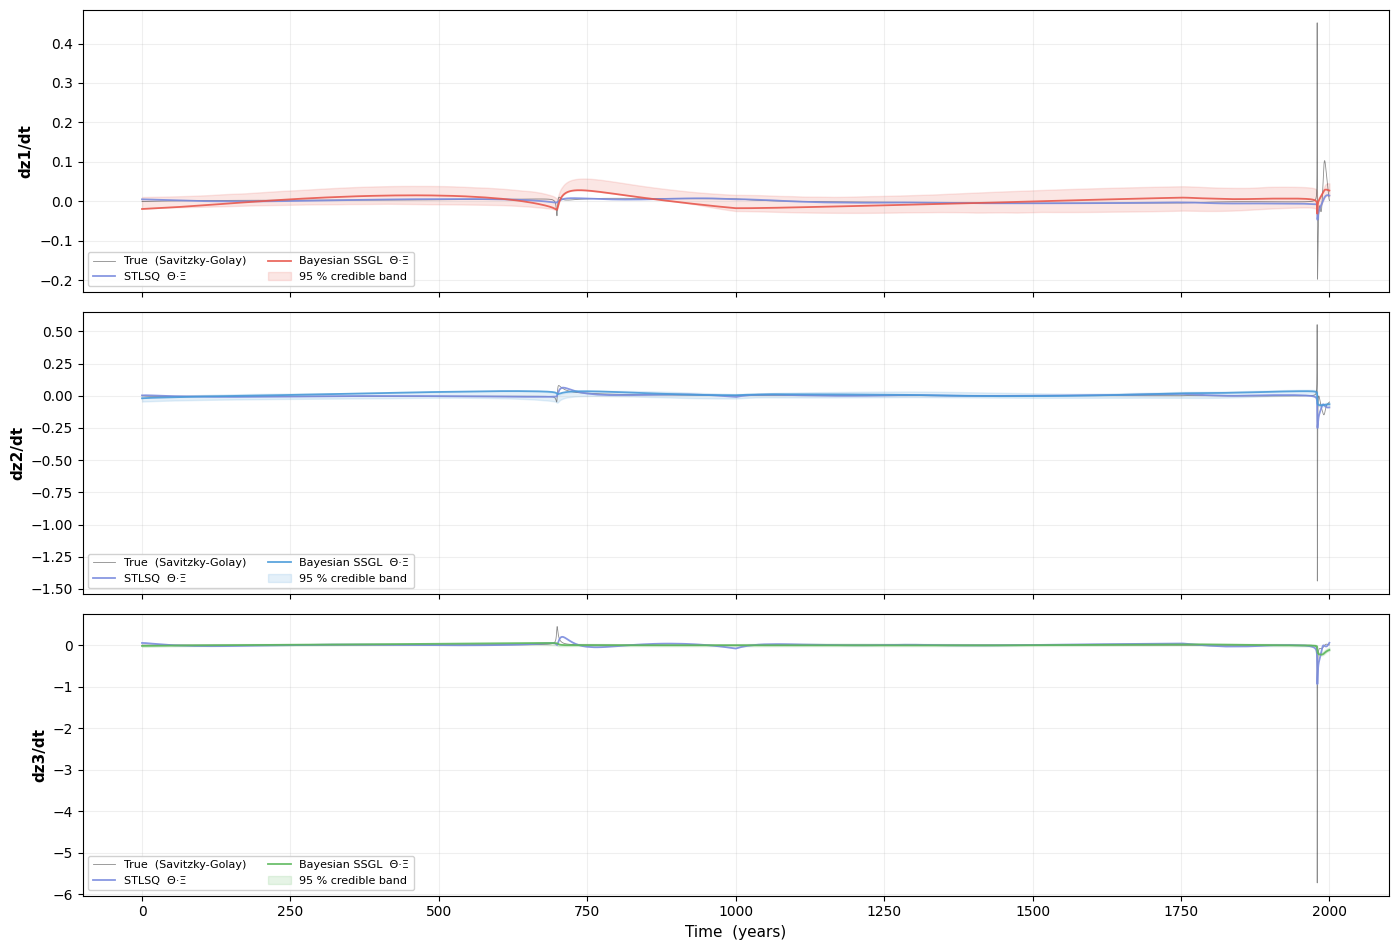

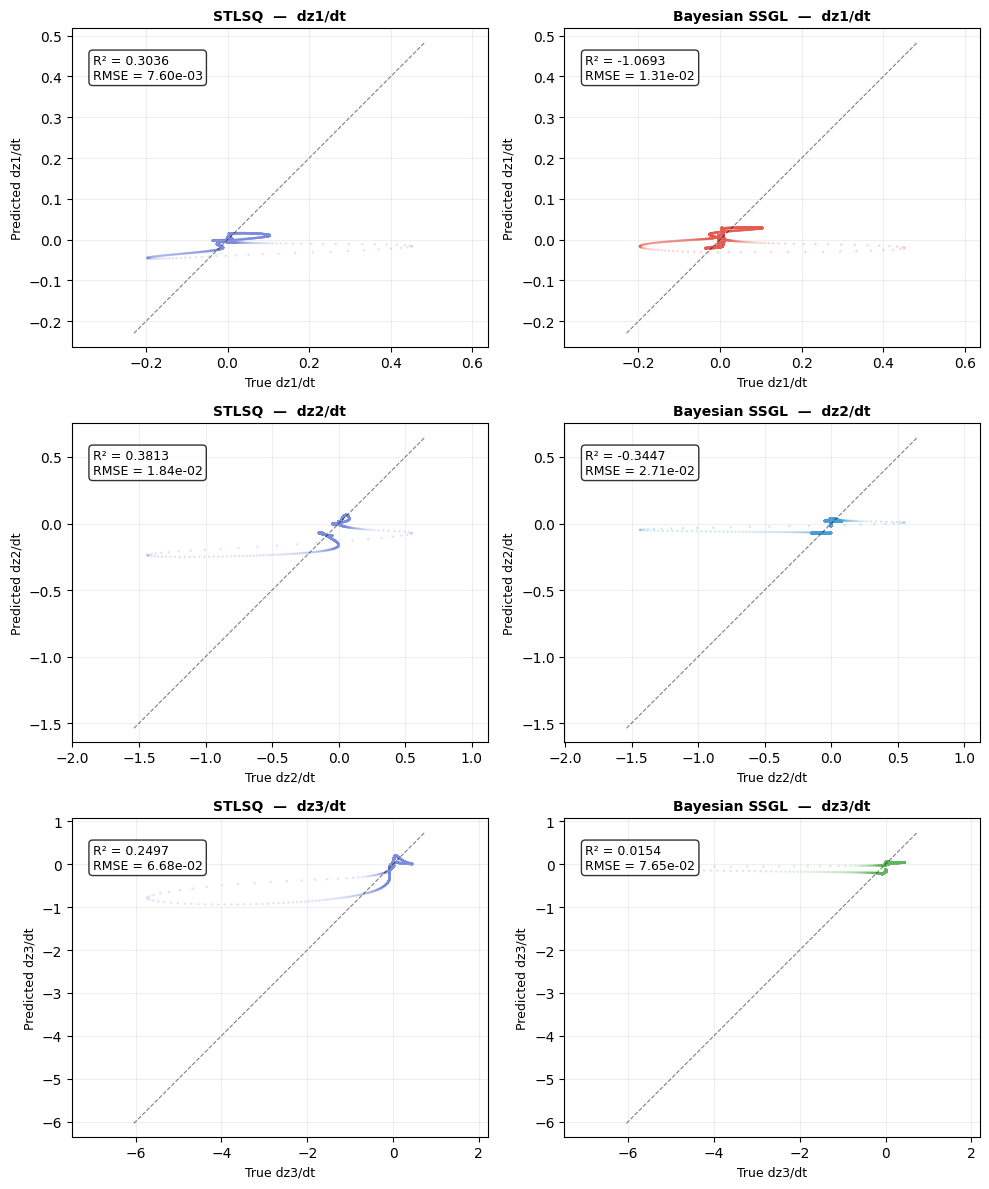

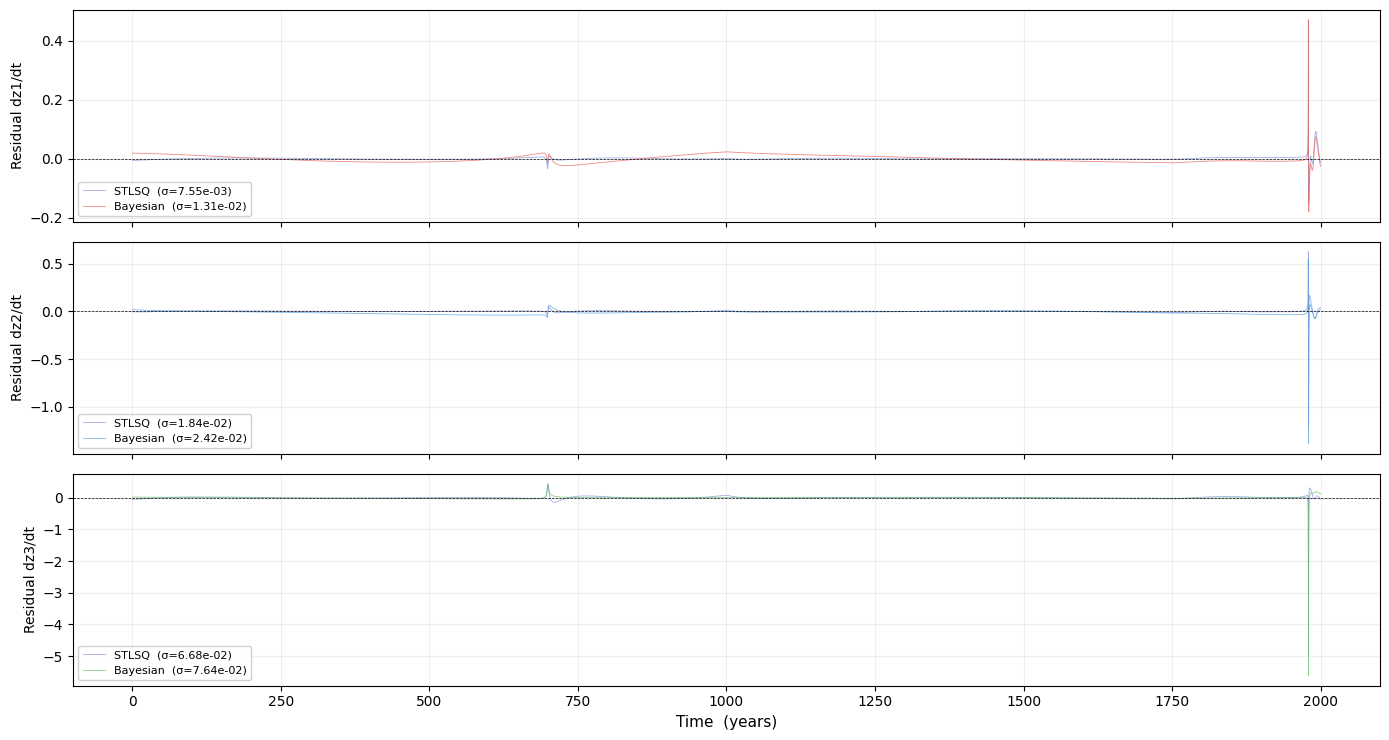

In [ ]:
"""
Plot the Discovered Polynomial Derivative Curves: STLSQ vs Bayesian SSGL
=========================================================================
Paste this cell into your notebook AFTER cells 31 and 42.

Requires in scope:
  - encNet, device, mu, sd          (encoder & normalisation)
  - Xtruth_state, U_t, dt_years     (data)
  - sindyLayer, lib_idx, latentDim   (STLSQ SINDy, cell 31)
  - results                          (Bayesian SSGL dict, cell 41)
  - _eval_poly_library               (library builder, cell 30)
"""
# ─────────────────────────────────────────────────────────────────
# 0.  Encode the full trajectory into latent space
# ─────────────────────────────────────────────────────────────────
encNet.eval()
with torch.no_grad():
    Xtruth_t  = torch.tensor(Xtruth_state, dtype=torch.float32, device=device)
    mu_t      = torch.tensor(mu, dtype=torch.float32, device=device)
    sd_t      = torch.tensor(sd, dtype=torch.float32, device=device)
    XtruthN_t = (Xtruth_t - mu_t) / (sd_t + 1e-12)
    Z_all     = encNet(XtruthN_t).detach().cpu().numpy()   # [Nt, latentDim]
    U_np      = U_t.detach().cpu().numpy()                 # [Nt, 1]

# ─────────────────────────────────────────────────────────────────
# 1.  True derivative (finite difference) & polynomial predictions
# ─────────────────────────────────────────────────────────────────
Zt   = Z_all[:-1]                                          # [Nt-1, L]
Ut   = U_np[:-1]                                           # [Nt-1, 1]
dZdt_true = dZdt

V     = np.concatenate([Zt, Ut], axis=1)                   # [Nt-1, L+1]
Theta = _eval_poly_library(V, lib_idx)                     # [Nt-1, n_lib]

# STLSQ prediction:   dz/dt = Θ · Ξ_stlsq
Xi_stlsq    = sindyLayer.Xi.detach().cpu().numpy()
dZdt_stlsq  = Theta @ Xi_stlsq                            # [Nt-1, L]

# Bayesian prediction: dz/dt = Θ · Ξ_bayes
Xi_bayes    = results['Xi_sparse']
dZdt_bayes  = Theta @ Xi_bayes                             # [Nt-1, L]

# Bayesian uncertainty band (±2σ) via posterior samples
samples     = results['samples']                           # [n_samples, n_lib, L]
n_samples   = samples.shape[0]
dZdt_samples = np.einsum('ij,sjk->sik', Theta, samples)   # [n_samples, Nt-1, L]
dZdt_lo      = np.percentile(dZdt_samples, 2.5, axis=0)   # [Nt-1, L]
dZdt_hi      = np.percentile(dZdt_samples, 97.5, axis=0)  # [Nt-1, L]

# Time axis
t = np.arange(Zt.shape[0]) * dt_years

# ─────────────────────────────────────────────────────────────────
# 2.  Time-series plot: true vs predicted derivatives
# ─────────────────────────────────────────────────────────────────
eq_colors = ["#E8594F", "#4A9BD9", "#5CB85C"]

fig, axes = plt.subplots(latentDim, 1, figsize=(14, 3.2 * latentDim),
                         sharex=True)
if latentDim == 1:
    axes = [axes]

for j in range(latentDim):
    ax = axes[j]

    # True finite-difference derivative
    ax.plot(t, dZdt_true[:, j], color="black", linewidth=0.6,
            alpha=0.45, label="True  (Savitzky-Golay)")

    # STLSQ polynomial curve
    ax.plot(t, dZdt_stlsq[:, j], color="#7B8CDE", linewidth=1.3,
            alpha=0.9, label="STLSQ  Θ·Ξ")

    # Bayesian polynomial curve + 95 % credible band
    ax.plot(t, dZdt_bayes[:, j], color=eq_colors[j], linewidth=1.3,
            alpha=0.9, label="Bayesian SSGL  Θ·Ξ")
    ax.fill_between(t, dZdt_lo[:, j], dZdt_hi[:, j],
                    color=eq_colors[j], alpha=0.15,
                    label="95 % credible band")

    ax.set_ylabel(f"dz{j+1}/dt", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="lower left", framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time  (years)", fontsize=11)
#fig.suptitle("Polynomial Derivative Curves:  True  vs  STLSQ  vs  Bayesian SSGL",
 #            fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{outdir}/sindy_derivative_timeseries.png", dpi = 200, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# 3.  Scatter: predicted dz/dt  vs  true dz/dt  (goodness of fit)
# ─────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(latentDim, 2, figsize=(10, 4 * latentDim),
                           squeeze=False)

for j in range(latentDim):
    for col, (label, pred, color) in enumerate([
        ("STLSQ",         dZdt_stlsq, "#7B8CDE"),
        ("Bayesian SSGL",  dZdt_bayes,  eq_colors[j]),
    ]):
        ax = axes2[j, col]
        truth = dZdt_true[:, j]
        prd   = pred[:, j]

        ax.scatter(truth, prd, s=3, alpha=0.25, color=color, edgecolors="none")

        # 1:1 reference line
        lo, hi = min(truth.min(), prd.min()), max(truth.max(), prd.max())
        margin = 0.05 * (hi - lo)
        ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
                'k--', linewidth=0.8, alpha=0.5)

        # R² annotation
        ss_res = np.sum((truth - prd) ** 2)
        ss_tot = np.sum((truth - truth.mean()) ** 2)
        r2 = 1.0 - ss_res / (ss_tot + 1e-8)
        rmse = np.sqrt(np.mean((truth - prd) ** 2))
        ax.text(0.05, 0.92,
                f"R² = {r2:.4f}\nRMSE = {rmse:.2e}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

        ax.set_xlabel(f"True dz{j+1}/dt", fontsize=9)
        ax.set_ylabel(f"Predicted dz{j+1}/dt", fontsize=9)
        ax.set_title(f"{label}  —  dz{j+1}/dt", fontsize=10, fontweight="bold")
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(True, alpha=0.2)

#fig2.suptitle("Predicted  vs  True Derivatives  (scatter)",
              #fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{outdir}/sindy_derivative_scatter.png", dpi = 200, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# 4.  Residual plot: where do the polynomials fail?
# ─────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(latentDim, 1, figsize=(14, 2.5 * latentDim),
                           sharex=True)
if latentDim == 1:
    axes3 = [axes3]

for j in range(latentDim):
    ax = axes3[j]
    res_stlsq = dZdt_true[:, j] - dZdt_stlsq[:, j]
    res_bayes = dZdt_true[:, j] - dZdt_bayes[:, j]

    ax.plot(t, res_stlsq, color="#7B8CDE", linewidth=0.6, alpha=0.7,
            label=f"STLSQ  (σ={np.std(res_stlsq):.2e})")
    ax.plot(t, res_bayes, color=eq_colors[j], linewidth=0.6, alpha=0.7,
            label=f"Bayesian  (σ={np.std(res_bayes):.2e})")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

    ax.set_ylabel(f"Residual dz{j+1}/dt", fontsize=10)
    ax.legend(fontsize=8, loc="lower left", framealpha=0.9)
    ax.grid(True, alpha=0.2)

axes3[-1].set_xlabel("Time  (years)", fontsize=11)
#fig3.suptitle("Residuals:  True − Predicted Derivative",
              #fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{outdir}/sindy_derivative_residuals.png", dpi = 200, bbox_inches="tight")
plt.show()

# Particle Filter

In [ ]:
"""
Particle filter

Defines the main particle-filter routine: it propagates a set of particles forward using the trained dynamics network (optionally guided by the SINDy equations), compares their predicted observations against the noisy synthetic observations, updates and resamples the particle weights, and returns the filtered state estimate along with diagnostics like effective sample size.
"""

def run_pf_once(J_fixed, seed = 0, verbose = False, do_candidate_stats = False,
                light = False, use_sindy = True, proc_sigma = 1e-3,
                guided_prop = True, nudge_gamma = 0.1, nudge_alpha = 1.0,
                jitter = 1e-5, rejuv_scale = 0.02, rejuv_floor = 0.05):

    torch.manual_seed(seed)
    np.random.seed(seed)

    # ---- Candidate stats accumulators ----
    meanESS = np.zeros(nCand, dtype = np.float64)
    meanKL  = np.zeros(nCand, dtype = np.float64)
    winsESS = np.zeros(nCand, dtype = np.int64)
    winsKL  = np.zeros(nCand, dtype = np.int64)

    # ---- Initialize particles ----
    xPriorMean = model.on.astype(np.float64)
    xPriorStd = Xtruth_state.std(axis=0) + 1e-6
    xPriorStd[5] *= 2.0

    X0p = xPriorMean[:, None] + xPriorStd[:, None] * np.random.randn(nX, Npart)
    X0pN = (X0p.T - mu) / sd
    X0pN_t = torch.tensor(X0pN, dtype=torch.float32, device=device)

    with torch.no_grad():
        Zp = encNet(X0pN_t).T  # [latentDim, Npart]

    w = torch.full((Npart,), 1.0 / Npart, device=device, dtype=torch.float32)

    # ---- Storage ----
    k_snap = [0, Nt // 2, Nt - 1]
    snap = {}

    if light:
        snap_pos = {kk: ii for ii, kk in enumerate(k_snap)}
        post_y_std = np.full((nCand, len(k_snap)), np.nan)
        NIS_pf = np.full(len(k_snap), np.nan)
        ESS_pf = np.full(len(k_snap), np.nan)
        Xfilt = None
    else:
        post_y_std = np.zeros((nCand, Nt))
        NIS_pf = np.zeros(Nt)
        ESS_pf = np.zeros(Nt)
        Xfilt = np.zeros((nX, Nt))

    # ---- PF loop ----
    for k in range(Nt):

        # ======== FORECAST ========
        if k > 0:
            with torch.no_grad():
                u_k = U_t[k - 1].to(device).view(1, 1).expand(Npart, 1)
                if use_sindy:
                    rhs = lambda zz: sindy_rhs(zz, u_k)
                else:
                    rhs = lambda zz: dynNet(torch.cat([zz, u_k], dim=1))
                Zp = runge_kutta(Zp.T.contiguous().float(), dt_years, rhs).T

            if proc_sigma > 0:
                Zp = Zp + proc_sigma * torch.randn_like(Zp)

            if not check_finite(Zp, "Zp (after forecast)", k):
                return Xfilt, ESS_pf, post_y_std, NIS_pf

            Zp = torch.clamp(Zp, -10.0, 10.0)
            Zp = maybe_rejuvenate(Zp)

        # ======== DECODE + OBSERVE ========
        Xp_t, Yp_all_t = decode_and_observe(Zp)

        if not check_finite(Yp_all_t, "Yp_all_t (after decode)", k):
            return Xfilt, ESS_pf, post_y_std, NIS_pf

        # Save prior for plotting (before weights change)
        if verbose and (k in k_snap):
            Yp_all_prior_t = Yp_all_t.clone()
            w_prior = w.clone()

        y_all_k = Yobs_all_t[:, k]

        # ======== CANDIDATE STATISTICS (optional) ========
        if do_candidate_stats:
            for j in range(nCand):
                sigma_j = sig_all_t[j]
                innov_j = Yp_all_t[j, :] - y_all_k[j]
                logL_j = -0.5 * (innov_j**2) / (sigma_j**2 + eps)

                wj = w * torch.exp(logL_j - logL_j.max())
                wj = wj / (wj.sum() + eps)

                meanESS[j] += (1.0 / (torch.sum(wj**2) + eps)).item()
                meanKL[j]  += torch.sum(wj * torch.log(wj * Npart + eps)).item()

            winsESS[int(torch.tensor(meanESS).argmax())] += 1
            winsKL[int(torch.tensor(meanKL).argmax())] += 1

        # ======== SELECT OBSERVATIONS ========
        J = torch.as_tensor(J_fixed, device = device, dtype = torch.long)
        B = J.numel()

        yk_t   = Yobs_all_t[J, k].view(-1, 1)    # [B, 1]
        yhat_t = Yp_all_t[J, :]                    # [B, Npart]
        sig_t  = sig_all_t[J].view(-1, 1)          # [B, 1]

        # ======== EnKF PROPOSAL (optional) ========
        if guided_prop:
            with torch.no_grad():
                Zp = enkf_proposal(Zp, yhat_t, yk_t, w, sig_t,
                                   nudge_gamma, nudge_alpha, jitter)
                Xp_t, Yp_all_t = decode_and_observe(Zp)

                if not check_finite(Yp_all_t, "Yp_all_t (after nudge)", k):
                    return Xfilt, ESS_pf, post_y_std, NIS_pf

                yhat_t = Yp_all_t[J, :]

        # ======== WEIGHT UPDATE ========
        ymean_sel = (w[None, :] * yhat_t).sum(dim = 1, keepdim = True)
        yvar_sel  = (w[None, :] * (yhat_t - ymean_sel)**2).sum(dim = 1, keepdim = True)
        sigma_model = 0.1 * torch.sqrt(yvar_sel + 1e-12)
        sig_eff = torch.sqrt(sig_t**2 + sigma_model**2)

        innov_t = yhat_t - yk_t
        quad_t = torch.sum((innov_t / (sig_eff + eps))**2, dim=0)

        gamma_weight = nudge_gamma if guided_prop else 0.0
        logL_t  = -0.5 * (1.0 - gamma_weight) * quad_t

        logL_t = torch.where(torch.isfinite(logL_t), logL_t,
                             torch.tensor(-1e30, device=device))

        logw_t = torch.log(w + eps) + logL_t
        logw_t -= logw_t.max()
        w = torch.exp(logw_t)
        w /= (w.sum() + eps)

        ESS_now = (1.0 / (torch.sum(w**2) + eps)).item()
        NIS_now = (w * quad_t).sum().item()

        # ======== POSTERIOR DECODE (for storage) ========
        Xp_t, Yp_all_t = decode_and_observe(Zp)

        if not check_finite(Yp_all_t, "Yp_all_t (after weights)", k):
            return Xfilt, ESS_pf, post_y_std, NIS_pf

        ypost_mean = (w[None, :] * Yp_all_t).sum(dim=1)
        ypost_var  = (w[None, :] * (Yp_all_t - ypost_mean[:, None])**2).sum(dim=1)

        # ======== STORE ========
        if light:
            if k in snap_pos:
                ii = snap_pos[k]
                post_y_std[:, ii] = torch.sqrt(ypost_var + 1e-12).cpu().numpy()
                ESS_pf[ii] = ESS_now
                NIS_pf[ii] = NIS_now
        else:
            post_y_std[:, k] = torch.sqrt(ypost_var + 1e-12).cpu().numpy()
            ESS_pf[k] = ESS_now
            NIS_pf[k] = NIS_now
            Xfilt[:, k] = (Xp_t @ w).detach().cpu().numpy()

        if k in k_snap:
            snap[k] = (Xp_t.detach().cpu().numpy(), w.detach().cpu().numpy())

        # ======== VERBOSE ========
        if verbose and (k % 5000 == 0):
            print(f"k={k}, ESS={ESS_now:.1f}, NIS={NIS_now:.2f}, "
                  f"J={[ObsNames[int(x)] for x in J]}")

        if verbose and (k in k_snap):
            log_pf_step(k, J, Yp_all_prior_t, w_prior, Yp_all_t, w,
                        Ytruth_all_t, Yobs_all_t, Zp, Xp_t)

        # ======== RESAMPLE ========
        if ESS_now < resampESS * Npart:
            idx_r = systematic_resample_torch(w)
            Zp = Zp.index_select(dim=1, index=idx_r)
            scale = Zp.std(dim=1, keepdim=True) + 1e-6
            Zp = Zp + (rejuv_scale * scale + rejuv_floor) * torch.randn_like(Zp)
            w = torch.full((Npart,), 1.0 / Npart, device=device, dtype=torch.float32)

        # ======== RESEED ========
        Zp, did_reseed = reseed_collapsed_particles(Zp, w, Xp_t, Yp_all_t)
        if verbose and did_reseed:
            print(f"  [RESEED] k={k}")

    return Xfilt, ESS_pf, post_y_std, NIS_pf

## Systematic observation-noise recalibration (Mehra / Dee)

In [ ]:
"""
Recalibrate the noise settings

Separates two different sources of error that were previously lumped together into the observation-noise setting: genuine observation noise (which should stay tied to the natural spread of the true data) and the dynamics network's own one-step prediction error (which is better treated as process noise added to the latent forecast, rather than inflating the observation noise). Keeping them separate stops the particle filter from becoming overconfident and losing track of the collapsed ('off') branch.
"""

print("Recalibrating: σ_obs held at climatological floor, "
      "surrogate error routed into latent process noise...")

encNet = encNet.to(device).eval()
decNet = decNet.to(device).eval()
dynNet = dynNet.to(device).eval()

mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
sd_t = torch.tensor(sd, dtype=torch.float32, device=device)

with torch.no_grad():
    # Encode the truth trajectory in normalised state space
    XN_t_local = torch.tensor((Xtruth_state - mu) / sd,
                              dtype=torch.float32, device=device)
    Z_truth = encNet(XN_t_local)                       # (Nt, latentDim)

    # One-step RK4 rollout of dynNet — same integrator/forcing the PF uses
    u_in = U_t[:Z_truth.shape[0] - 1].to(device)
    rhs = lambda zz: dynNet(torch.cat([zz, u_in], dim=1))
    Z_pred = runge_kutta(Z_truth[:-1].contiguous(), dt_years, rhs)  # (Nt-1, latentDim)

    # (1) Latent one-step residual -> PROCESS-NOISE scale (per dim + scalar)
    latent_resid = (Z_truth[1:] - Z_pred).cpu().numpy()            # (Nt-1, latentDim)
    proc_sigma_per_dim = latent_resid.std(axis=0)
    proc_sigma_recal = float(np.median(proc_sigma_per_dim))

    # (2) Observation-space one-step residual -> DIAGNOSTIC only
    X_pred = decNet(Z_pred) * sd_t + mu_t                          # (Nt-1, nX)
    Y_pred = obs_candidates_torch(X_pred.T)                        # (p, Nt-1)
    Y_true_step = Ytruth_all_t[:, 1:Z_truth.shape[0]]
    obs_resid = (Y_pred - Y_true_step).cpu().numpy()               # (p, Nt-1)
    emp_std = obs_resid.std(axis=1)

# σ_obs stays at the climatological value set in Step 1 (NO inflation)
sig_clim_np = obsSigmas_all.copy()
sig_all_t = torch.tensor(sig_clim_np, dtype=torch.float32, device=device)

print(f"\nLatent process-noise scale (per dim): "
      f"{np.array2string(proc_sigma_per_dim, precision=4)}")
print(f"  -> proc_sigma_recal (median) = {proc_sigma_recal:.4e}  "
      f"(previous PF default was 1e-3)")

print(f"\n{'Observable':10s}  {'σ_obs (clim)':>12s}  "
      f"{'obs 1-step resid':>16s}   note")
print("-" * 64)
for j, nm in enumerate(ObsNames):
    note = ("obs noise dominates" if sig_clim_np[j] >= emp_std[j]
            else "surrogate error -> handled by process noise")
    print(f"  {nm:10s}  {sig_clim_np[j]:12.5f}  {emp_std[j]:16.5f}   {note}")

# Regenerate noisy observations with the (unchanged) climatological σ,
# reproducibly, so downstream PF runs are consistent.
torch.manual_seed(1)   # reproducible obs draw (matches cell-15 seed)
noise_t = sig_all_t[:, None] * torch.randn(nCand, Nt, device=device)
Yobs_all_t = Ytruth_all_t + noise_t
Yobs_all_t[name_to_idx["SeaIce"]] = torch.clamp(
    Yobs_all_t[name_to_idx["SeaIce"]], 0.0, 1.0
)

print(f"\nσ_obs unchanged (climatological); surrogate error now carried by "
      f"proc_sigma_recal = {proc_sigma_recal:.4e}.")
print("The gamma sweep passes proc_sigma=proc_sigma_recal to run_pf_once.")


Recalibrating: σ_obs held at climatological floor, surrogate error routed into latent process noise...

Latent process-noise scale (per dim): [0.0001 0.0004 0.0014]
  -> proc_sigma_recal (median) = 4.2271e-04  (previous PF default was 1e-3)

Observable  σ_obs (clim)  obs 1-step resid   note
----------------------------------------------------------------
  AMOC_ice         0.46972        1820.26733   surrogate error -> handled by process noise
  SeaIce           0.02029           0.03106   surrogate error -> handled by process noise
  FovS             0.00352           0.00714   surrogate error -> handled by process noise
  T_n              0.10465           0.38932   surrogate error -> handled by process noise

σ_obs unchanged (climatological); surrogate error now carried by proc_sigma_recal = 4.2271e-04.
The gamma sweep passes proc_sigma=proc_sigma_recal to run_pf_once.


In [ ]:
"""
Observation-set search (archived)

An expensive, resumable search over which combination of observed variables gives the best particle-filter performance, tested over multiple random seeds and repeats, with progress saved to disk so it can be interrupted and resumed. Left commented out here since it takes many hours to run; kept for reference.
"""

In [ ]:
"""
Chosen observation set

Records the observation set selected from the search above (AMOC_ice only) for use in the analysis that follows.
"""

best_J = np.array([0], dtype=np.int64)   # AMOC_ice only, from completed obs-set search
print("Using best_J =", best_J, "→", [ObsNames[j] for j in best_J])

Using best_J = [0] → ['AMOC_ice']


In [ ]:
"""
Sweep the EnKF nudge strength

Runs the particle filter with several different strengths of the ensemble-Kalman-style nudge (from none to fairly strong), to see which setting gives the best-behaved filter.
"""

GAMMAS = [0.0, 0.05, 0.10, 0.25, 0.50]

J_use = best_J
sweep = {}

for gamma in GAMMAS:
    print(f"\nRunning PF with EnKF nudge ON, gamma = {gamma}")

    Xfilt_g, ESS_g, post_y_std_g, NIS_g = run_pf_once(
        J_use,                       # first positional argument
        seed = 0,
        verbose = False,
        do_candidate_stats = True,
        light = False,
        guided_prop = True,
        nudge_gamma = gamma,
        proc_sigma = proc_sigma_recal,
    )

    sweep[gamma] = {
        "Xfilt": Xfilt_g,
        "ESS": ESS_g,
        "post_y_std": post_y_std_g,
        "NIS": NIS_g,
    }

print("\nGamma sweep finished.")


Running PF with EnKF nudge ON, gamma = 0.0
[NaN] Yp_all_t (after nudge) non-finite at k=0

Running PF with EnKF nudge ON, gamma = 0.05

Running PF with EnKF nudge ON, gamma = 0.1

Running PF with EnKF nudge ON, gamma = 0.25

Running PF with EnKF nudge ON, gamma = 0.5

Gamma sweep finished.


 gamma  RMSE AMOC_ice (post)  RMSE f_n (post)  mean PF f_n (post)  mean true f_n (post)  median ESS  median NIS
  0.00            813.763489         0.040373            1.000000              0.959634    0.000000    0.000000
  0.05              1.096250         0.304052            0.656149              0.959634  126.632114    1.017810
  0.10              1.176884         0.304053            0.656148              0.959634  130.260162    1.102502
  0.25              1.279011         0.304072            0.656130              0.959634  148.327126    1.277114
  0.50              1.192311         0.301991            0.658172              0.959634  167.889702    1.848107


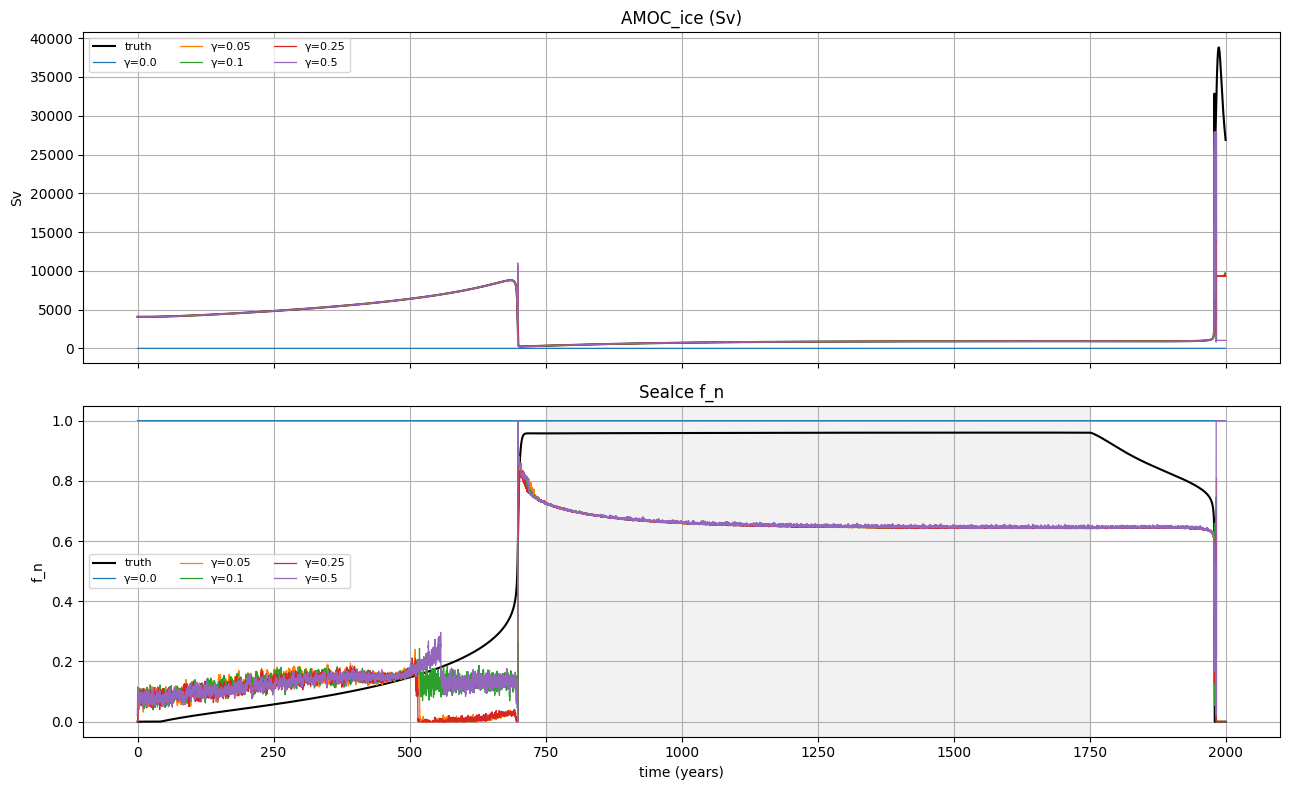

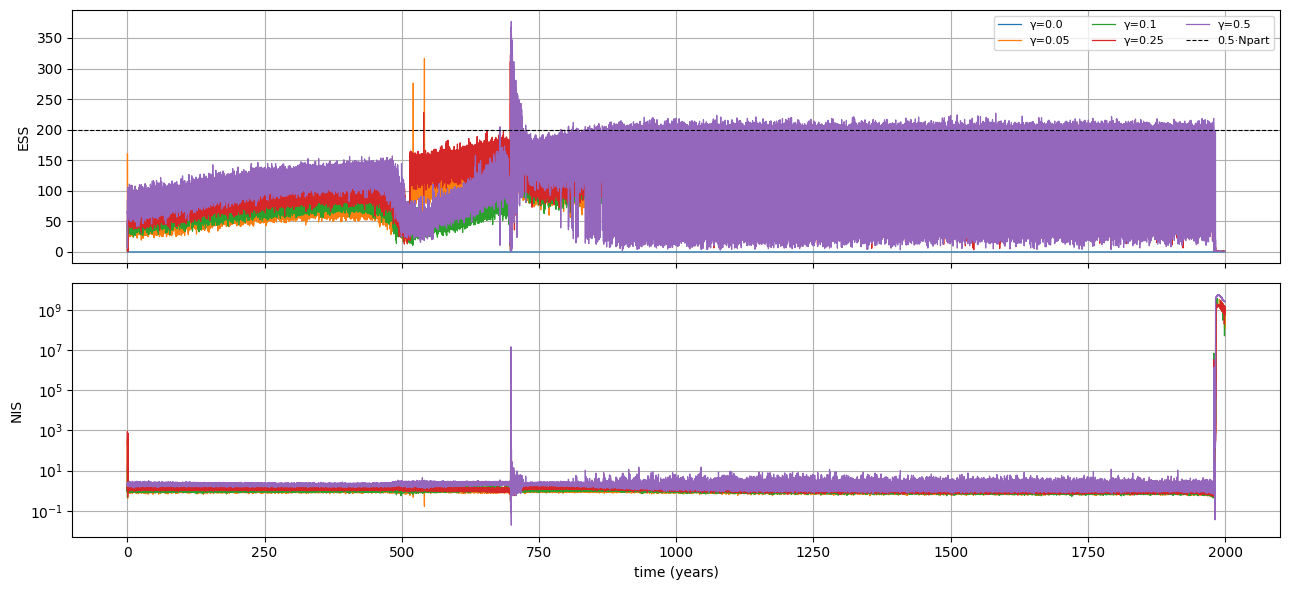

,gamma,RMSE AMOC_ice (post),RMSE f_n (post),mean PF f_n (post),mean true f_n (post),median ESS,median NIS
0,0.00,813.763489,0.040373,1.000000,0.959634,0.000000,0.000000
1,0.05,1.096250,0.304052,0.656149,0.959634,126.632114,1.017810
2,0.10,1.176884,0.304053,0.656148,0.959634,130.260162,1.102502
3,0.25,1.279011,0.304072,0.656130,0.959634,148.327126,1.277114
4,0.50,1.192311,0.301991,0.658172,0.959634,167.889702,1.848107


In [ ]:
"""
Gamma-sweep diagnostics

Compares the different nudge-strength settings from the previous cell over the post-collapse period, to see which one lets the filter correctly stay on the collapsed ('off') branch rather than drifting back.
"""

import pandas as pd
import matplotlib.pyplot as plt

idx_amoc = ObsNames.index("AMOC_ice")
idx_fn   = ObsNames.index("SeaIce")

# Post-collapse, pre-recovery window in YEARS, converted to indices.
# Truth f_n is ~0.95 across this window, so it's the cleanest test
# of whether the PF can stay on the off-branch.
year1, year2 = 750, 1750
k1 = int(year1 / dt_years)
k2 = min(int(year2 / dt_years), Nt)

# --- observation-space truth on the full grid (cache once) ---
with torch.no_grad():
    Xtrue_t  = torch.as_tensor(Xtruth_state.T, dtype=torch.float32, device=device)  # [11,Nt]
    Ytrue    = obs_candidates_torch(Xtrue_t).T.detach().cpu().numpy()               # [Nt,p]

summary_rows = []
pf_obs       = {}   # cache obs-space PF mean for plotting

for gamma, res in sweep.items():
    Xfilt_g = res["Xfilt"]                              # [11, Nt]
    Xfilt_g = np.asarray(Xfilt_g)

    # Push PF state mean through the candidate-obs operator
    with torch.no_grad():
        Xpf_t = torch.as_tensor(Xfilt_g, dtype=torch.float32, device=device)  # [11,Nt]
        Ypf   = obs_candidates_torch(Xpf_t).T.detach().cpu().numpy()          # [Nt,p]
    pf_obs[gamma] = Ypf

    rmse_amoc = np.sqrt(np.mean((Ypf[k1:k2, idx_amoc] - Ytrue[k1:k2, idx_amoc])**2))
    rmse_fn   = np.sqrt(np.mean((Ypf[k1:k2, idx_fn]   - Ytrue[k1:k2, idx_fn])**2))

    ESS_g = np.asarray(res["ESS"])
    NIS_g = np.asarray(res["NIS"])

    summary_rows.append({
        "gamma":               gamma,
        "RMSE AMOC_ice (post)": rmse_amoc,
        "RMSE f_n (post)":      rmse_fn,
        "mean PF f_n (post)":   np.mean(Ypf[k1:k2, idx_fn]),
        "mean true f_n (post)": np.mean(Ytrue[k1:k2, idx_fn]),
        "median ESS":           np.median(ESS_g),
        "median NIS":           np.median(NIS_g[np.isfinite(NIS_g)]),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ---------- plot: AMOC_ice and f_n trajectories per gamma ----------
t = np.arange(Nt) * dt_years
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t, Ytrue[:, idx_amoc], "k", lw=1.5, label="truth")
for gamma, Ypf in pf_obs.items():
    axes[0].plot(t, Ypf[:, idx_amoc], lw=0.9, label=f"γ={gamma}")
axes[0].set_title("AMOC_ice (Sv)")
axes[0].set_ylabel("Sv"); axes[0].grid(True); axes[0].legend(ncol=3, fontsize=8)

axes[1].plot(t, Ytrue[:, idx_fn], "k", lw=1.5, label="truth")
for gamma, Ypf in pf_obs.items():
    axes[1].plot(t, Ypf[:, idx_fn], lw=0.9, label=f"γ={gamma}")
axes[1].set_title("SeaIce f_n")
axes[1].set_ylabel("f_n"); axes[1].set_xlabel("time (years)")
axes[1].grid(True); axes[1].legend(ncol=3, fontsize=8)

axes[1].axvspan(year1, year2, color="gray", alpha=0.1, label="post-collapse window")
plt.tight_layout(); plt.show()

# ---------- plot: ESS and NIS per gamma ----------
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for gamma, res in sweep.items():
    axes[0].plot(t, np.asarray(res["ESS"]), lw=0.9, label=f"γ={gamma}")
    axes[1].plot(t, np.asarray(res["NIS"]), lw=0.9, label=f"γ={gamma}")
axes[0].axhline(0.5 * Npart, color="k", ls="--", lw=0.8, label="0.5·Npart")
axes[0].set_ylabel("ESS"); axes[0].grid(True); axes[0].legend(ncol=3, fontsize=8)
axes[1].set_ylabel("NIS"); axes[1].set_xlabel("time (years)")
axes[1].set_yscale("log"); axes[1].grid(True, which="both")
plt.tight_layout(); plt.show()

summary_df

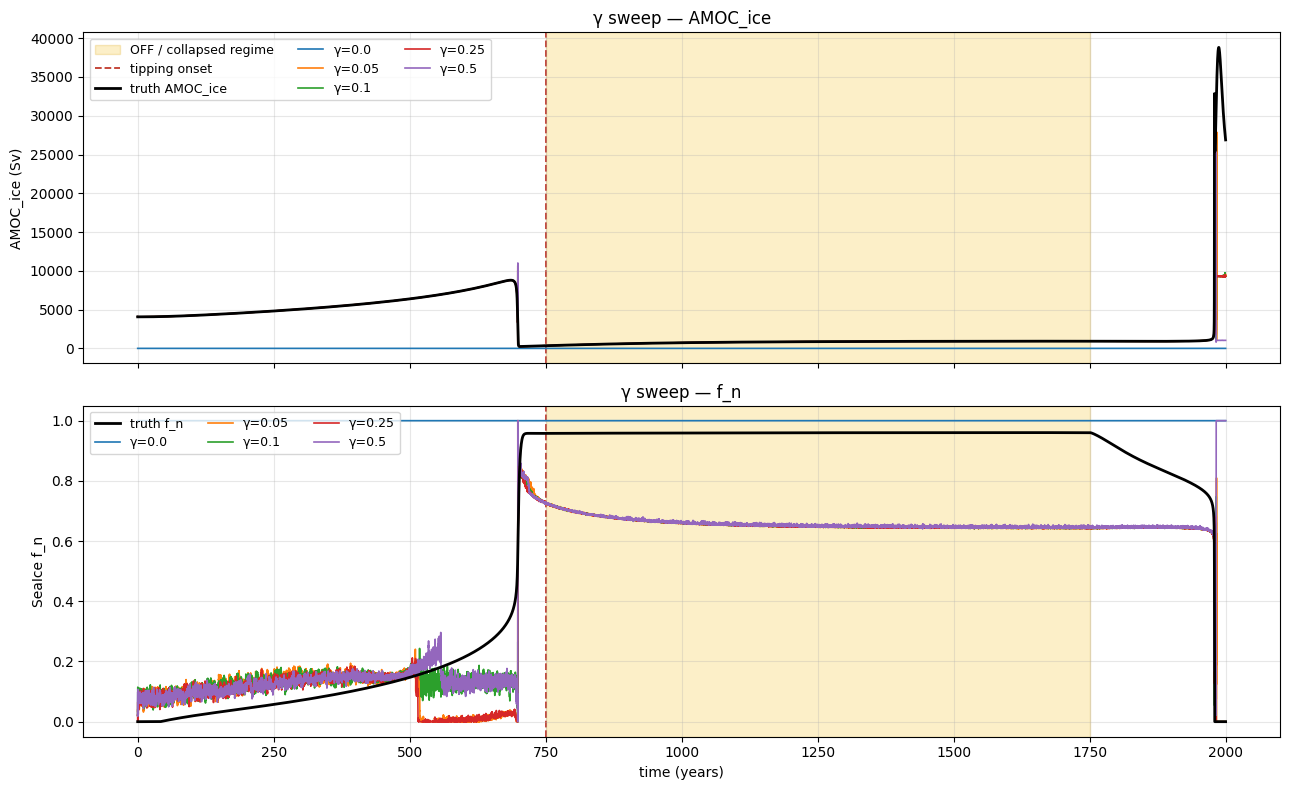

In [ ]:
"""
Plot the gamma comparison

Plots the filtered state against the truth for each nudge-strength setting, focused on the post-collapse period, to visually compare how well each setting tracks the true, collapsed branch.
"""

import matplotlib.pyplot as plt

idx_amoc = ObsNames.index("AMOC_ice")
idx_fn   = ObsNames.index("SeaIce")

# Truth in observation space — compute once.
with torch.no_grad():
    Xtrue_t = torch.as_tensor(Xtruth_state.T, dtype=torch.float32, device=device)  # [11,Nt]
    Ytrue   = obs_candidates_torch(Xtrue_t).T.detach().cpu().numpy()                # [Nt,p]

t = np.arange(Nt) * dt_years
year1, year2 = 750, 1750   # post-collapse / OFF window

def add_regime_band(ax, show_label=False):
    """Shade the collapsed-regime window and mark the tipping onset."""
    ax.axvspan(year1, year2,
               facecolor="#f2b705", alpha=0.22, edgecolor="#d99e00",
               linewidth=1.0, zorder=0,
               label="OFF / collapsed regime" if show_label else None)
    ax.axvline(year1, color="#c0392b", ls="--", lw=1.3, zorder=1,
               label="tipping onset" if show_label else None)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# draw bands first so the curves sit on top
for i, ax in enumerate(axes):
    add_regime_band(ax, show_label=(i == 0))

axes[0].plot(t, Ytrue[:, idx_amoc], color="black", lw=2.0, label="truth AMOC_ice", zorder=3)
axes[1].plot(t, Ytrue[:, idx_fn],   color="black", lw=2.0, label="truth f_n",      zorder=3)

for gamma, res in sweep.items():
    Xfilt_g = np.asarray(res["Xfilt"])    # [11, Nt]
    with torch.no_grad():
        Xpf_t = torch.as_tensor(Xfilt_g, dtype=torch.float32, device=device)
        Ypf   = obs_candidates_torch(Xpf_t).T.detach().cpu().numpy()
    axes[0].plot(t, Ypf[:, idx_amoc], lw=1.2, label=f"γ={gamma}", zorder=2)
    axes[1].plot(t, Ypf[:, idx_fn],   lw=1.2, label=f"γ={gamma}", zorder=2)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=9, loc="upper left")

axes[0].set_ylabel("AMOC_ice (Sv)"); axes[0].set_title("γ sweep — AMOC_ice")
axes[1].set_ylabel("SeaIce f_n");    axes[1].set_xlabel("time (years)")
axes[1].set_title("γ sweep — f_n")

plt.tight_layout()
plt.show()

# Final re-run

k=0, ESS=46.3, NIS=1.06, J=['AMOC_ice']
[DEBUG] k=0: mean std(Z)=7.346e-01, mean std(X)=4.518e+00, mean std(Y)=1.560e+02
[DEBUG] per-obs std: AMOC_ice=6.235e+02, SeaIce=7.743e-02, FovS=1.238e-01, T_n=4.604e-01

--- k=0  selected J=['AMOC_ice'] ---


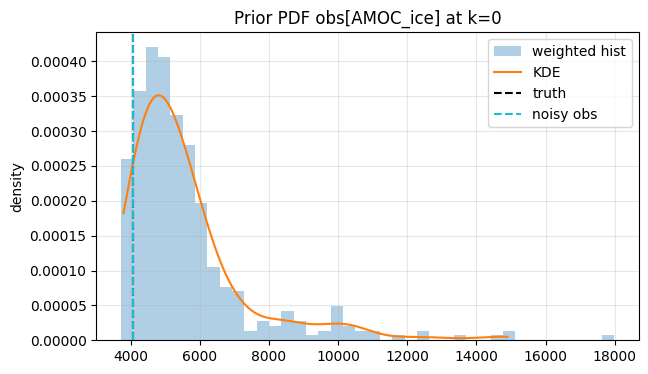

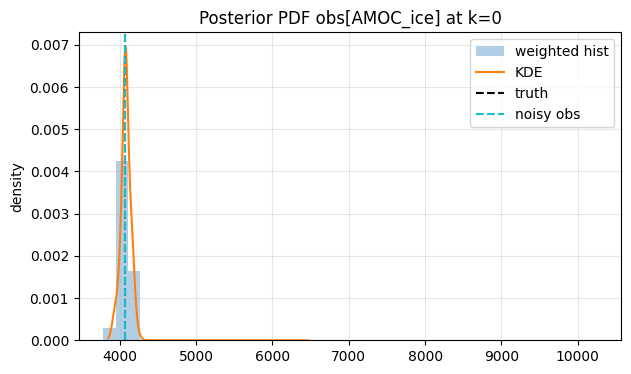

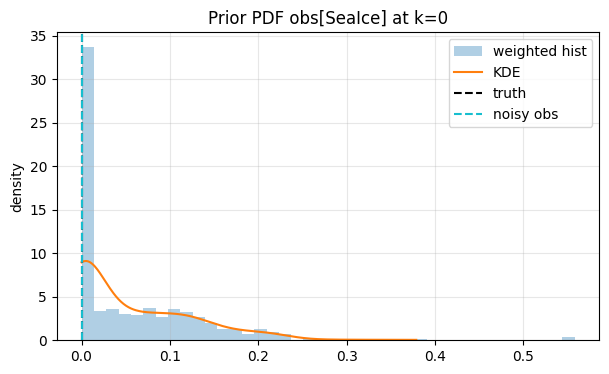

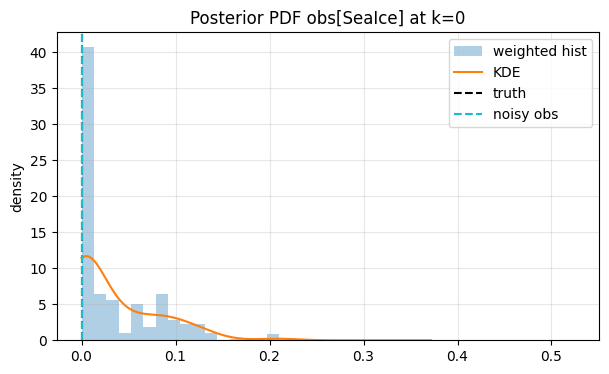

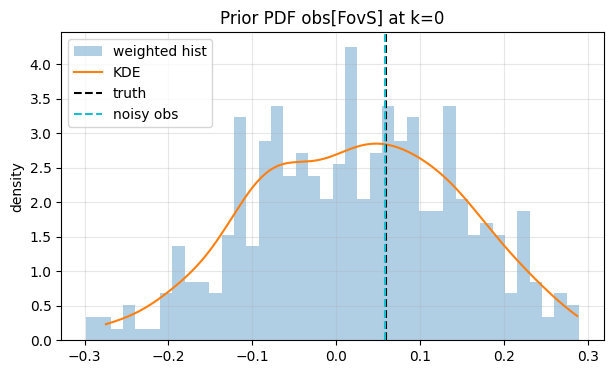

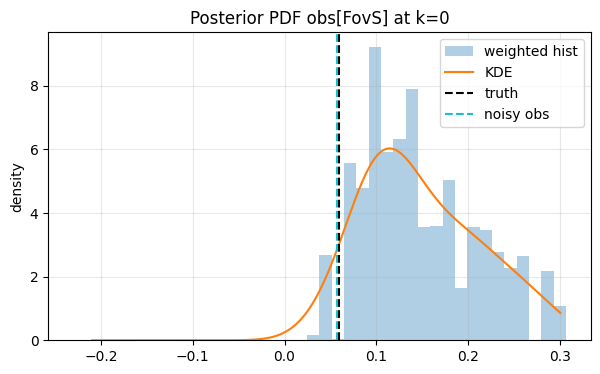

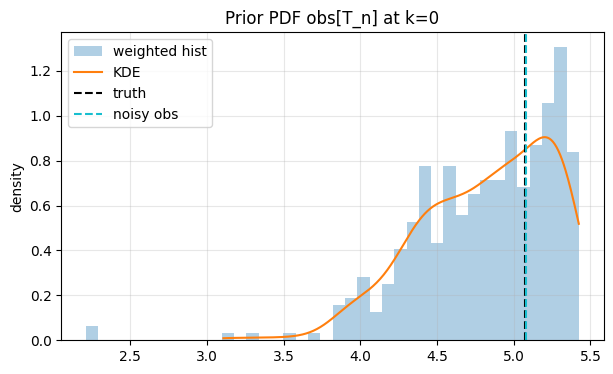

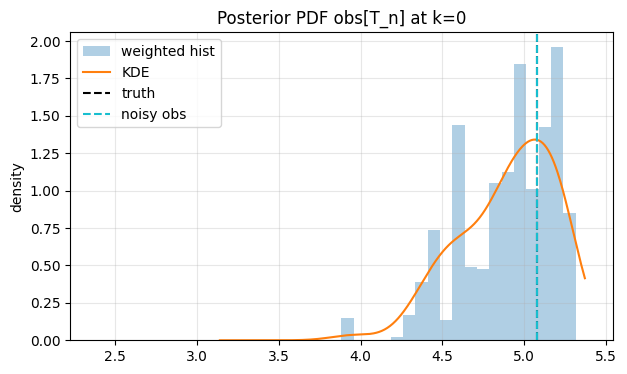

k=5000, ESS=63.1, NIS=0.87, J=['AMOC_ice']
k=10000, ESS=60.8, NIS=0.99, J=['AMOC_ice']
k=15000, ESS=76.9, NIS=1.09, J=['AMOC_ice']
k=20000, ESS=87.4, NIS=1.13, J=['AMOC_ice']
k=25000, ESS=83.2, NIS=1.01, J=['AMOC_ice']
k=30000, ESS=85.8, NIS=0.90, J=['AMOC_ice']
k=35000, ESS=79.9, NIS=1.18, J=['AMOC_ice']
  [RESEED] k=39535
k=40000, ESS=128.0, NIS=1.06, J=['AMOC_ice']
k=45000, ESS=117.5, NIS=1.12, J=['AMOC_ice']
k=50000, ESS=123.4, NIS=0.89, J=['AMOC_ice']
  [RESEED] k=50915
  [RESEED] k=50928
  [RESEED] k=50954
  [RESEED] k=50957
  [RESEED] k=50964
  [RESEED] k=50966
  [RESEED] k=50969
  [RESEED] k=50972
  [RESEED] k=50976
  [RESEED] k=50978
  [RESEED] k=50982
  [RESEED] k=50985
  [RESEED] k=50998
  [RESEED] k=51000
  [RESEED] k=51003
  [RESEED] k=51005
k=55000, ESS=114.3, NIS=1.04, J=['AMOC_ice']
k=60000, ESS=130.4, NIS=1.31, J=['AMOC_ice']
k=65000, ESS=135.2, NIS=1.15, J=['AMOC_ice']
k=70000, ESS=154.5, NIS=1.06, J=['AMOC_ice']
[DEBUG] k=73000: mean std(Z)=1.219e-01, mean std(X)=2.0

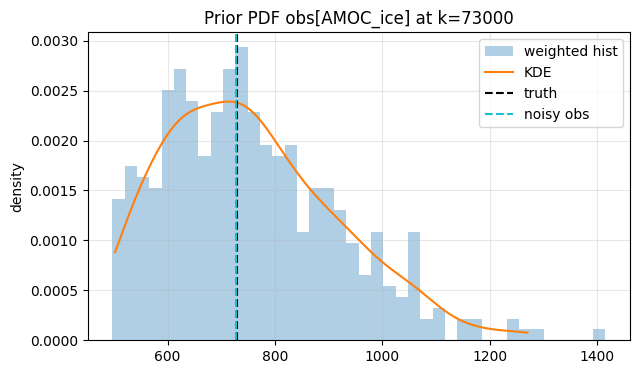

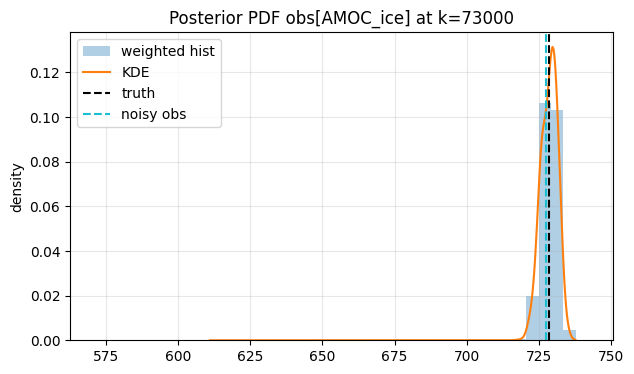

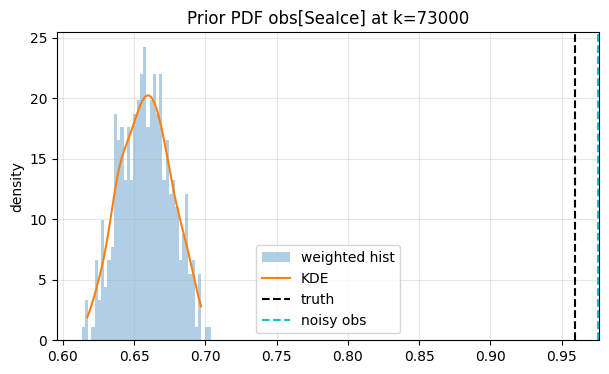

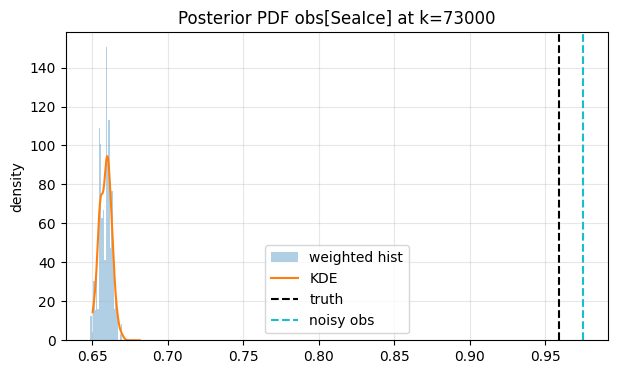

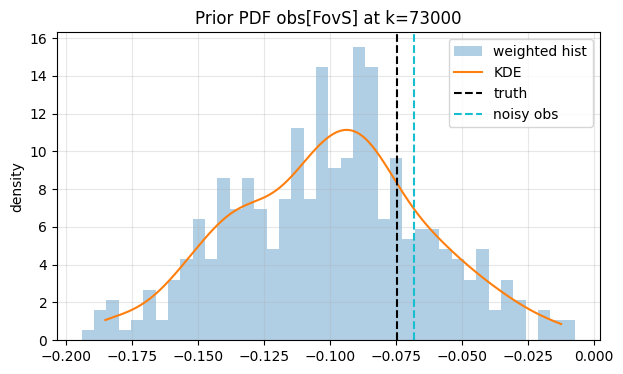

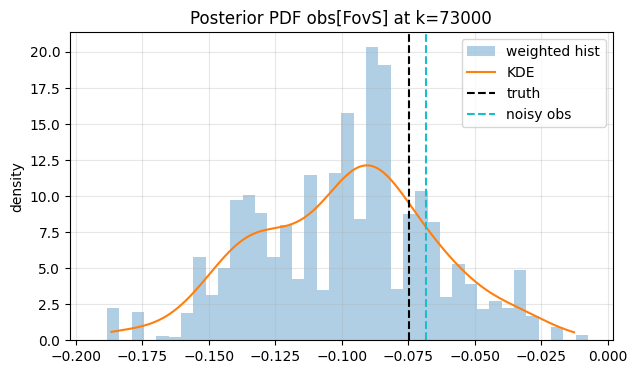

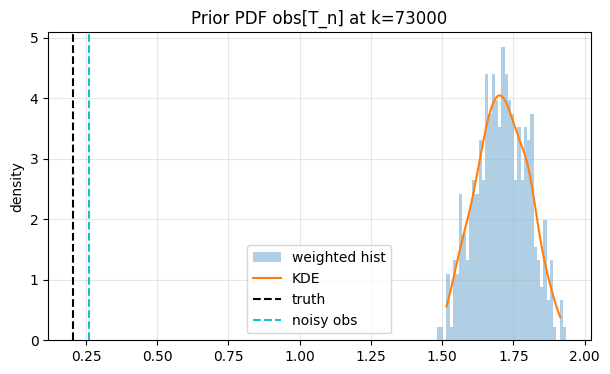

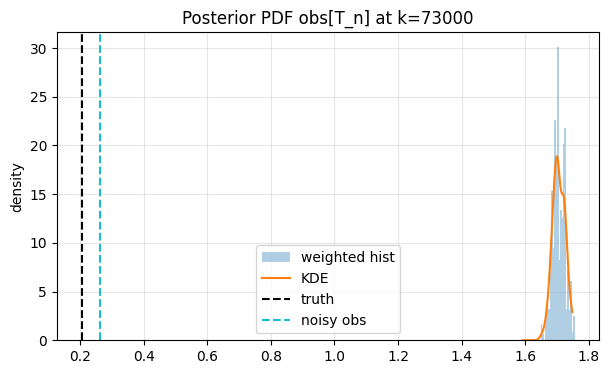

k=75000, ESS=128.1, NIS=1.16, J=['AMOC_ice']
k=80000, ESS=145.6, NIS=1.10, J=['AMOC_ice']
k=85000, ESS=157.5, NIS=1.12, J=['AMOC_ice']
k=90000, ESS=165.7, NIS=0.90, J=['AMOC_ice']
k=95000, ESS=174.2, NIS=0.96, J=['AMOC_ice']
k=100000, ESS=151.5, NIS=1.04, J=['AMOC_ice']
k=105000, ESS=160.9, NIS=1.16, J=['AMOC_ice']
k=110000, ESS=166.3, NIS=0.80, J=['AMOC_ice']
k=115000, ESS=169.6, NIS=0.81, J=['AMOC_ice']
k=120000, ESS=149.5, NIS=1.19, J=['AMOC_ice']
k=125000, ESS=166.5, NIS=0.90, J=['AMOC_ice']
k=130000, ESS=152.7, NIS=0.86, J=['AMOC_ice']
k=135000, ESS=153.1, NIS=1.14, J=['AMOC_ice']
k=140000, ESS=163.1, NIS=0.79, J=['AMOC_ice']
  [RESEED] k=144502
  [RESEED] k=144506
  [RESEED] k=144517
  [RESEED] k=144707
  [RESEED] k=144724
  [RESEED] k=144730
  [RESEED] k=144733
  [RESEED] k=144741
  [RESEED] k=144746
  [RESEED] k=144749
  [RESEED] k=144750
  [RESEED] k=144751
  [RESEED] k=144752
  [RESEED] k=144753
  [RESEED] k=144754
  [RESEED] k=144755
  [RESEED] k=144756
  [RESEED] k=144757
 

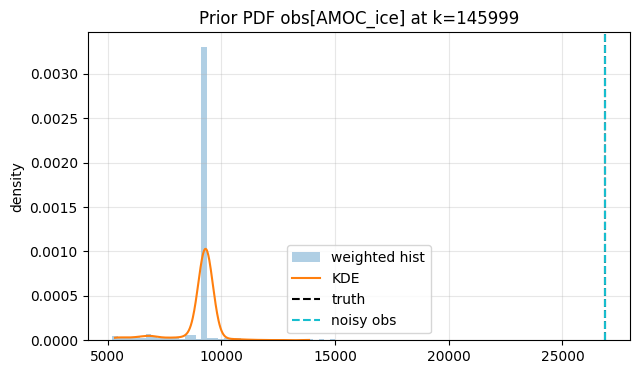

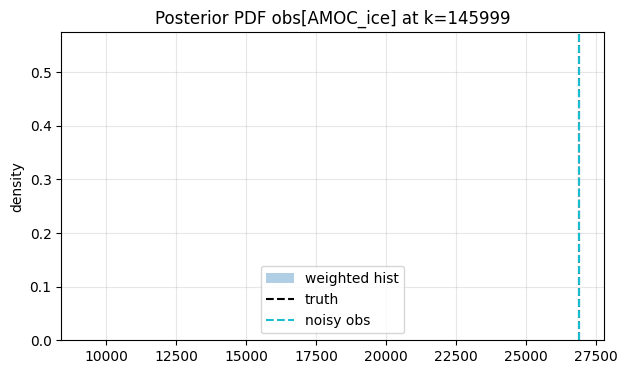

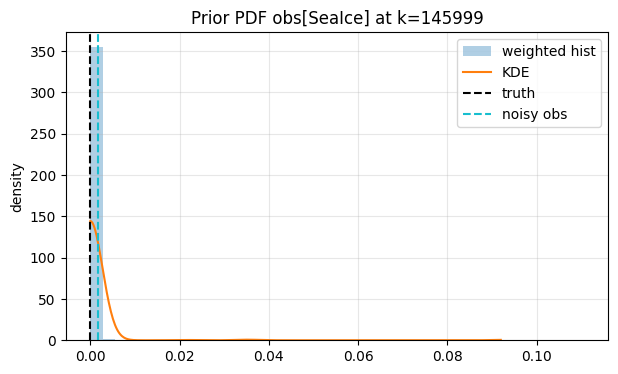

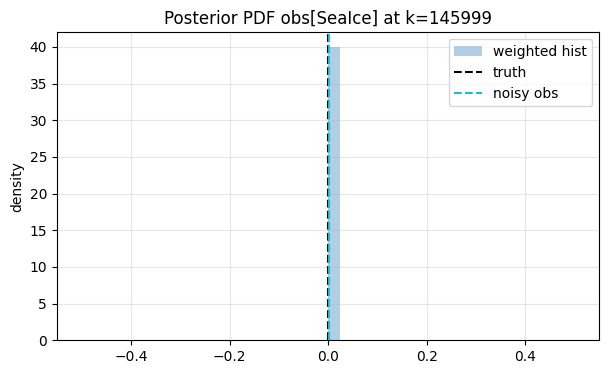

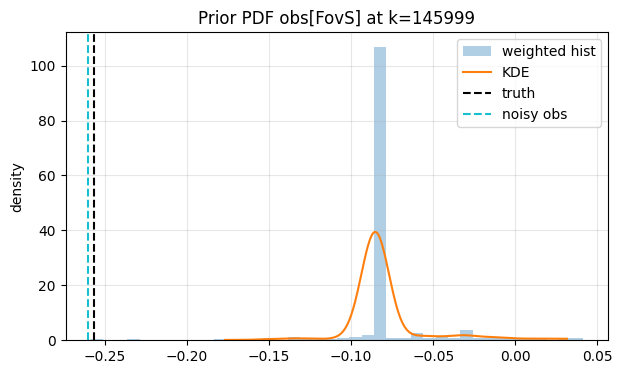

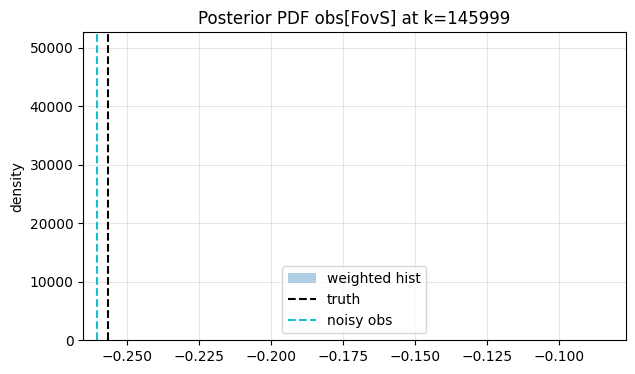

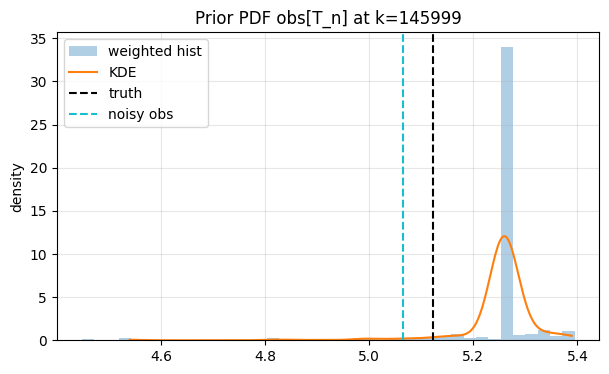

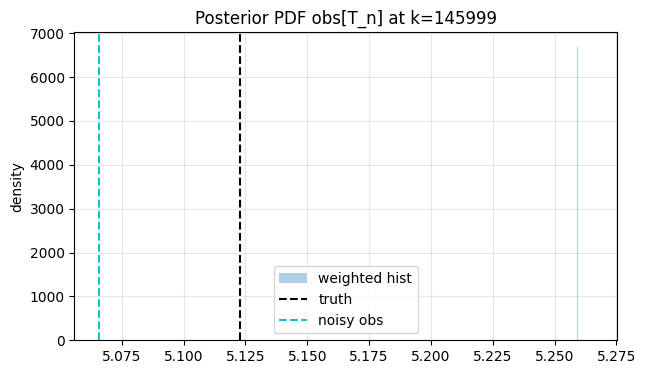

  [RESEED] k=145999


In [ ]:
"""
Run the final particle filter

Runs the particle filter one more time with the chosen observation set and settings, this time with full diagnostics and verbose output, producing the final filtered trajectory used in the plots below.
"""

Xfilt, ESS_pf, post_y_std, NIS_pf = run_pf_once(
    best_J, seed=0, verbose=True, do_candidate_stats=True, light=False)

In [ ]:
"""
Save the final particle-filter results

Saves the final filtered trajectory and its diagnostics to disk, tagged with the observation set used and a timestamp, so the results and plots can be regenerated later without re-running the filter.
"""

# ────────────────────────────────────────────────────────────────
# Save the Final re-run PF outputs (raw arrays + plot directory)
# ────────────────────────────────────────────────────────────────
import os, datetime

PLOT_DIR = "/content/drive/MyDrive/eccm_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Tag with best_J + timestamp so re-runs don't overwrite previous results
_tag = "_".join(ObsNames[j] for j in best_J) + \
       "_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Plot/arrays tag: {_tag}")

# Save raw PF outputs so any plot can be regenerated later without re-running
_npz_path = os.path.join(PLOT_DIR, f"pf_arrays_{_tag}.npz")
np.savez_compressed(
    _npz_path,
    Xfilt       = Xfilt,
    ESS_pf      = ESS_pf,
    post_y_std  = post_y_std,
    NIS_pf      = NIS_pf,
    best_J      = np.array(best_J),
    best_J_names = np.array([ObsNames[j] for j in best_J]),
    Xtruth_state = Xtruth_state,
    Ytruth_all  = Ytruth_all,
    obsSigmas_all = obsSigmas_all,
    sig_all     = sig_all_t.cpu().numpy(),
)
print(f"Saved raw arrays: {_npz_path}")

Plot/arrays tag: AMOC_ice_20260603_132957
Saved raw arrays: /content/drive/MyDrive/eccm_plots/pf_arrays_AMOC_ice_20260603_132957.npz


In [ ]:
"""
Time-series plotting helper

Defines a reusable function for plotting true vs. filtered time series for a set of named variables, with an option to save the figure to disk.
"""

def plot_timeseries(t, X_true, X_pred, names, title="...", figsize=(12,10), save_path=None):
    """
    t: [K] numpy
    X_true: [K,4] numpy
    X_pred: [K,4] numpy
    save_path: if not None, save figure to this path before showing
    """
    fig, axes = plt.subplots(len(names), 1, figsize = figsize, sharex = True)
    for i, nm in enumerate(names):
        axes[i].plot(t, X_true[:, i], label=f"true {nm}")
        axes[i].plot(t, X_pred[:, i], label=f"PF {nm}")
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_title(nm)
    axes[-1].set_xlabel("time (years)")
    fig.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

Saved: /content/drive/MyDrive/eccm_plots/pf_state_timeseries_AMOC_ice_20260603_132957.png


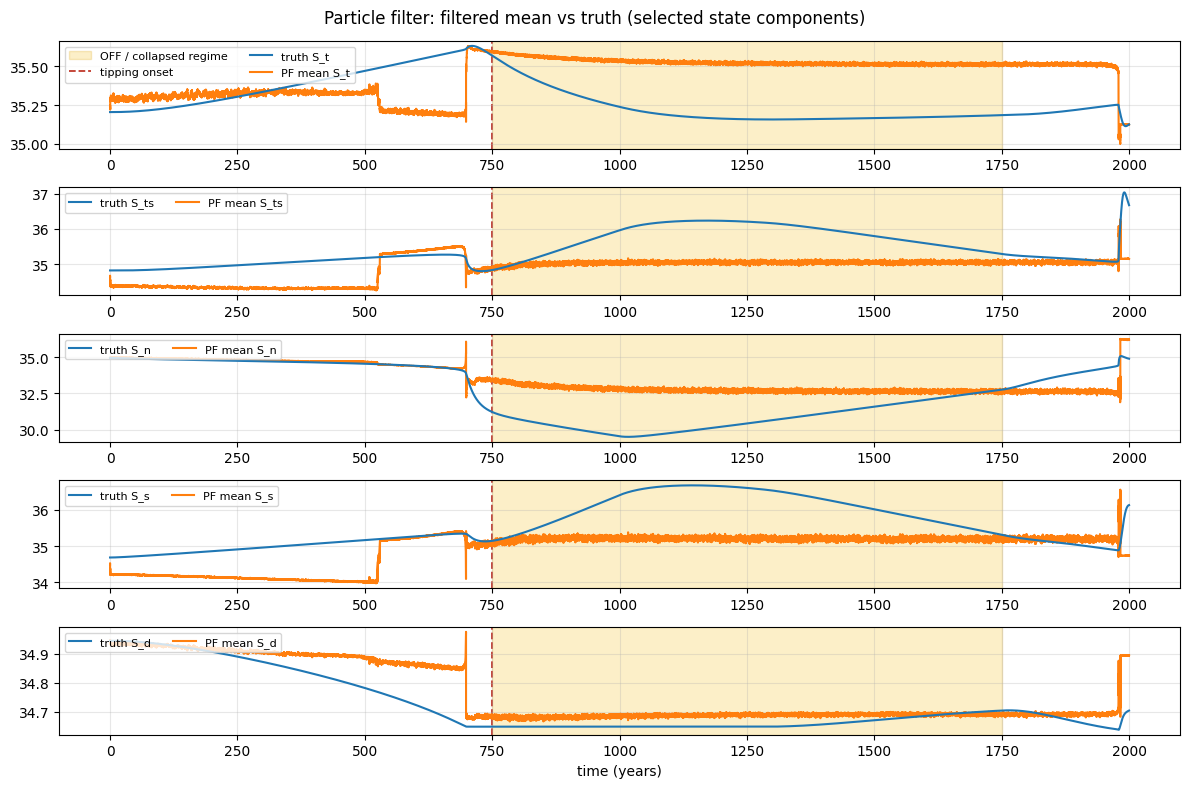

Saved: /content/drive/MyDrive/eccm_plots/pf_obs_timeseries_AMOC_ice_20260603_132957.png


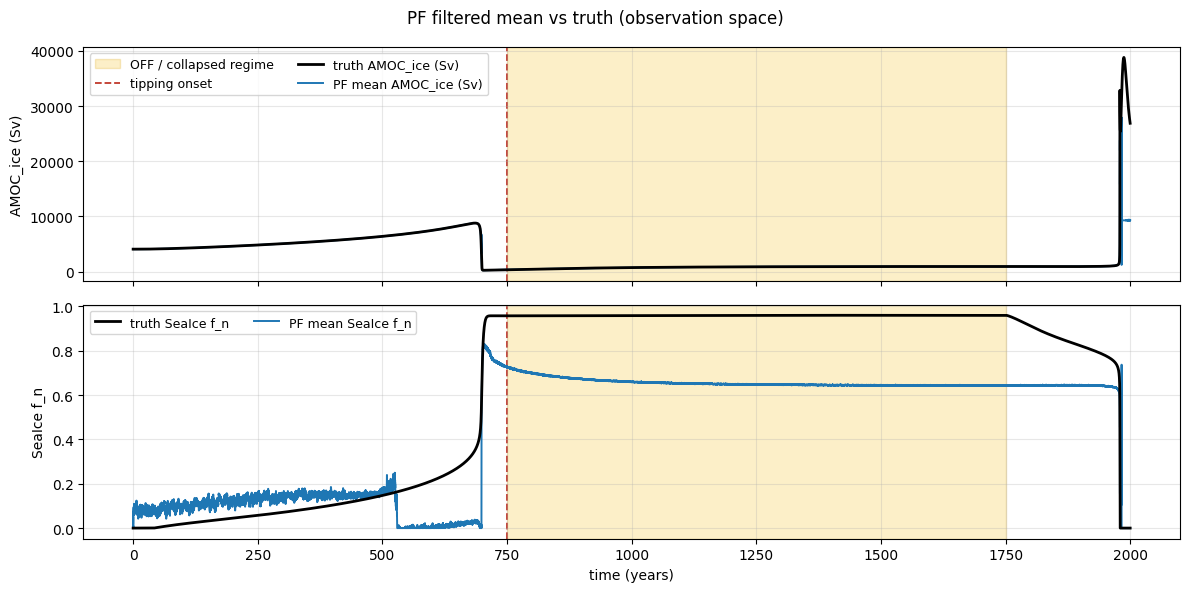

In [ ]:
"""
Plot key state variables

Plots the true and filtered trajectories of a few key state variables, with the collapsed ('off') period shaded for visual reference.
"""

# Xfilt is [11, Nt] -> transpose to [Nt, 11]
Xfilt_state = Xfilt.T
t = np.arange(Nt) * dt_years

year1, year2 = 750, 1750
def add_regime_band(ax, show_label=False):
    ax.axvspan(year1, year2,
               facecolor="#f2b705", alpha=0.22, edgecolor="#d99e00",
               linewidth=1.0, zorder=0,
               label="OFF / collapsed regime" if show_label else None)
    ax.axvline(year1, color="#c0392b", ls="--", lw=1.3, zorder=1,
               label="tipping onset" if show_label else None)

# --- 11D state diagnostics (a few key components)
key_idx   = [0, 1, 2, 3, 4]
key_names = [model.convention[i] for i in key_idx]

plt.figure(figsize=(12, 8))
for p, (ii, nm) in enumerate(zip(key_idx, key_names)):
    ax = plt.subplot(len(key_idx), 1, p + 1)
    add_regime_band(ax, show_label=(p == 0))
    ax.plot(t, Xtruth_state[:Nt, ii], label=f"truth {nm}",  zorder=3)
    ax.plot(t, Xfilt_state[:, ii],    label=f"PF mean {nm}", zorder=2)
    ax.grid(True, alpha=0.3); ax.legend(ncol=2, fontsize=8, loc="upper left")
plt.xlabel("time (years)")
plt.suptitle("Particle filter: filtered mean vs truth (selected state components)")
plt.tight_layout()
_p = os.path.join(PLOT_DIR, f"pf_state_timeseries_{_tag}.png")
plt.savefig(_p, dpi=150, bbox_inches="tight")
print(f"Saved: {_p}")
plt.show()

# --- observation-space diagnostics (AMOC_ice, SeaIce) — inline so the band shows
with torch.no_grad():
    Xt_true = torch.tensor(Xtruth_state[:Nt].T, dtype=torch.float32, device=device)  # [11,Nt]
    Xt_filt = torch.tensor(Xfilt_state.T,        dtype=torch.float32, device=device)  # [11,Nt]
    Ytrue = obs_amoc_ice_torch(Xt_true).T.cpu().numpy()  # [Nt,2]
    Yfilt = obs_amoc_ice_torch(Xt_filt).T.cpu().numpy()  # [Nt,2]

names_obs = ["AMOC_ice (Sv)", "SeaIce f_n"]
fig, axes = plt.subplots(len(names_obs), 1, figsize=(12, 6), sharex=True)
for k, ax in enumerate(axes):
    add_regime_band(ax, show_label=(k == 0))
    ax.plot(t, Ytrue[:, k], color="black", lw=2.0, label=f"truth {names_obs[k]}", zorder=3)
    ax.plot(t, Yfilt[:, k], lw=1.4,                 label=f"PF mean {names_obs[k]}", zorder=2)
    ax.set_ylabel(names_obs[k]); ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9, loc="upper left")
axes[-1].set_xlabel("time (years)")
fig.suptitle("PF filtered mean vs truth (observation space)")
plt.tight_layout()
_p = os.path.join(PLOT_DIR, f"pf_obs_timeseries_{_tag}.png")
plt.savefig(_p, dpi=150, bbox_inches="tight")
print(f"Saved: {_p}")
plt.show()

Saved: /content/drive/MyDrive/eccm_plots/reconstruction_AMOC_ice_20260603_132957.png


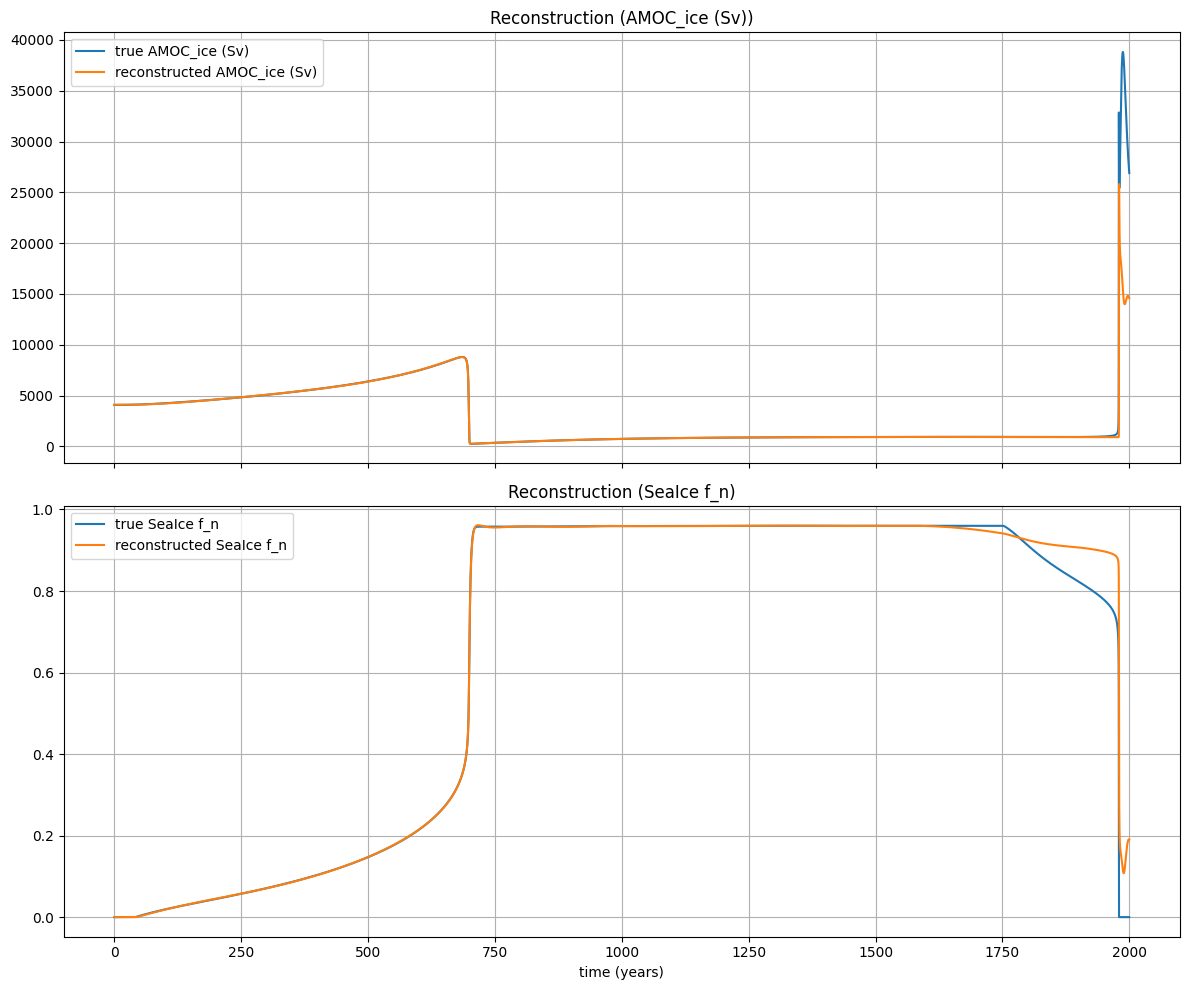

In [ ]:
"""
Plot observed quantities: truth, filter and reconstruction

Compares the true trajectory, the noisy observations, and the filtered/reconstructed estimates for the observed quantities (AMOC strength and sea-ice fraction).
"""

t = np.arange(Xn.shape[0]) * dt_years
names = ["AMOC_ice (Sv)", "SeaIce f_n"]

encNet = encNet.to(device).eval()
decNet = decNet.to(device).eval()

Xn_t = XN_t[:Xn.shape[0]].to(device = device, dtype = torch.float32)

sd_t = torch.tensor(sd, dtype = torch.float32, device = device)  # [1,11]
mu_t = torch.tensor(mu, dtype = torch.float32, device = device)  # [1,11]

# Xn_t should be the NORMALIZED 11D inputs, shape [K,11]
# (If Xn_t is currently physical, normalize it first.)

with torch.no_grad():
    XrecN_t = decNet(encNet(Xn_t))     # [K,11] normalized reconstruction
    Xrec_t  = XrecN_t * sd_t + mu_t    # [K,11] physical reconstruction

# ---- compute observations from true + recon states ----
with torch.no_grad():
    Xtrue_state_t = (Xn_t * sd_t + mu_t).T   # [11,K] physical truth state (from normalized inputs)
    Xrecon_state_t = Xrec_t.T                # [11,K] physical recon state

    Ytrue_t  = obs_amoc_ice_torch(Xtrue_state_t).T   # [K,2]
    Yrecon_t = obs_amoc_ice_torch(Xrecon_state_t).T  # [K,2]

Ytrue  = Ytrue_t.detach().cpu().numpy()   # [K,2]
Yrecon = Yrecon_t.detach().cpu().numpy()  # [K,2]

# ---- plot ----
fig, axes = plt.subplots(2, 1, figsize=(12,10), sharex=True)
for i, name in enumerate(names):
    axes[i].plot(t, Ytrue[:, i],  label=f"true {name}")
    axes[i].plot(t, Yrecon[:, i], label=f"reconstructed {name}")
    axes[i].set_title(f"Reconstruction ({name})")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("time (years)")
plt.tight_layout()
_p = os.path.join(PLOT_DIR, f"reconstruction_{_tag}.png")
plt.savefig(_p, dpi=150, bbox_inches="tight")
print(f"Saved: {_p}")

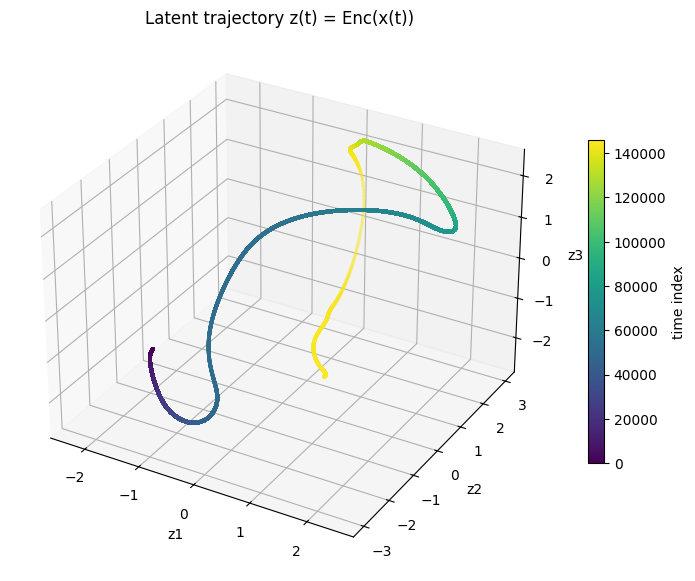

In [ ]:
"""
3D latent-space plot

Plots the encoded latent trajectory in 3D (requires a 3-dimensional latent space), colored by time, to visually inspect its shape.
"""

assert latentDim == 3, "Set latentDim=3 for a true 3D latent plot."

encNet = encNet.to(device).eval()

# Use the normalized full state sequence from your notebook
# XN_t is already a torch tensor with shape [Nt, 11]
with torch.no_grad():
    XnN_t = XN_t[:Xn.shape[0]].to(device=device, dtype=torch.float32)
    Z_t   = encNet(XnN_t)
    Z     = Z_t.detach().cpu().numpy()

t = np.arange(Z.shape[0])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=t, s=3)

ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_zlabel("z3")
ax.set_title("Latent trajectory z(t) = Enc(x(t))")

cb = plt.colorbar(sc, ax=ax, shrink=0.6)
cb.set_label("time index")

plt.show()

In [ ]:
"""
Shape sanity check before a rollout

Prints the shapes of several arrays as a quick sanity check before running a latent-space rollout.
"""

print("mu shape:", np.array(mu).shape)
print("sd shape:", np.array(sd).shape)

# XnN_t is on GPU
print("XnN_t shape:", tuple(XnN_t.shape))

Zroll_t = torch.zeros((K_eval, latentDim), dtype=torch.float32, device=device)

with torch.no_grad():
    XnnN_t = decNet(Zroll_t)

print("Zroll_t shape:", tuple(Zroll_t.shape))          # [K_eval, latentDim]
print("decNet(Zroll_t) shape:", tuple(XnnN_t.shape))   # [K_eval, physical_dimension]
print("mu_t shape:", tuple(mu_t.shape))
print("sd_t shape:", tuple(sd_t.shape))

mu shape: (1, 11)
sd shape: (1, 11)
XnN_t shape: (145999, 11)
Zroll_t shape: (20, 3)
decNet(Zroll_t) shape: (20, 11)
mu_t shape: (1, 11)
sd_t shape: (1, 11)
